# 데이터 확인 및 결측치, 이상치 제거

In [1638]:
import pandas as pd
import numpy as np
import graphviz
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import scipy.stats as stats
import warnings

from statsmodels.formula.api import ols
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.tree import export_graphviz
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.api import qqplot, add_constant
from sklearn.metrics import r2_score

warnings.filterwarnings('ignore')
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'  # 윈도우 환경에서는 'Malgun Gothic' 폰트를 사용
else:
    plt.rcParams['font.family'] = 'Noto Sans CJK JP'  # macOS나 Linux 등 다른 환경에서는 'AppleGothic' 폰트를 사용

matplotlib.rcParams['axes.unicode_minus'] = False

In [1639]:
#데이터 불러오기
df_1= pd.read_csv("/home/piai/다운로드/32기 A14/sts_1sm_cc_1.csv", encoding = 'euc-kr')
df_2= pd.read_csv("/home/piai/다운로드/32기 A14/sts_2fur_hr_2.csv", encoding = 'euc-kr')
df_3= pd.read_csv("/home/piai/다운로드/32기 A14/sts_3ap_3.csv", encoding = 'euc-kr')

In [1640]:
df_1.dropna(inplace=True)
df_2.dropna(inplace=True)
df_3.dropna(inplace=True)

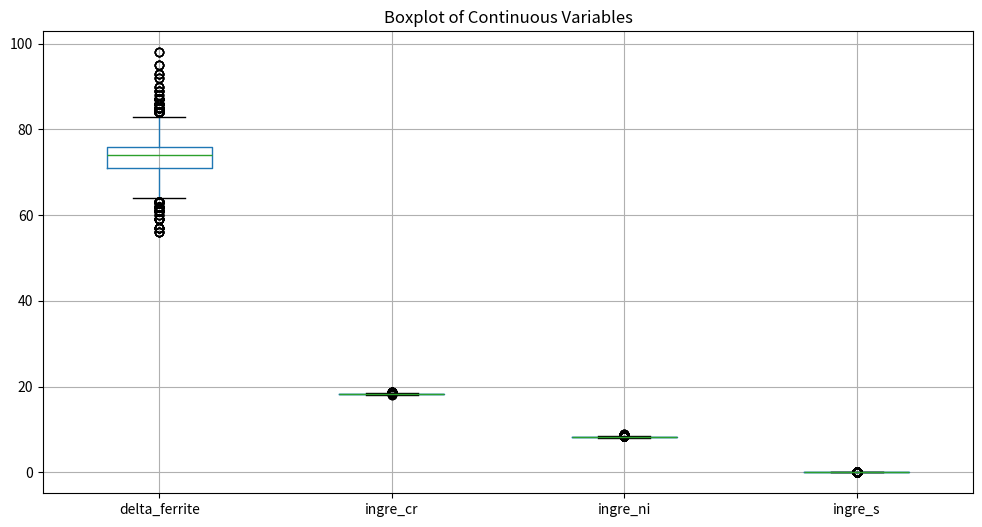

In [1641]:
import matplotlib.pyplot as plt
import seaborn as sns

# 연속형 변수만 선택
cols = ['delta_ferrite', 'ingre_cr', 'ingre_ni', 'ingre_s']

plt.figure(figsize=(12,6))
df_1[cols].boxplot()
plt.title('Boxplot of Continuous Variables')
plt.show()

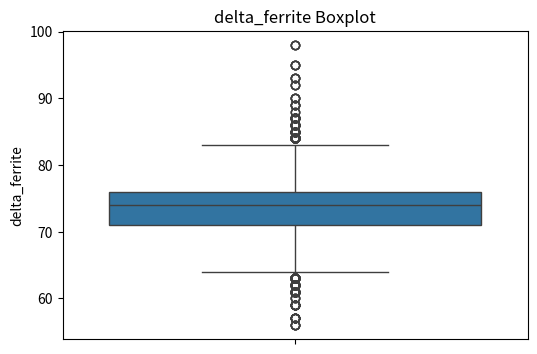

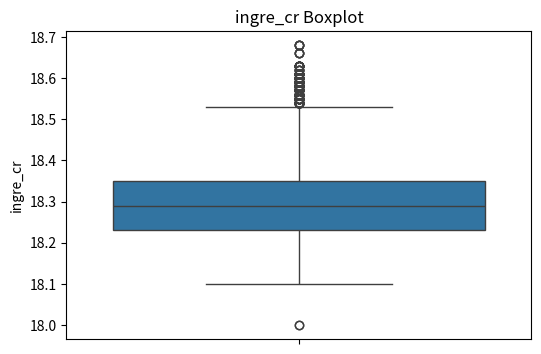

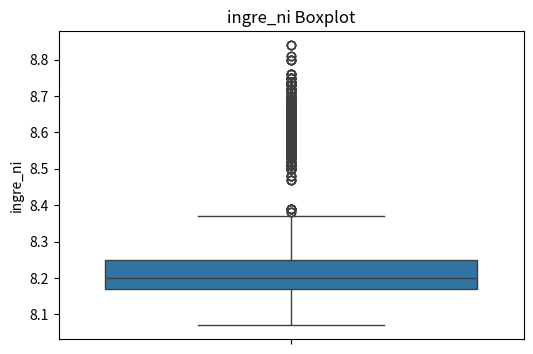

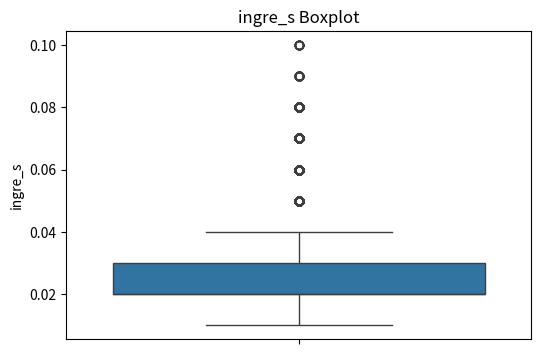

In [ ]:
cols = ['delta_ferrite', 'ingre_cr', 'ingre_ni', 'ingre_s']

for col in cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=df_1[col])
    plt.title(f'{col} Boxplot')
    plt.show()

In [ ]:
from scipy import stats
import numpy as np

cols = ['delta_ferrite','ingre_cr','ingre_ni','ingre_s']

z_scores = np.abs(stats.zscore(df_1[cols]))

# threshold = 3 (보통 기준)
outliers = (z_scores > 3)

df_1[outliers.any(axis=1)]

,sm_plant,charge_id,steel_grade,steel_usage,delta_ferrite,ingre_cr,ingre_ni,ingre_s,cast_date,cc_gubun,tundish_temp,mlac_ratio,slab_no,slab_gubun,slab_grind
5,1공장,CH80154,C13,RZ1,68,18.40,8.22,0.08,2025-07-13,4연주,1478.0,95.9,411,C,MISS
6,1공장,CH80154,C13,RZ1,68,18.40,8.22,0.08,2025-07-13,4연주,1478.0,95.9,511,C,MISS
41,1공장,CH80168,C13,RJ1,74,18.29,8.23,0.07,2025-07-14,1연주,1486.0,94.8,511,C,HSHS
67,1공장,CH80278,C12,Other,61,18.29,8.64,0.04,2025-05-18,2연주,1492.0,93.5,211,C,MISS
68,1공장,CH80278,C12,RJ1,61,18.29,8.64,0.04,2025-06-18,1연주,1492.0,93.5,311,C,MISS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23505,2공장,CH49113,C13,Other,75,18.23,8.22,0.07,2025-07-12,2연주,1481.0,96.1,611,C,HSHS
23506,2공장,CH49113,C13,RJ1,75,18.23,8.22,0.07,2025-07-12,2연주,1481.0,96.1,111,C,HSHS
23514,2공장,CH49142,C13,RJ1,84,18.53,8.28,0.07,2025-07-13,4연주,1475.0,95.0,411,C,HSHS
23515,2공장,CH49142,C13,RJ1,84,18.53,8.28,0.07,2025-07-13,4연주,1475.0,95.0,511,C,HSHS


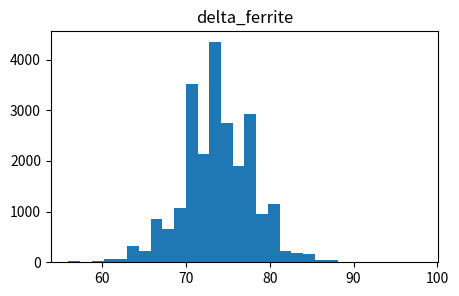

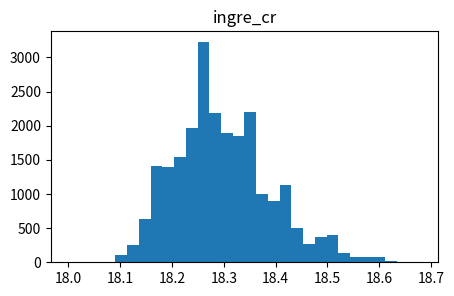

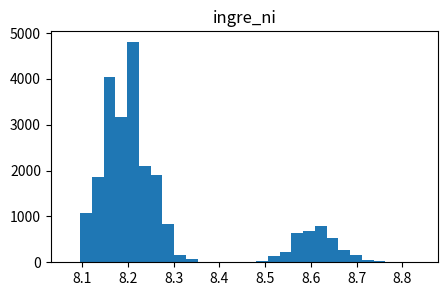

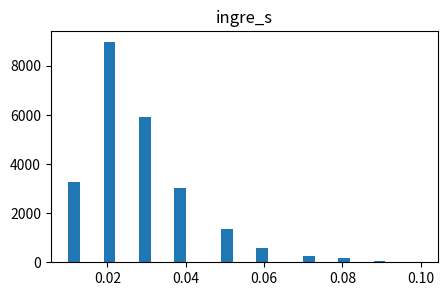

In [ ]:
import matplotlib.pyplot as plt

for col in cols:
    plt.figure(figsize=(5,3))
    plt.hist(df_1[col], bins=30)
    plt.title(col)
    plt.show()

<!-- ## 이상치 제거 -->

In [ ]:
print(df_1.columns)
print(df_2.columns)
print(df_3.columns)

print(len(df_2))


Index(['sm_plant', 'charge_id', 'steel_grade', 'steel_usage', 'delta_ferrite',
       'ingre_cr', 'ingre_ni', 'ingre_s', 'cast_date', 'cc_gubun',
       'tundish_temp', 'mlac_ratio', 'slab_no', 'slab_gubun', 'slab_grind'],
      dtype='object')
Index(['charge_id', 'slab_no', 'furnace_no', 'f_jangip_gubun', 'f_jangip_temp',
       'f_bfg', 'f_cog', 'f_ldg', 'f_bfg_per', 'f_cog_per', 'f_ldg_per',
       'f_pre_temp', 'f_heat_temp', 'f_sock_temp', 'f_pre_interval',
       'f_heat_interval', 'f_sock_interval', 'f_ext_date', 'f_ext_time',
       'hr_coil_id', 'hr_date', 'hr_thick', 'hr_width', 'rm4_temp', 'rm_pitch',
       'slab_width'],
      dtype='object')
Index(['judge', 'hr_coil_id', 'ap_plant', 'ap_prod_id', 'ap_date', 'ap_shift',
       'ap_thick', 'ap_width', 'ap_line_speed'],
      dtype='object')
23643


In [ ]:
df_2= df_2[df_2['f_sock_temp']<1400]
df_2= df_2[df_2['f_sock_temp']>200]

<Axes: ylabel='f_sock_temp'>

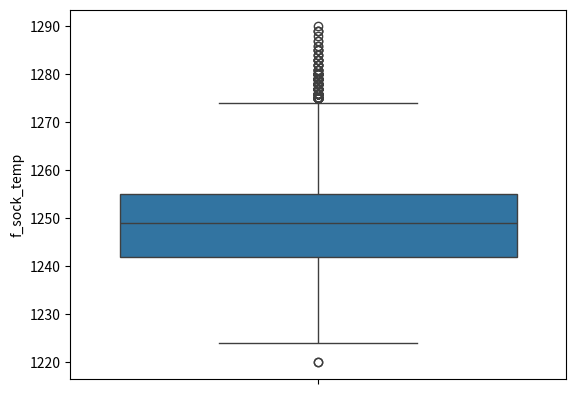

In [ ]:
sns.boxplot(y=df_2['f_sock_temp'])

<Axes: ylabel='f_sock_interval'>

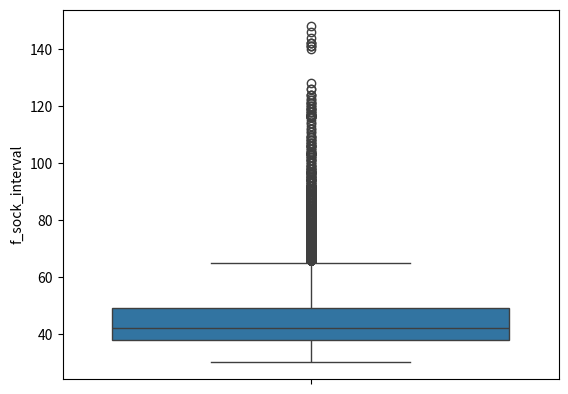

In [ ]:
df_2= df_2[df_2['f_sock_interval']!=168]
sns.boxplot(y=df_2['f_sock_interval'])

In [ ]:
df_2['hr_thick_group'] = np.select(
[
df_2['hr_thick'] <= 3.46,
(df_2['hr_thick'] >= 3.46) & (df_2['hr_thick'] <= 4.48),
df_2['hr_thick'] >= 4.48
],
[
'얇음',
'중간',
'두꺼움'
],
default = '기타'
)

In [ ]:
print(len(df_2[df_2['hr_thick'] <= 3.05]))
print(len(df_2[(df_2['hr_thick'] >= 3.16) & (df_2['hr_thick'] <= 3.55)]))
print(len(df_2[(df_2['hr_thick'] >= 3.95) & (df_2['hr_thick'] <= 4.08)]))
print(len(df_2[df_2['hr_thick'] >= 4.94]))

12997
5442
2769
2428


In [ ]:
len(df_2)

23640

In [ ]:
# cast_date: 2월 데이터 제거
display(df_1.head())
print(df_1.info())


,sm_plant,charge_id,steel_grade,steel_usage,delta_ferrite,ingre_cr,ingre_ni,ingre_s,cast_date,cc_gubun,tundish_temp,mlac_ratio,slab_no,slab_gubun,slab_grind
0,1공장,CH80081,C12,RZ1,69,18.24,8.63,0.02,2025-05-09,2연주,1485.0,95.1,611,C,MISS
1,1공장,CH80092,C13,RZ1,70,18.45,8.34,0.03,2025-07-10,2연주,1496.0,100.0,511,M,MISS
2,1공장,CH80126,C13,RJ1,65,18.12,8.17,0.04,2025-07-12,1연주,1483.0,96.7,411,C,MISS
3,1공장,CH80126,C13,RZ1,65,18.12,8.17,0.04,2025-07-12,2연주,1483.0,96.7,311,C,MISS
4,1공장,CH80141,C13,RJ1,70,18.23,8.27,0.03,2025-07-12,2연주,1478.0,91.9,611,C,MISS


<class 'pandas.core.frame.DataFrame'>
Index: 23638 entries, 0 to 23648
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sm_plant       23638 non-null  object 
 1   charge_id      23638 non-null  object 
 2   steel_grade    23638 non-null  object 
 3   steel_usage    23638 non-null  object 
 4   delta_ferrite  23638 non-null  int64  
 5   ingre_cr       23638 non-null  float64
 6   ingre_ni       23638 non-null  float64
 7   ingre_s        23638 non-null  float64
 8   cast_date      23638 non-null  object 
 9   cc_gubun       23638 non-null  object 
 10  tundish_temp   23638 non-null  float64
 11  mlac_ratio     23638 non-null  float64
 12  slab_no        23638 non-null  int64  
 13  slab_gubun     23638 non-null  object 
 14  slab_grind     23638 non-null  object 
dtypes: float64(5), int64(2), object(8)
memory usage: 2.9+ MB
None


In [ ]:
df_1['cast_date']= pd.to_datetime(df_1['cast_date'], format= '%Y-%m-%d')
df_1= df_1[df_1['cast_date'].dt.month != 2]

In [ ]:
cond = (
((df_2['f_bfg'] > 0) & (df_2['f_bfg_per'] == 0)) |
((df_2['f_cog'] > 0) & (df_2['f_cog_per'] == 0))
)

df_2 = df_2[~cond].copy()

<!-- ## 데이터 병합 -->

# 데이터 병합

In [ ]:
#df_1 에서 charge_id 랑 slab_no 를 묶어 중복값 확인
duplicates_df_sts1 = df_1[df_1.duplicated(subset=['charge_id', 'slab_no'], keep=False)]
# 결과 확인
print("--- df1의 중복 키 행 ---")
print(duplicates_df_sts1.sort_values(by=['charge_id', 'slab_no']))

--- df1의 중복 키 행 ---
Empty DataFrame
Columns: [sm_plant, charge_id, steel_grade, steel_usage, delta_ferrite, ingre_cr, ingre_ni, ingre_s, cast_date, cc_gubun, tundish_temp, mlac_ratio, slab_no, slab_gubun, slab_grind]
Index: []


In [ ]:
duplicates_df_sts2 = df_2[df_2.duplicated(subset=['charge_id', 'slab_no'], keep=False)]
# 결과 확인
print("--- df2의 중복 키 행 ---")
print(duplicates_df_sts2.sort_values(by=['charge_id', 'slab_no']))

--- df2의 중복 키 행 ---
  charge_id  slab_no furnace_no f_jangip_gubun  f_jangip_temp  f_bfg   f_cog  \
3   CH42171      511        1호기            CCR             30  24.37  35.202   
4   CH42171      511        4호기            CCR             30  24.37  35.202   

   f_ldg  f_bfg_per  f_cog_per  f_ldg_per  f_pre_temp  f_heat_temp  \
3    0.0   40.90848   59.09152        0.0      1130.0         1250   
4    0.0   40.90848   59.09152        0.0      1130.0         1250   

   f_sock_temp  f_pre_interval  f_heat_interval  f_sock_interval  f_ext_date  \
3       1247.0              75               69             64.0  2025-08-07   
4       1247.0              75               69             64.0  2025-08-07   

   f_ext_time hr_coil_id     hr_date  hr_thick  hr_width  rm4_temp  rm_pitch  \
3          17    U700364  2025-08-07      3.04      1248      1116        91   
4          17    U700364  2025-08-07      3.04      1248      1116        91   

   slab_width hr_thick_group  
3        1240  

In [ ]:
index_to_remove = [3,4] # 3,4 번은 furnace_no 이외의 모든값이 동일 하므로 판단불가 및 2개 제품 모두 양품
df2_cleaned = df_2.drop(index_to_remove)
df_2 = df2_cleaned.reset_index(drop=True)

In [ ]:
print("--- df2의 중복 키 행 ---")

print(df_2.sort_values(by=['charge_id', 'slab_no']))

--- df2의 중복 키 행 ---
      charge_id  slab_no furnace_no f_jangip_gubun  f_jangip_temp   f_bfg  \
0       CH42126      511        4호기            CCR             30  23.750   
1       CH42126      611        1호기            CCR             30  23.750   
2       CH42157      511        3호기            CCR             30  24.370   
3       CH42193      411        3호기            CCR             30  26.308   
4       CH42207      611        4호기            CCR             30  23.666   
...         ...      ...        ...            ...            ...     ...   
23631   CH87509      511        3호기            HCR            420  18.985   
23632   CH87510      111        2호기            HCR            412  18.985   
23633   CH87510      211        1호기            HCR            398  18.985   
23634   CH87510      311        1호기            CCR            140  22.517   
23635   CH87516      511        1호기            HCR            499  23.257   

        f_cog  f_ldg  f_bfg_per  f_cog_per  f_ldg_per  

In [ ]:
merged_df = pd.merge(df_1, df_2, on=['charge_id', 'slab_no'], how='inner')

# 3. 2단계 병합: 열연(HR)과 소둔산세(AP) 연결
# hr_coil_id를 기준으로 최종 결과 매칭
final_df = pd.merge(merged_df, df_3, on='hr_coil_id', how='inner')

# 4. 결과 확인
print(f"최종 병합 데이터 형태: {final_df.shape}")
final_df.head()

최종 병합 데이터 형태: (23632, 48)


,sm_plant,charge_id,steel_grade,steel_usage,delta_ferrite,ingre_cr,ingre_ni,ingre_s,cast_date,cc_gubun,tundish_temp,mlac_ratio,slab_no,slab_gubun,slab_grind,furnace_no,f_jangip_gubun,f_jangip_temp,f_bfg,f_cog,f_ldg,f_bfg_per,f_cog_per,f_ldg_per,f_pre_temp,f_heat_temp,f_sock_temp,f_pre_interval,f_heat_interval,f_sock_interval,f_ext_date,f_ext_time,hr_coil_id,hr_date,hr_thick,hr_width,rm4_temp,rm_pitch,slab_width,hr_thick_group,judge,ap_plant,ap_prod_id,ap_date,ap_shift,ap_thick,ap_width,ap_line_speed
0,1공장,CH80081,C12,RZ1,69,18.24,8.63,0.02,2025-05-09,2연주,1485.0,95.1,611,C,MISS,1호기,CCR,30,19.195,23.767,0.0,44.679019,55.320981,0.0,1127.0,1265,1269.0,133,66,43.0,2025-07-02,17,V694664,2025-07-02,3.04,1028,1108,113,1020,얇음,양품,2공장,X91819,2025-08-10,A,2.93,1003.0,47.00
1,1공장,CH80092,C13,RZ1,70,18.45,8.34,0.03,2025-07-10,2연주,1496.0,100.0,511,M,MISS,1호기,CCR,30,32.952,44.175,0.0,42.724338,57.275662,0.0,1130.0,1248,1248.0,74,39,70.0,2025-08-27,21,V676684,2025-08-27,3.04,1245,1128,91,1240,얇음,불량,1공장,A16946,2025-08-30,B,2.89,1257.0,43.30
2,1공장,CH80126,C13,RJ1,65,18.12,8.17,0.04,2025-07-12,1연주,1483.0,96.7,411,C,MISS,4호기,CCR,30,27.923,40.501,0.0,40.808781,59.191219,0.0,1130.0,1255,1262.0,80,51,52.0,2025-08-08,17,U705704,2025-08-08,3.55,1028,1114,87,1030,중간,불량,2공장,Y77190,2025-08-11,B,3.41,1035.0,42.57
3,1공장,CH80126,C13,RZ1,65,18.12,8.17,0.04,2025-07-12,2연주,1483.0,96.7,311,C,MISS,1호기,CCR,30,27.923,40.501,0.0,40.808781,59.191219,0.0,1130.0,1249,1253.0,71,50,58.0,2025-08-08,17,U705694,2025-08-08,5.07,1028,1122,85,1030,두꺼움,양품,2공장,Y77493,2025-08-17,A,4.97,1036.0,29.70
4,1공장,CH80141,C13,RJ1,70,18.23,8.27,0.03,2025-07-12,2연주,1478.0,91.9,611,C,MISS,4호기,CCR,30,17.722,26.796,0.0,39.808617,60.191383,0.0,1129.0,1257,1260.0,87,52,38.0,2025-08-04,20,U697504,2025-08-04,5.07,1028,1114,92,1020,두꺼움,양품,1공장,A15211,2025-08-07,D,4.88,1037.0,31.00


In [ ]:
#데이터값 오류에 대한 정정 코드 (교수님 문의 완료)
final_df["delta_ferrite"] = final_df["delta_ferrite"].astype(float)*0.1
final_df["delta_ferrite"].head()

0    6.9
1    7.0
2    6.5
3    6.5
4    7.0
Name: delta_ferrite, dtype: float64

In [ ]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23632 entries, 0 to 23631
Data columns (total 48 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   sm_plant         23632 non-null  object        
 1   charge_id        23632 non-null  object        
 2   steel_grade      23632 non-null  object        
 3   steel_usage      23632 non-null  object        
 4   delta_ferrite    23632 non-null  float64       
 5   ingre_cr         23632 non-null  float64       
 6   ingre_ni         23632 non-null  float64       
 7   ingre_s          23632 non-null  float64       
 8   cast_date        23632 non-null  datetime64[ns]
 9   cc_gubun         23632 non-null  object        
 10  tundish_temp     23632 non-null  float64       
 11  mlac_ratio       23632 non-null  float64       
 12  slab_no          23632 non-null  int64         
 13  slab_gubun       23632 non-null  object        
 14  slab_grind       23632 non-null  objec

In [ ]:
# final_df.to_csv(r"C:\Users\조수원\OneDrive\바탕 화면\32기 A14\final.csv", encoding='euc-kr')

In [ ]:
df_2.columns

Index(['charge_id', 'slab_no', 'furnace_no', 'f_jangip_gubun', 'f_jangip_temp',
       'f_bfg', 'f_cog', 'f_ldg', 'f_bfg_per', 'f_cog_per', 'f_ldg_per',
       'f_pre_temp', 'f_heat_temp', 'f_sock_temp', 'f_pre_interval',
       'f_heat_interval', 'f_sock_interval', 'f_ext_date', 'f_ext_time',
       'hr_coil_id', 'hr_date', 'hr_thick', 'hr_width', 'rm4_temp', 'rm_pitch',
       'slab_width', 'hr_thick_group'],
      dtype='object')

<!-- # 파생변수 생성 -->

In [ ]:
# 사용할 컬럼 숫자형 변환
cols = [
    'f_pre_temp', 'f_heat_temp', 'f_sock_temp',
    'f_pre_interval', 'f_heat_interval', 'f_sock_interval',
    'hr_width', 'hr_thick'
]

final_df[cols] = final_df[cols].apply(pd.to_numeric, errors='coerce')

# 1. 총 발열량(kJ/N)
final_df['f_heat_total'] = (4.184*(final_df["f_bfg"]*750 +final_df['f_cog']*4200 + final_df["f_ldg"]*2000)).astype('float')

# 2. 가열속도
final_df['f_heat_speed'] = np.where(
    final_df['f_heat_interval'] != 0,
    (final_df['f_heat_temp'] - final_df['f_pre_temp']) / final_df['f_heat_interval'],
    np.nan
)

# 3. 총 재로시간
final_df['f_total_time'] = (
    final_df['f_pre_interval'] +
    final_df['f_heat_interval'] +
    final_df['f_sock_interval']
)

# 4. 열지표
final_df['f_heat_constant'] = (
    final_df['f_pre_temp'] * final_df['f_pre_interval'] +
    final_df['f_heat_temp'] * final_df['f_heat_interval'] +
    final_df['f_sock_temp'] * final_df['f_sock_interval']
)


#5. 열간 압연 날짜 - 연주 날짜 
final_df['hr_date'] = pd.to_datetime(final_df['hr_date'], errors='coerce')
final_df['cast_date'] = pd.to_datetime(final_df['cast_date'], errors='coerce')

final_df['process_delay_time1'] = (
    final_df['hr_date'] - final_df['cast_date']
).dt.days


#6. 소둔상세 날짜 - 열간 압연 날짜 
final_df['ap_date'] = pd.to_datetime(final_df['ap_date'], errors='coerce')
final_df['hr_date'] = pd.to_datetime(final_df['hr_date'], errors='coerce')

final_df['process_delay_time2'] = (
    final_df['ap_date'] - final_df['hr_date']
).dt.days




# 확인
final_df[
    [
        'f_heat_total',
        'f_heat_speed',
        'f_total_time',
        'f_heat_constant',
        'process_delay_time1',
        'process_delay_time2'
        
    ]
].head()

,f_heat_total,f_heat_speed,f_total_time,f_heat_constant,process_delay_time1,process_delay_time2
0,477886.6476,2.090909,242.0,287948.0,54,39
1,879681.8160,3.025641,183.0,219652.0,48,3
2,799338.3468,2.450980,183.0,220029.0,27,3
3,799338.3468,2.380000,179.0,215354.0,27,9
4,526492.3848,2.461538,177.0,211467.0,23,3


In [ ]:
final_df.columns

Index(['sm_plant', 'charge_id', 'steel_grade', 'steel_usage', 'delta_ferrite',
       'ingre_cr', 'ingre_ni', 'ingre_s', 'cast_date', 'cc_gubun',
       'tundish_temp', 'mlac_ratio', 'slab_no', 'slab_gubun', 'slab_grind',
       'furnace_no', 'f_jangip_gubun', 'f_jangip_temp', 'f_bfg', 'f_cog',
       'f_ldg', 'f_bfg_per', 'f_cog_per', 'f_ldg_per', 'f_pre_temp',
       'f_heat_temp', 'f_sock_temp', 'f_pre_interval', 'f_heat_interval',
       'f_sock_interval', 'f_ext_date', 'f_ext_time', 'hr_coil_id', 'hr_date',
       'hr_thick', 'hr_width', 'rm4_temp', 'rm_pitch', 'slab_width',
       'hr_thick_group', 'judge', 'ap_plant', 'ap_prod_id', 'ap_date',
       'ap_shift', 'ap_thick', 'ap_width', 'ap_line_speed', 'f_heat_total',
       'f_heat_speed', 'f_total_time', 'f_heat_constant',
       'process_delay_time1', 'process_delay_time2'],
      dtype='object')

<Axes: xlabel='f_heat_total', ylabel='judge'>

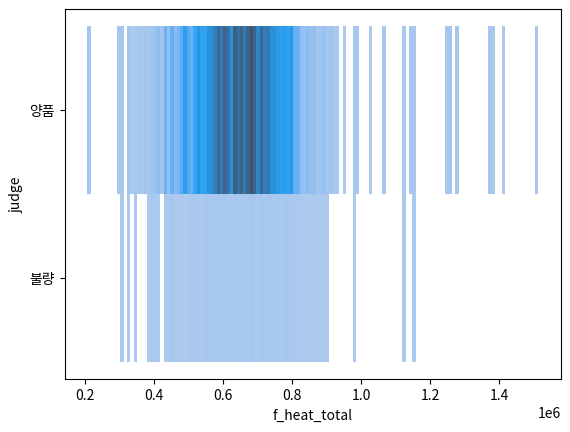

In [ ]:
sns.histplot(data=final_df, x = 'f_heat_total', y= 'judge')

<!-- # EDA -->

<Axes: ylabel='hr_thick'>

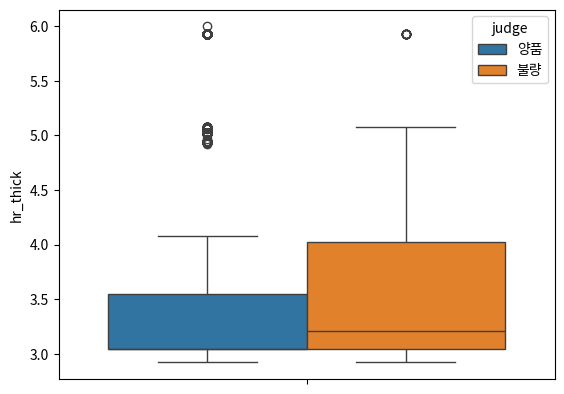

In [ ]:
sns.boxplot(data=final_df, hue ='judge', y= 'hr_thick')

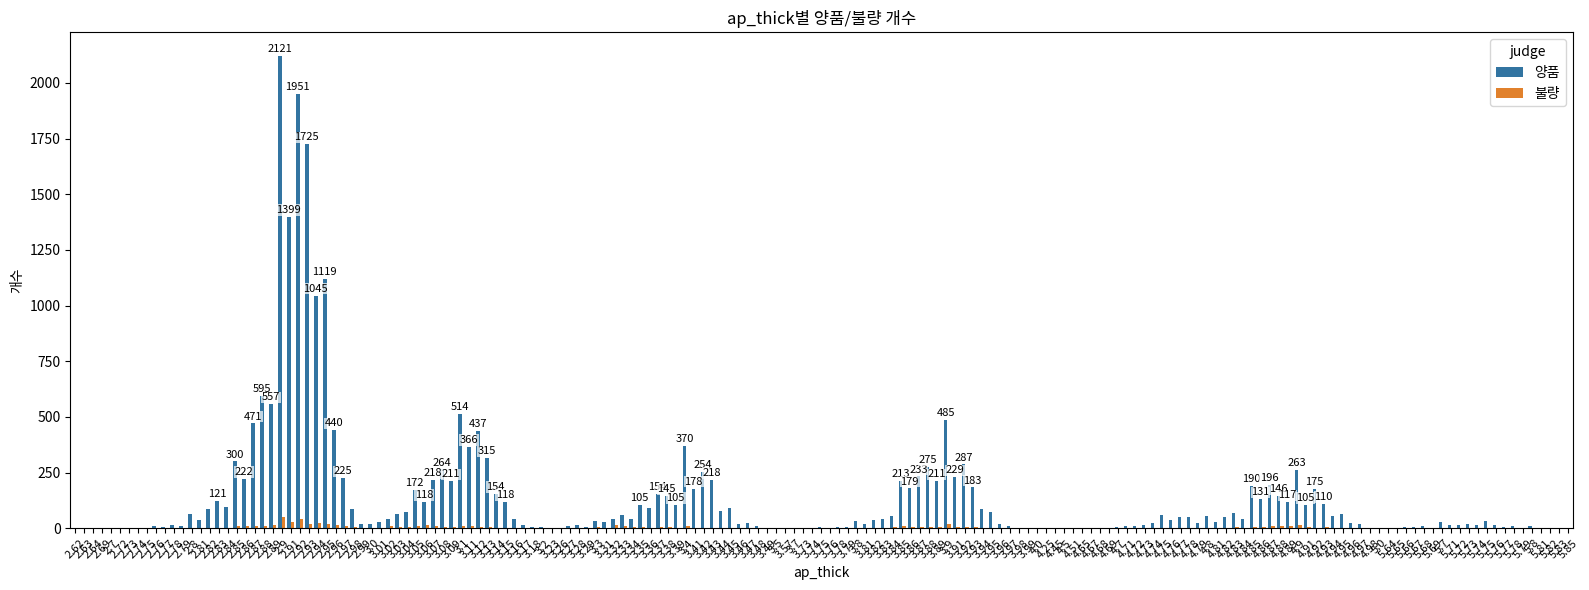

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 6))
ax = sns.countplot(data=final_df, x='ap_thick', hue='judge')

# 숫자 라벨 보기 좋게
for container_idx, container in enumerate(ax.containers):
    for bar in container:
        h = bar.get_height()
        
        # 너무 작은 막대는 숫자 생략
        if h < 100:
            continue
        
        x = bar.get_x() + bar.get_width() / 2
        
        # 양품/불량 라벨 높이를 조금 다르게
        offset = 8 if container_idx == 0 else 25
        
        ax.text(
            x, h + offset, f'{int(h)}',
            ha='center', va='bottom',
            fontsize=8, color='black',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=0.5)
        )

plt.title('ap_thick별 양품/불량 개수')
plt.xlabel('ap_thick')
plt.ylabel('개수')
plt.xticks(rotation=45, fontsize=8)
plt.tight_layout()
plt.show()

## 파생변수

In [ ]:
# 파생변수
cols = [
    'f_pre_temp', 'f_heat_temp', 'f_sock_temp',
    'f_pre_interval', 'f_heat_interval', 'f_sock_interval',
    'hr_width'
]

final_df[cols] = final_df[cols].apply(pd.to_numeric, errors='coerce')



# 1. 총 재로시간
final_df['f_total_time'] = (
    final_df['f_pre_interval'] +
    final_df['f_heat_interval'] +
    final_df['f_sock_interval']
)


#2. 열간 압연 날짜 - 연주 날짜 
final_df['hr_date'] = pd.to_datetime(final_df['hr_date'], errors='coerce')
final_df['cast_date'] = pd.to_datetime(final_df['cast_date'], errors='coerce')

final_df['process_delay_time1'] = (
    final_df['hr_date'] - final_df['cast_date']
).dt.days


#3. 가열온도 - 예열온도
final_df['heat_pre_diff'] = final_df['f_heat_temp'] - final_df['f_pre_temp']

#4. 균열온도 - 압연온도
final_df['sock_rm4_diff'] = final_df['f_sock_temp'] - final_df['rm4_temp']




# 확인
final_df[
    [
        'f_total_time',
        'process_delay_time1',
        'heat_pre_diff',
        'sock_rm4_diff'
        
    ]

].head()

,f_total_time,process_delay_time1,heat_pre_diff,sock_rm4_diff
0,242.0,54,138.0,161.0
1,183.0,48,118.0,120.0
2,183.0,27,125.0,148.0
3,179.0,27,119.0,131.0
4,177.0,23,128.0,146.0


<Axes: ylabel='ap_line_speed'>

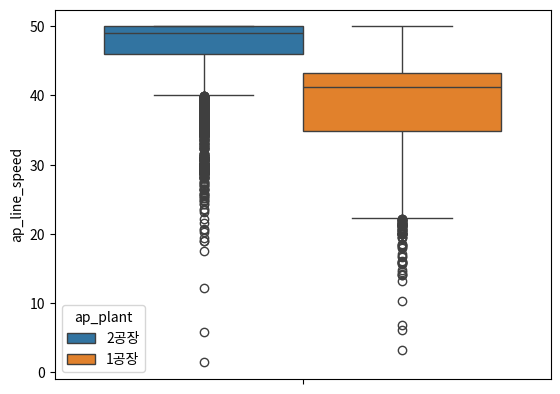

In [ ]:
sns.boxplot(data=final_df, hue = 'ap_plant', y = 'ap_line_speed')

In [ ]:
# sns.countplot(data=final_df, hue='furnace_no', x='judge')

In [ ]:
# cat_cols = ['furnace_no', 'f_jangip_gubun','hr_thick_group']

# plt.figure(figsize=(12, 5))

# for i, col in enumerate(cat_cols, 1):
#     plt.subplot(1, 3, i)
#     sns.countplot(data=final_df, x=col, hue='judge')
#     plt.title(f'{col} by judge')
#     plt.xticks(rotation=45)

# plt.tight_layout()
# plt.show()

In [ ]:
# sns.countplot(data=final_df, x = 'f_jangip_gubun')

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd

# cat_cols = ['furnace_no', 'f_jangip_gubun', 'hr_thick_group']

# # 불량 데이터만 추출
# bad_df = final_df[final_df['judge'] == '불량'].copy()

# for col in cat_cols:
#     count_df = (
#         bad_df[col]
#         .value_counts(dropna=False)
#         .reset_index()
#     )
#     count_df.columns = [col, 'bad_count']

#     # furnace_no만 호기 순서대로 정렬
#     if col == 'furnace_no':
#         furnace_order = ['1호기', '2호기', '3호기', '4호기']
#         count_df[col] = pd.Categorical(count_df[col], categories=furnace_order, ordered=True)
#         count_df = count_df.sort_values(col)

#     plt.figure(figsize=(8, 5))
#     ax = sns.barplot(data=count_df, x=col, y='bad_count',hue = col)

#     for i, v in enumerate(count_df['bad_count']):
#         ax.text(i, v, str(v), ha='center', va='bottom', fontsize=10)

#     plt.title(f'{col}별 불량 개수')
#     plt.ylabel('Bad Count')
#     plt.xlabel(col)
#     plt.xticks(rotation=45)
#     plt.tight_layout()
#     plt.show()

#     print(f'\n[{col}]')
#     print(count_df)
#     print('총 불량 개수:', count_df['bad_count'].sum())

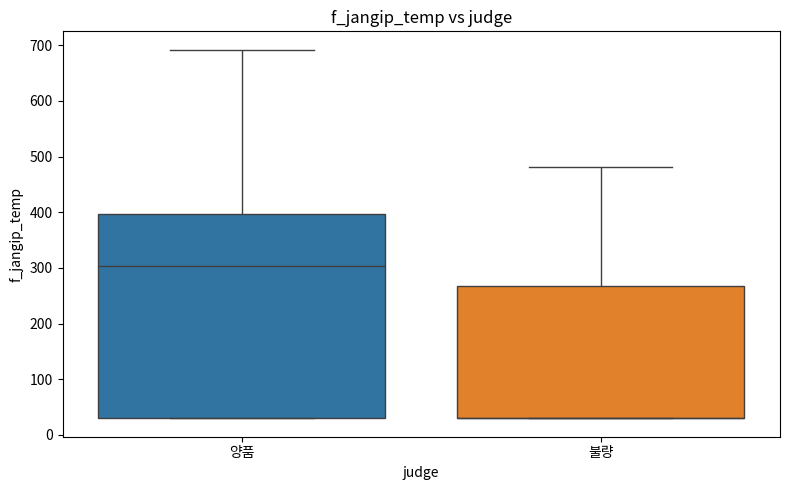

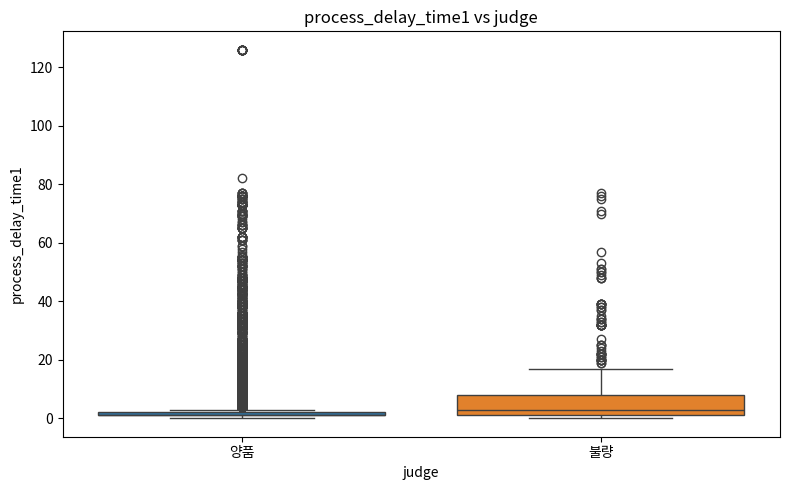

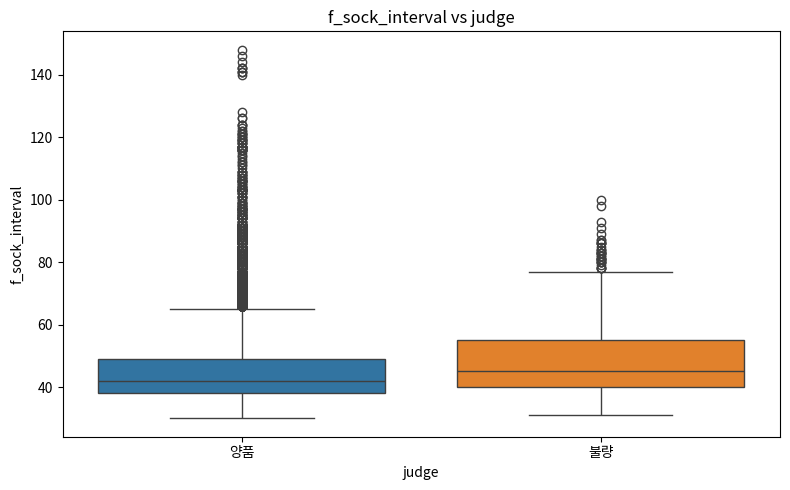

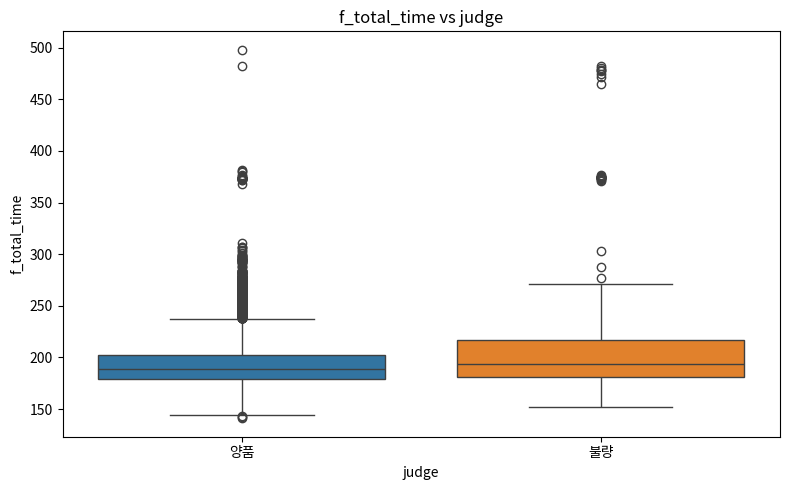

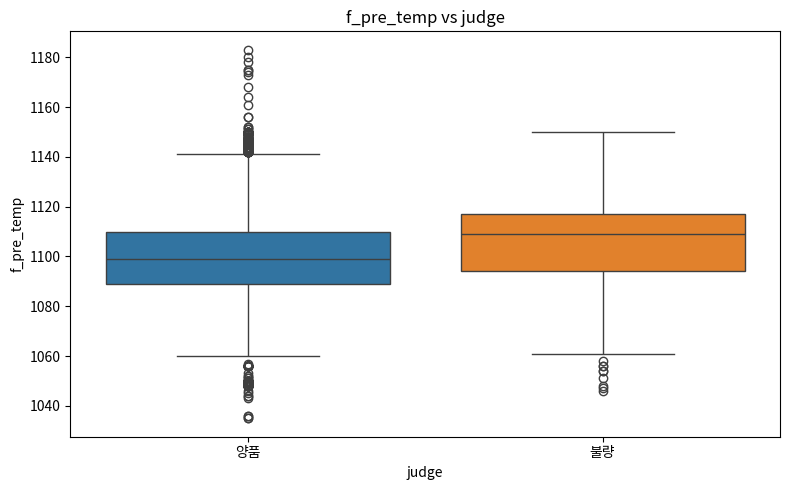

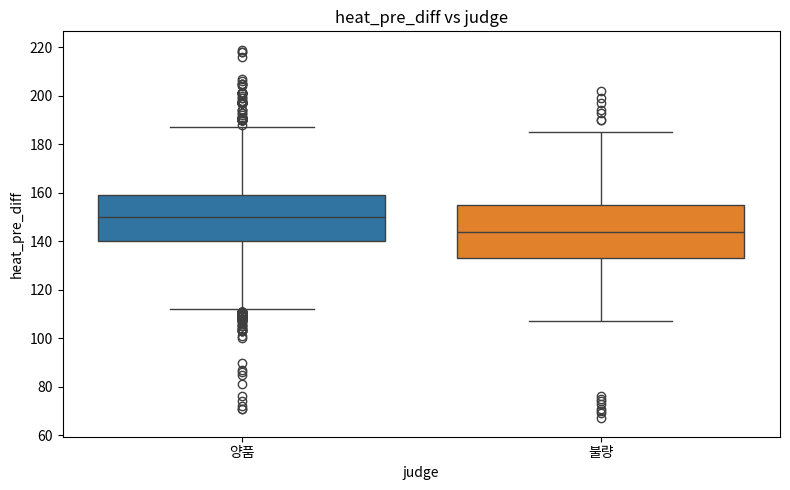

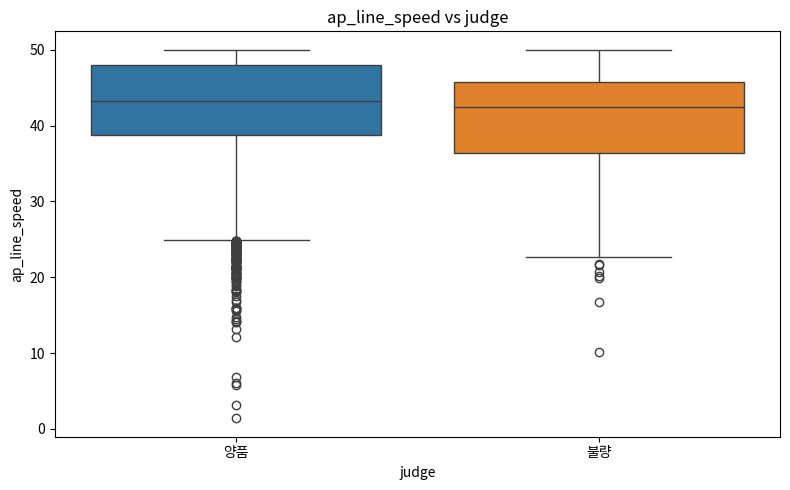

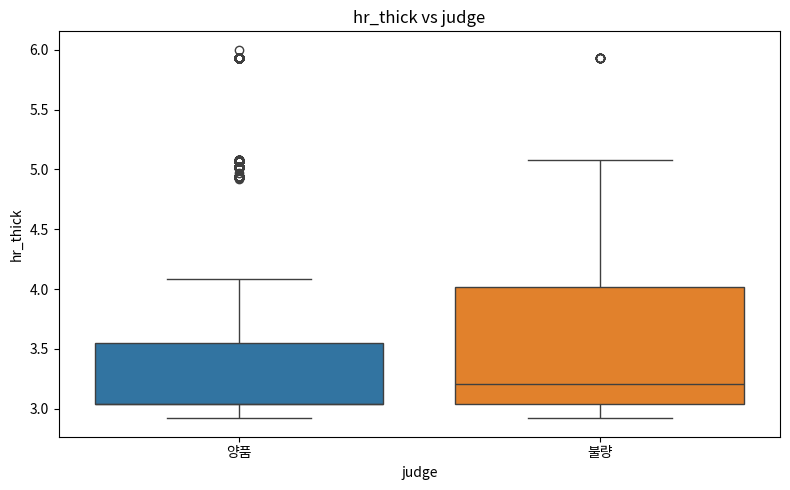

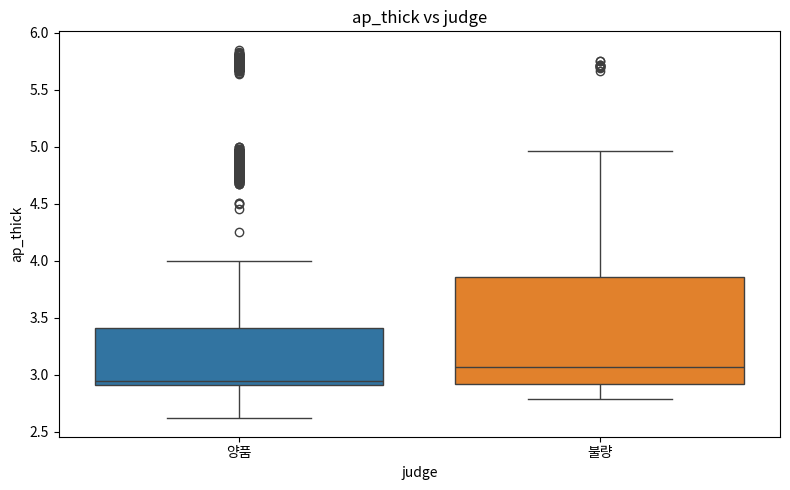

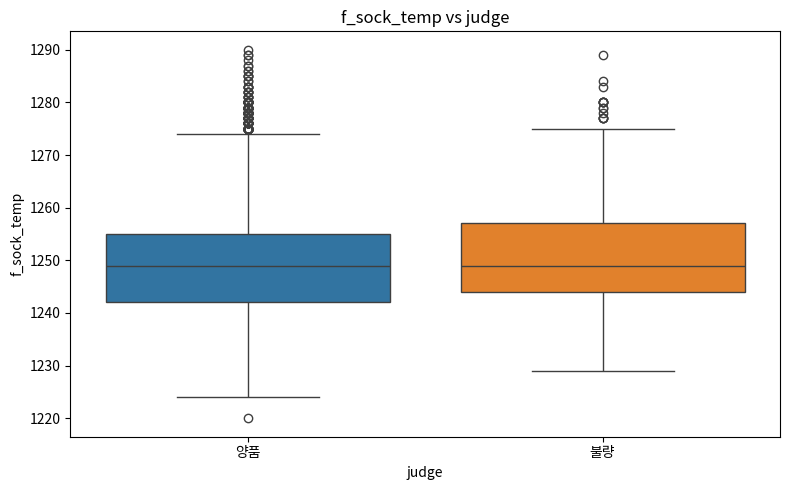

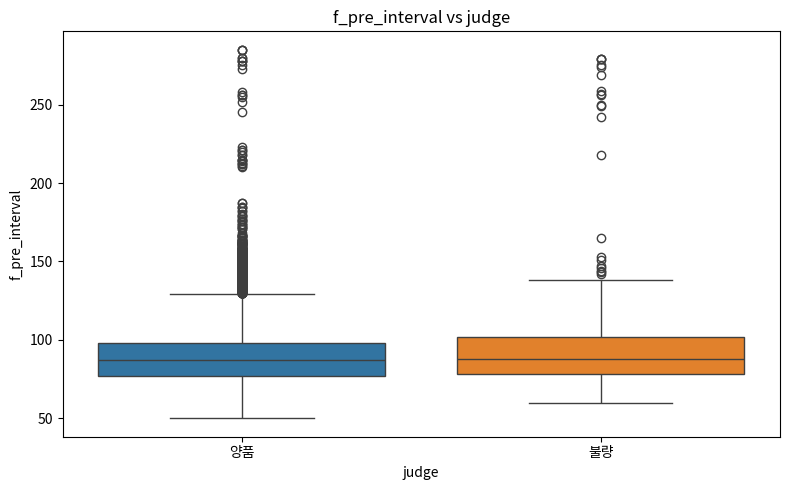

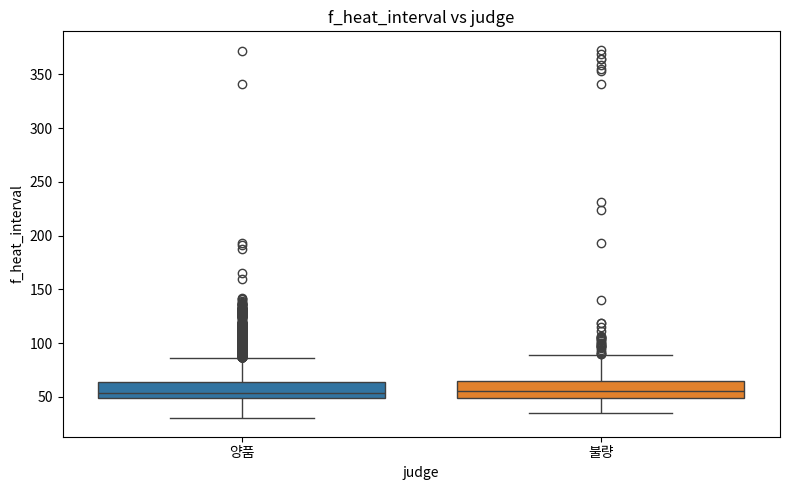

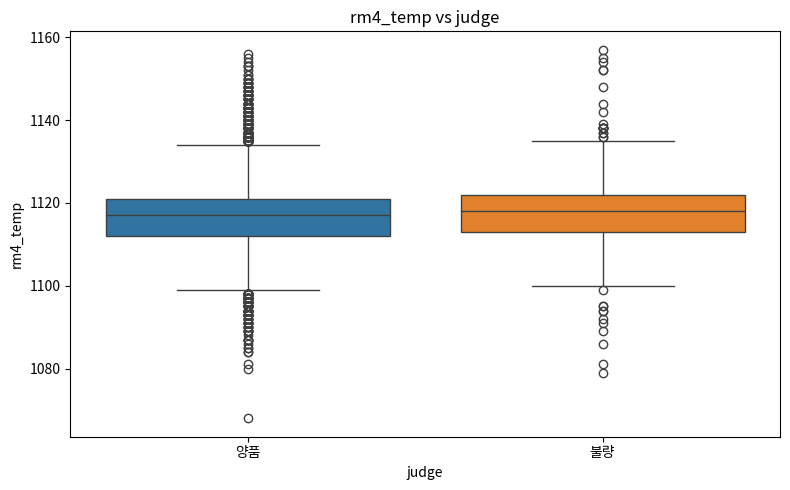

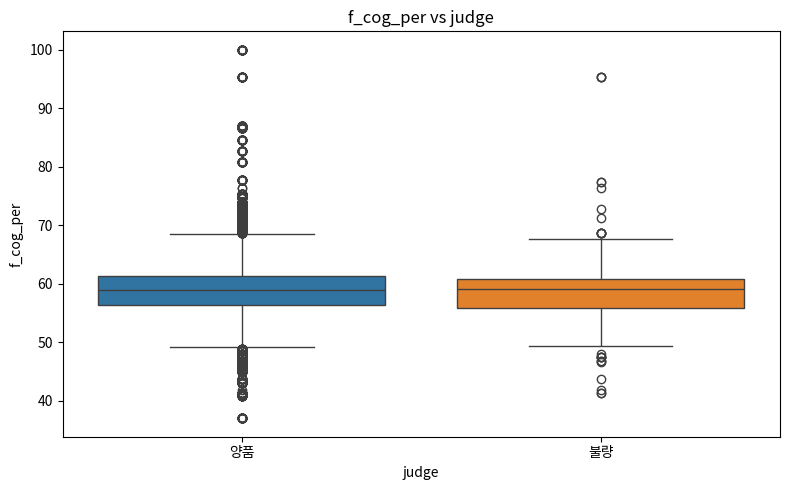

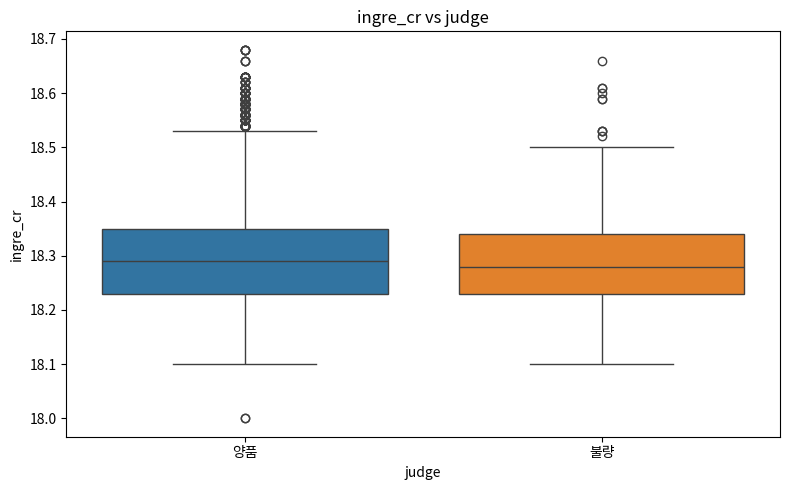

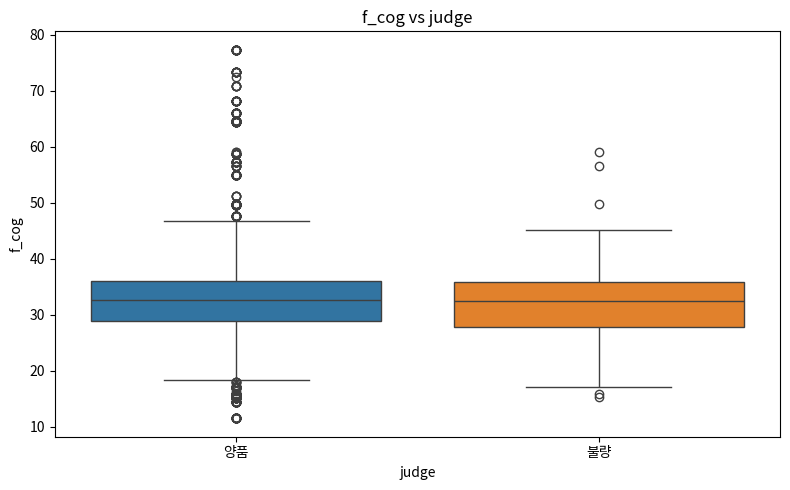

In [ ]:
# 유의 연속형 변수 박스플랏
num_cols = ['f_jangip_temp','process_delay_time1','f_sock_interval',
            'f_total_time','f_pre_temp','heat_pre_diff',
            'ap_line_speed','hr_thick','ap_thick','f_sock_temp',
            'f_pre_interval','f_heat_interval','rm4_temp',
            'f_cog_per','ingre_cr','f_cog']

for col in num_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=final_df, x='judge', y=col, hue = 'judge')
    plt.title(f'{col} vs judge')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

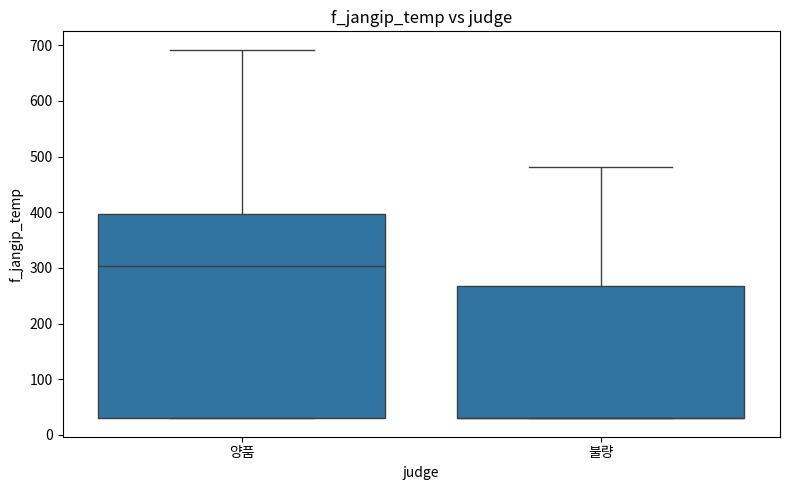

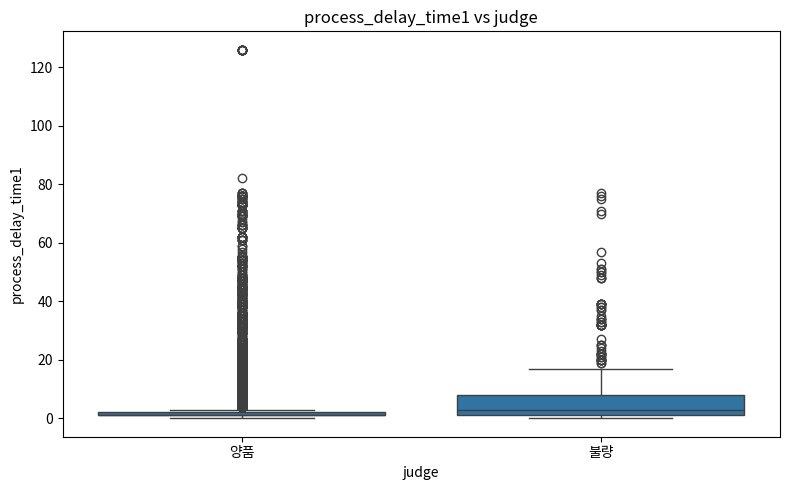

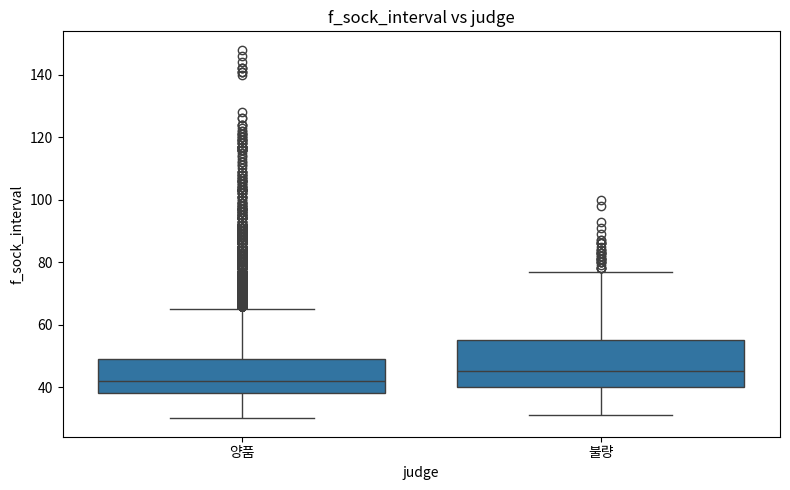

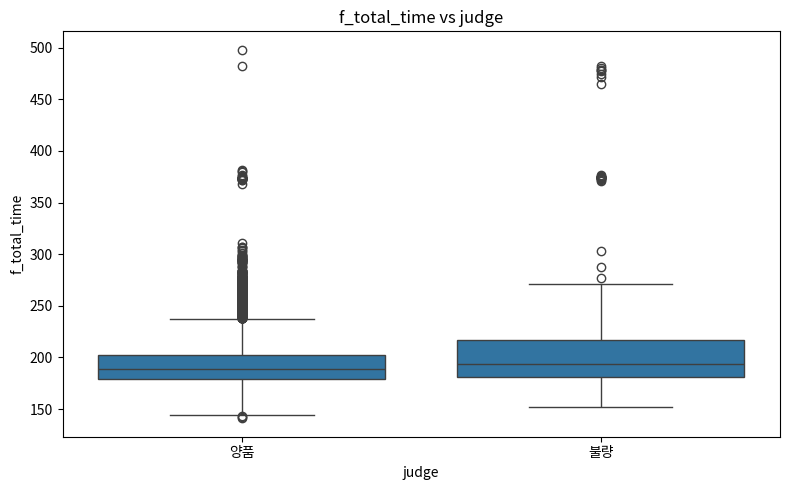

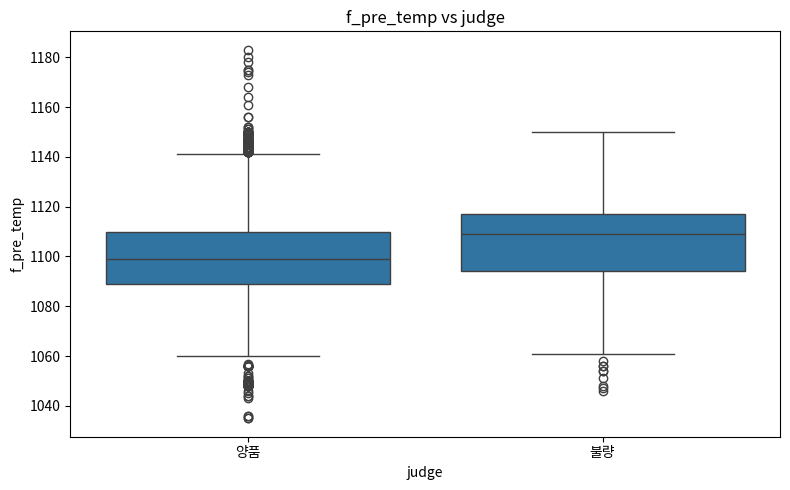

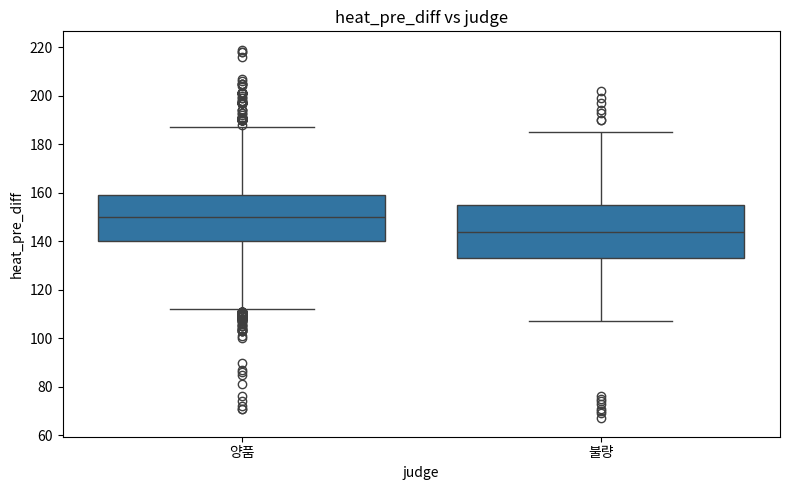

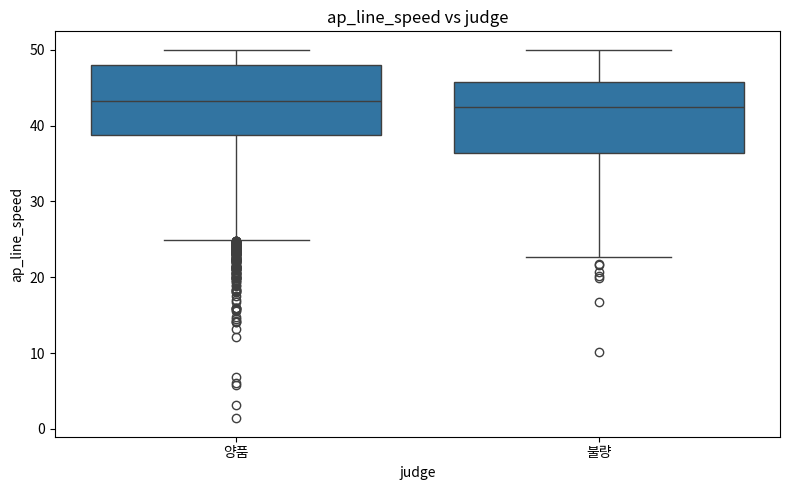

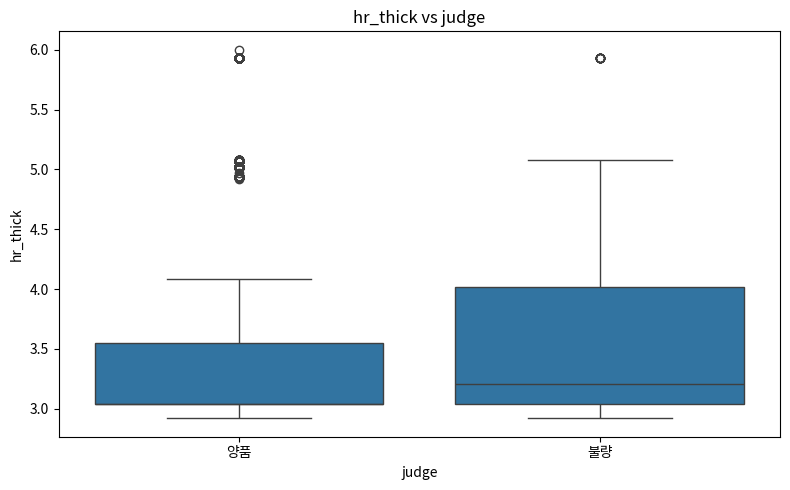

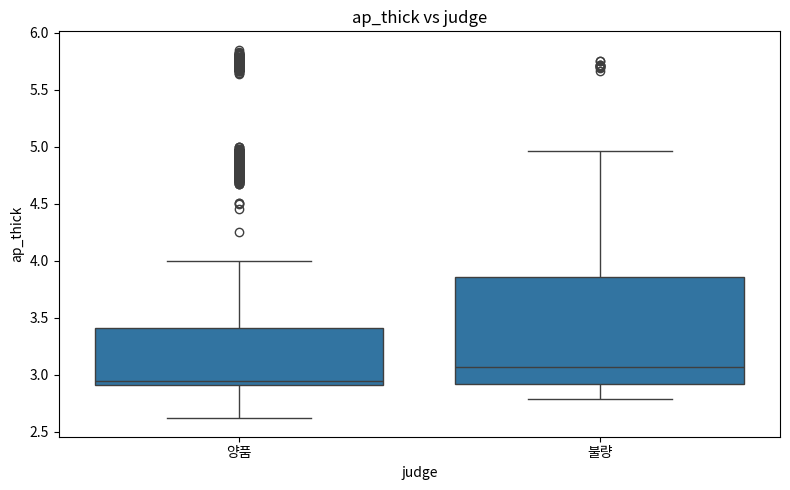

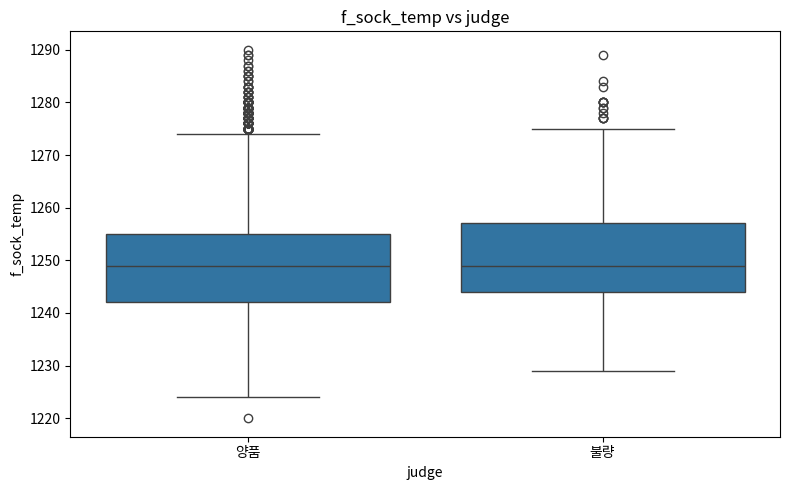

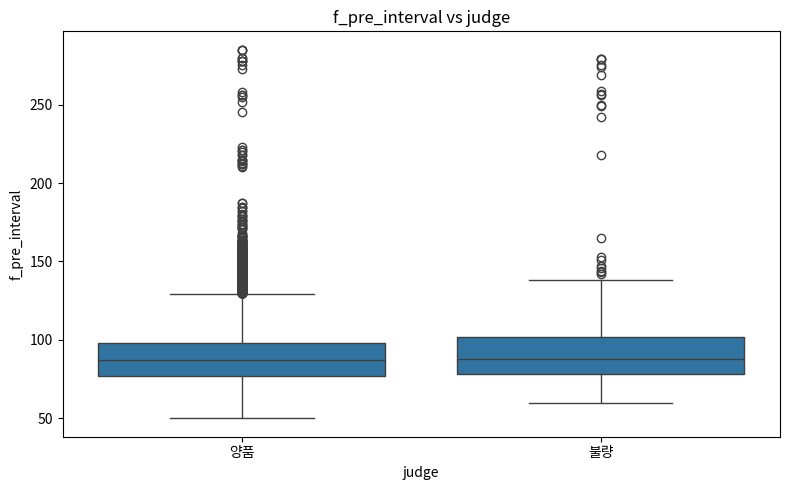

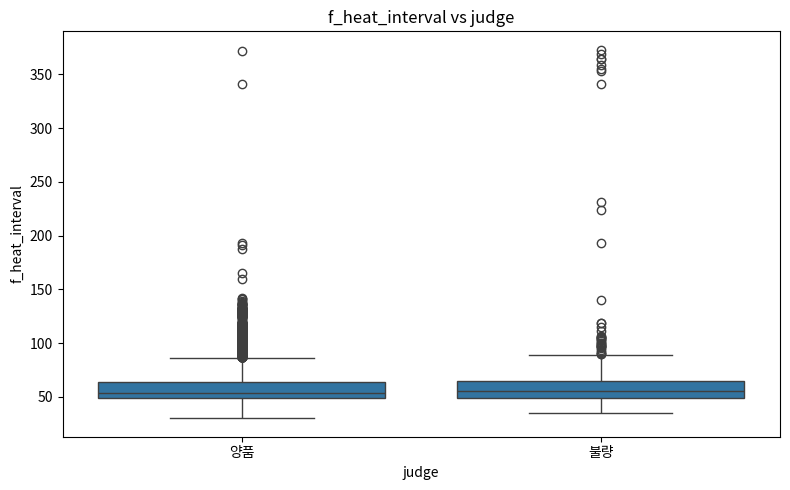

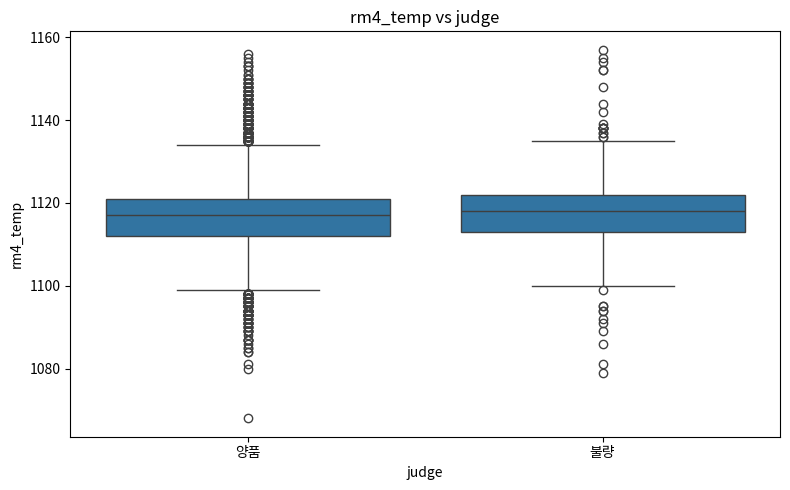

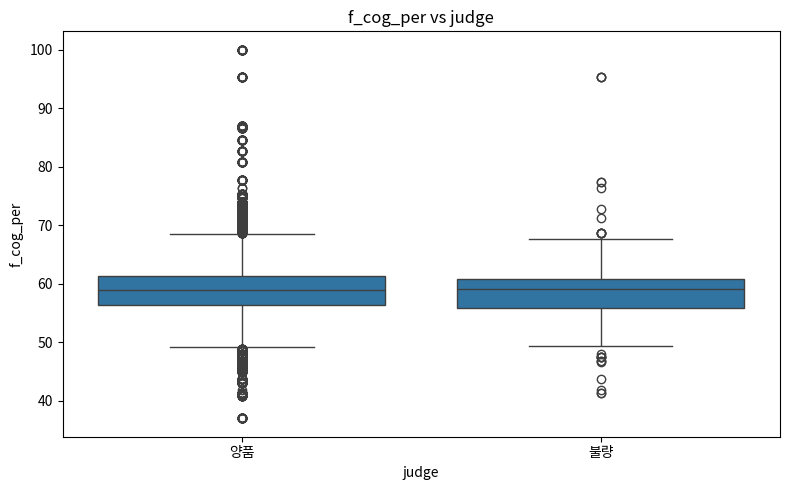

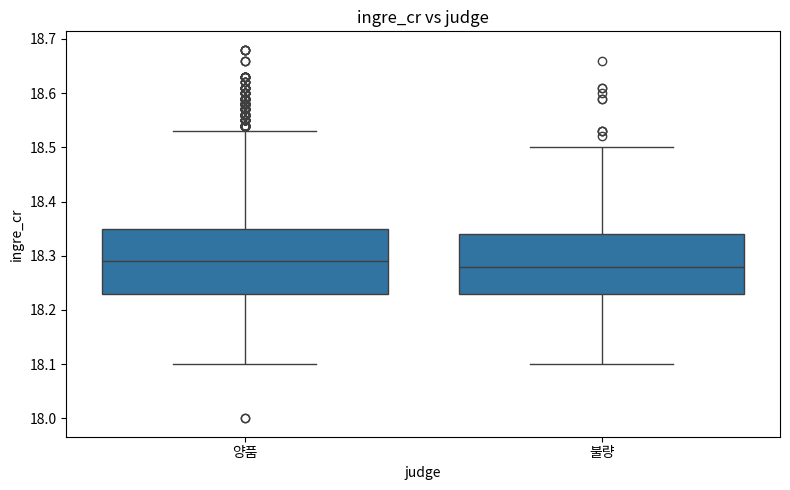

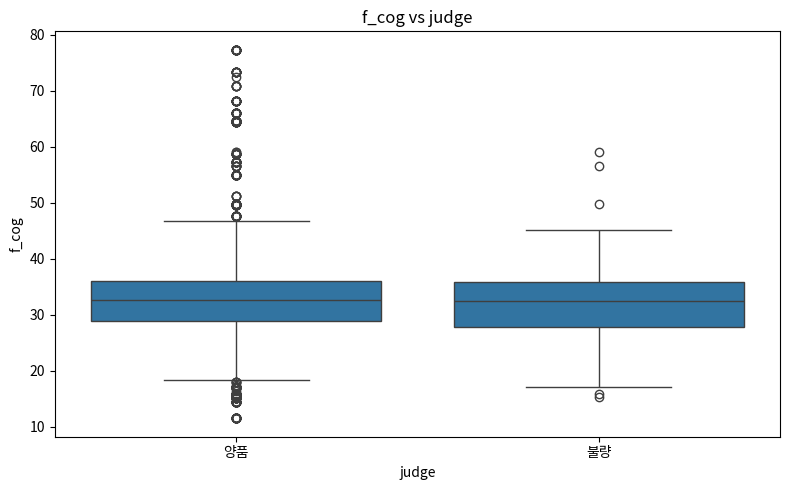

In [ ]:
# 열연공정 1

import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['f_jangip_temp','process_delay_time1','f_sock_interval',
            'f_total_time','f_pre_temp','heat_pre_diff',
            'ap_line_speed','hr_thick','ap_thick','f_sock_temp',
            'f_pre_interval','f_heat_interval','rm4_temp',
            'f_cog_per','ingre_cr','f_cog']

for col in num_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=final_df, x='judge', y=col)
    plt.title(f'{col} vs judge')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np

# num_cols = [
#    'rm4_temp', 'f_heat_speed',  'f_jangip_temp',
#              'process_delay_time1','f_pre_temp','f_sock_interval',
#              'f_heat_constant','f_total_time','ap_line_speed','ap_thick',
#              'process_delay_time2','f_sock_temp','f_ldg','f_ldg_per','mlac_ratio',
#              'slab_width', 'hr_width'
# ]

# for col in num_cols:
#     plt.figure(figsize=(8, 5))
    
#     # 공통 bin 경계
#     x_min = final_df[col].min()
#     x_max = final_df[col].max()
#     bins = np.linspace(x_min, x_max, 31)

#     # 양품 먼저, 연하게
#     sns.histplot(
#         data=final_df[final_df['judge'] == '양품'],
#         x=col,
#         bins=bins,
#         stat='count',
#         alpha=0.25,
#         label='양품',
#     )

#     # 불량 나중에, 진하게
#     sns.histplot(
#         data=final_df[final_df['judge'] == '불량'],
#         x=col,
#         bins=bins,
#         stat='count',
#         alpha=0.9,
#         label='불량'
#     )

#     plt.title(f'{col} by judge')
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

In [ ]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# from IPython.display import display

# # =========================================================
# #1. 기본 설정

# #=========================================================
# #
# target_col = 'judge'
# good_label = '양품'
# bad_label = '불량'

# GOOD_COLOR = '#4C72B0'   # 파란색
# BAD_COLOR  = '#DD4B5A'   # 붉은색

# # 네가 분석할 변수들
# num_cols = [
#     'rm4_temp', 'f_heat_speed',  'f_jangip_temp',
#              'process_delay_time1','f_pre_temp','f_sock_interval',
#              'f_heat_constant','f_total_time','ap_line_speed','ap_thick',
#              'process_delay_time2','f_sock_temp','f_ldg','f_ldg_per','mlac_ratio',
#              'slab_width', 'hr_width'
# ]

# # ---------------------------------------------------------
# # 사용자 기준값 사전
# # 여기에 넣은 변수는 그 값을 기준선으로 사용
# # 없는 변수는 자동으로 중앙값(median) 사용
# # ---------------------------------------------------------
# manual_threshold_dict = {
#     'f_jangip_temp': 200,
#     'rm4_temp': 930,
#     'ap_line_speed': 80,
#     # 필요하면 계속 추가
# }

# # 각 구간 최소 표본 비율
# min_ratio = 0.05

# # 모든 변수 그래프를 다 그리면 너무 많을 수 있으니 True/False로 제어
# show_kde = True
# show_badrate_bar = True
# show_stacked_bar = True

# # =========================================================
# # 2. 함수 정의
# # =========================================================
# def prepare_data(df, x_col, target_col='judge', bad_label='불량'):
#     temp = df[[x_col, target_col]].copy()
#     temp[x_col] = pd.to_numeric(temp[x_col], errors='coerce')
#     temp = temp.dropna(subset=[x_col, target_col]).copy()
#     temp['bad_flag'] = (temp[target_col] == bad_label).astype(int)
#     return temp

# def summarize_by_threshold(data, x_col, threshold):
#     temp = data.copy()
#     temp['구간'] = np.where(temp[x_col] < threshold,
#                           f'{threshold:.2f} 미만',
#                           f'{threshold:.2f} 이상')

#     summary = temp.groupby('구간', observed=False).agg(
#         전체개수=('bad_flag', 'size'),
#         불량개수=('bad_flag', 'sum')
#     ).reset_index()

#     summary['양품개수'] = summary['전체개수'] - summary['불량개수']
#     summary['불량률(%)'] = summary['불량개수'] / summary['전체개수'] * 100
#     summary['양품률(%)'] = summary['양품개수'] / summary['전체개수'] * 100

#     order = [f'{threshold:.2f} 미만', f'{threshold:.2f} 이상']
#     summary['구간'] = pd.Categorical(summary['구간'], categories=order, ordered=True)
#     summary = summary.sort_values('구간').reset_index(drop=True)

#     return summary[['구간', '전체개수', '양품개수', '불량개수', '양품률(%)', '불량률(%)']]

# def find_best_threshold(data, x_col, min_ratio=0.05):
#     x = data[[x_col, 'bad_flag']].dropna().sort_values(x_col).reset_index(drop=True)

#     unique_vals = np.sort(x[x_col].unique())
#     if len(unique_vals) < 2:
#         return None, None

#     candidates = (unique_vals[:-1] + unique_vals[1:]) / 2

#     n = len(x)
#     min_n = max(1, int(n * min_ratio))

#     best_thr = None
#     best_gap = -1
#     best_info = None

#     for thr in candidates:
#         lower = x[x[x_col] < thr]
#         upper = x[x[x_col] >= thr]

#         if len(lower) < min_n or len(upper) < min_n:
#             continue

#         lower_bad_rate = lower['bad_flag'].mean()
#         upper_bad_rate = upper['bad_flag'].mean()
#         gap = abs(upper_bad_rate - lower_bad_rate)

#         if gap > best_gap:
#             best_gap = gap
#             best_thr = thr
#             best_info = {
#                 'threshold': thr,
#                 'lower_n': len(lower),
#                 'upper_n': len(upper),
#                 'lower_bad_rate': lower_bad_rate,
#                 'upper_bad_rate': upper_bad_rate,
#                 'gap': gap
#             }

#     return best_thr, best_info

# def plot_kde_with_thresholds(data, x_col, manual_threshold, best_threshold,
#                              good_label='양품', bad_label='불량'):
#     plt.figure(figsize=(9, 5))

#     sns.kdeplot(
#         data=data[data[target_col] == good_label],
#         x=x_col, fill=True, color=GOOD_COLOR,
#         alpha=0.55, linewidth=1.2, label=good_label
#     )

#     sns.kdeplot(
#         data=data[data[target_col] == bad_label],
#         x=x_col, fill=True, color=BAD_COLOR,
#         alpha=0.40, linewidth=1.2, label=bad_label
#     )

#     ymax = plt.ylim()[1]

#     plt.axvline(x=manual_threshold, color='red', linestyle='--', linewidth=2)
#     plt.text(
#         manual_threshold, ymax * 0.96, f'{manual_threshold:.2f}',
#         color='red', ha='center', va='top', fontsize=11, fontweight='bold'
#     )

#     if best_threshold is not None:
#         plt.axvline(x=best_threshold, color='black', linestyle='--', linewidth=2)
#         plt.text(
#             best_threshold, ymax * 0.88, f'opt={best_threshold:.2f}',
#             color='black', ha='center', va='top', fontsize=10, fontweight='bold'
#         )

#     plt.title(f'{x_col} by judge')
#     plt.xlabel(x_col)
#     plt.ylabel('Density')
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

# def plot_badrate_bar(summary, title):
#     plt.figure(figsize=(6, 4))
#     plt.bar(summary['구간'], summary['불량률(%)'], color=BAD_COLOR, edgecolor='black')
#     plt.title(title)
#     plt.ylabel('불량률 (%)')
#     for i, v in enumerate(summary['불량률(%)']):
#         plt.text(i, v + 0.1, f'{v:.2f}%', ha='center', fontsize=10)
#     plt.tight_layout()
#     plt.show()

# def plot_stacked_bar(summary, title):
#     plt.figure(figsize=(6, 4))
#     plt.bar(summary['구간'], summary['양품개수'],
#             color=GOOD_COLOR, edgecolor='black', label='양품')
#     plt.bar(summary['구간'], summary['불량개수'],
#             bottom=summary['양품개수'],
#             color=BAD_COLOR, edgecolor='black', label='불량')
#     plt.title(title)
#     plt.ylabel('개수')
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

# # =========================================================
# # 3. 전체 변수 일괄 실행
# # =========================================================
# all_compare_rows = []
# all_best_rows = []

# for x_col in num_cols:
#     print('=' * 90)
#     print(f'[변수] {x_col}')

#     try:
#         df_var = prepare_data(final_df, x_col, target_col=target_col, bad_label=bad_label)

#         if len(df_var) == 0:
#             print('유효 데이터가 없어 건너뜀')
#             continue

#         # 사용자 기준값: dict에 있으면 그 값, 없으면 중앙값
#         manual_threshold = manual_threshold_dict.get(x_col, df_var[x_col].median())

#         # 자동 최적 기준값
#         best_threshold, best_info = find_best_threshold(df_var, x_col, min_ratio=min_ratio)

#         # 요약표
#         manual_summary = summarize_by_threshold(df_var, x_col, manual_threshold)

#         if best_threshold is not None:
#             auto_summary = summarize_by_threshold(df_var, x_col, best_threshold)
#         else:
#             auto_summary = None

#         print(f'[사용자 기준값] {manual_threshold:.2f}')
#         display(manual_summary.round(2))

#         if best_threshold is not None:
#             print(f'[자동 최적 기준값] {best_threshold:.2f}')
#             print(f"구간별 불량률 차이 = {best_info['gap']*100:.2f}%p")
#             display(auto_summary.round(2))
#         else:
#             print('자동 최적 기준값을 찾지 못함')

#         # 비교표
#         compare_list = [
#             manual_summary.assign(기준종류=f'사용자기준({manual_threshold:.2f})', 변수=x_col)
#         ]

#         if auto_summary is not None:
#             compare_list.append(
#                 auto_summary.assign(기준종류=f'자동최적({best_threshold:.2f})', 변수=x_col)
#             )

#         compare_df = pd.concat(compare_list, ignore_index=True)
#         compare_df = compare_df[['변수', '기준종류', '구간', '전체개수', '양품개수', '불량개수', '양품률(%)', '불량률(%)']]

#         print('[기준값 비교표]')
#         display(compare_df.round(2))

#         all_compare_rows.append(compare_df)

#         # 최적값 요약 저장
#         manual_gap = abs(manual_summary.loc[0, '불량률(%)'] - manual_summary.loc[1, '불량률(%)']) \
#             if len(manual_summary) == 2 else np.nan

#         all_best_rows.append({
#             '변수': x_col,
#             '사용자기준값': round(manual_threshold, 4),
#             '사용자기준_불량률차이(%p)': round(manual_gap, 4) if pd.notna(manual_gap) else np.nan,
#             '자동최적값': round(best_threshold, 4) if best_threshold is not None else np.nan,
#             '자동최적_불량률차이(%p)': round(best_info['gap'] * 100, 4) if best_info is not None else np.nan,
#             '자동최적_미만불량률(%)': round(best_info['lower_bad_rate'] * 100, 4) if best_info is not None else np.nan,
#             '자동최적_이상불량률(%)': round(best_info['upper_bad_rate'] * 100, 4) if best_info is not None else np.nan
#         })

#         # 그래프
#         if show_kde:
#             plot_kde_with_thresholds(
#                 df_var, x_col, manual_threshold, best_threshold,
#                 good_label=good_label, bad_label=bad_label
#             )

#         if show_badrate_bar:
#             plot_badrate_bar(
#                 manual_summary,
#                 f'{x_col} - 사용자 기준 {manual_threshold:.2f}'
#             )
#             if auto_summary is not None:
#                 plot_badrate_bar(
#                     auto_summary,
#                     f'{x_col} - 자동 최적 기준 {best_threshold:.2f}'
#                 )

#         if show_stacked_bar:
#             plot_stacked_bar(
#                 manual_summary,
#                 f'{x_col} - 사용자 기준 {manual_threshold:.2f}'
#             )
#             if auto_summary is not None:
#                 plot_stacked_bar(
#                     auto_summary,
#                     f'{x_col} - 자동 최적 기준 {best_threshold:.2f}'
#                 )

#     except Exception as e:
#         print(f'에러 발생: {x_col} -> {e}')

# # =========================================================
# # 4. 전체 변수 최적값 요약표
# # =========================================================
# best_summary_df = pd.DataFrame(all_best_rows)
# compare_all_df = pd.concat(all_compare_rows, ignore_index=True) if all_compare_rows else pd.DataFrame()

# print('=' * 90)
# print('[전체 변수 자동 최적값 요약표]')
# display(best_summary_df)

# print('[전체 변수 기준값 비교표 전체]')
# display(compare_all_df.round(2))

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np

# num_cols = [
#         'rm4_temp', 'f_heat_speed',  'f_jangip_temp',
#              'process_delay_time1','f_pre_temp','f_sock_interval',
#              'f_heat_constant','f_total_time','ap_line_speed','ap_thick',
#              'process_delay_time2','f_sock_temp','f_ldg','f_ldg_per','mlac_ratio',
#              'slab_width', 'hr_width'
# ]

# for col in num_cols:
#     plt.figure(figsize=(8, 5))

#     sns.kdeplot(
#         data=final_df[final_df['judge'] == '양품'],
#         x=col,
#         fill=True,
#         common_norm=False,
#         alpha=0.5,
#         # color='royalblue',
#         label='양품'
#     )

#     sns.kdeplot(
#         data=final_df[final_df['judge'] == '불량'],
#         x=col,
#         fill=True,
#         common_norm=False,
#         alpha=0.5,
#         # color='crimson',
#         label='불량'
#     )

#     plt.title(f'{col} by judge')
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np
# import pandas as pd
# from scipy.stats import gaussian_kde

# num_cols = [
#     'f_heat_total', 'f_heat_speed', 'f_total_time',
#     'f_heat_constant', 'f_weighted_avg_temp',
#     'f_heat_input_per_area', 'process_delay_time1','composition_score','process_delay_time2'
# ]

# for col in num_cols:
#     good = final_df.loc[final_df['judge'] == '양품', col].dropna()
#     bad = final_df.loc[final_df['judge'] == '불량', col].dropna()


#     # 데이터가 너무 적거나 값이 거의 하나면 KDE 불가
#     if len(good) < 2 or len(bad) < 2 or good.nunique() < 2 or bad.nunique() < 2:
#         print(f'{col}: KDE 계산 불가')
#         continue

#     plt.figure(figsize=(8, 5))

#     # 기존 KDE 그래프
#     sns.kdeplot(
#         data=final_df[final_df['judge'] == '양품'],
#         x=col,
#         fill=True,
#         common_norm=False,
#         alpha=0.5,
#         # color='royalblue',
#         label='양품'
#     )

#     sns.kdeplot(
#         data=final_df[final_df['judge'] == '불량'],
#         x=col,
#         fill=True,
#         common_norm=False,
#         alpha=0.5,
#         # color='crimson',
#         label='불량'
#     )

#     # 공통 x grid 생성
#     x_min = min(good.min(), bad.min())
#     x_max = max(good.max(), bad.max())
#     x_grid = np.linspace(x_min, x_max, 500)

#     # KDE 직접 계산
#     good_kde = gaussian_kde(good)
#     bad_kde = gaussian_kde(bad)

#     y_good = good_kde(x_grid)
#     y_bad = bad_kde(x_grid)

#     # 불량 KDE가 더 큰 구간 찾기
#     mask = y_bad > y_good

#     # 연속 구간 start/end 찾기
#     diff = np.diff(mask.astype(int))
#     starts = np.where(diff == 1)[0] + 1
#     ends = np.where(diff == -1)[0] + 1

#     if mask[0]:
#         starts = np.insert(starts, 0, 0)
#     if mask[-1]:
#         ends = np.append(ends, len(mask) - 1)

#     # 각 구간에 점선 및 x값 표시
#     y_max = max(y_good.max(), y_bad.max())

#     for s, e in zip(starts, ends):
#         x_start = x_grid[s]
#         x_end = x_grid[e]

#         # 시작/끝 점선
#         plt.axvline(x=x_start, color='red', linestyle='--', linewidth=1.5)
#         plt.axvline(x=x_end, color='red', linestyle='--', linewidth=1.5)

#         # 텍스트 표시
#         plt.text(x_start, y_max * 0.95, f'{x_start:.2f}', color='red',
#                  rotation=90, va='top', ha='right', fontsize=8)
#         plt.text(x_end, y_max * 0.95, f'{x_end:.2f}', color='red',
#                  rotation=90, va='top', ha='left', fontsize=8)

#     plt.title(f'{col} by judge')
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

#     # 콘솔에도 구간 출력
#     if len(starts) > 0:
#         print(f'\n[{col}] 불량 KDE > 양품 KDE 구간')
#         for s, e in zip(starts, ends):
#             print(f' - {x_grid[s]:.4f} ~ {x_grid[e]:.4f}')
#     else:
#         print(f'\n[{col}] 불량 KDE > 양품 KDE 구간 없음')

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np
# import pandas as pd
# from scipy.stats import gaussian_kde

# num_cols = [
#     'f_heat_total', 'f_heat_speed', 'f_total_time',
#     'f_heat_constant', 'f_weighted_avg_temp',
#     'f_heat_input_per_area', 'process_delay_time1','composition_score','process_delay_time2'
# ]

# for col in num_cols:
#     good = final_df.loc[final_df['judge'] == '양품', col].dropna()
#     bad = final_df.loc[final_df['judge'] == '불량', col].dropna()


#     # 데이터가 너무 적거나 값이 거의 하나면 KDE 불가
#     if len(good) < 2 or len(bad) < 2 or good.nunique() < 2 or bad.nunique() < 2:
#         print(f'{col}: KDE 계산 불가')
#         continue

#     plt.figure(figsize=(8, 5))

#     # 기존 KDE 그래프
#     sns.kdeplot(
#         data=final_df[final_df['judge'] == '양품'],
#         x=col,
#         fill=True,
#         common_norm=False,
#         alpha=0.5,
#         color='royalblue',
#         label='양품'
#     )

#     sns.kdeplot(
#         data=final_df[final_df['judge'] == '불량'],
#         x=col,
#         fill=True,
#         common_norm=False,
#         alpha=0.5,
#         color='crimson',
#         label='불량'
#     )

#     # 공통 x grid 생성
#     x_min = min(good.min(), bad.min())
#     x_max = max(good.max(), bad.max())
#     x_grid = np.linspace(x_min, x_max, 500)

#     # KDE 직접 계산
#     good_kde = gaussian_kde(good)
#     bad_kde = gaussian_kde(bad)

#     y_good = good_kde(x_grid)
#     y_bad = bad_kde(x_grid)

#     # 불량 KDE가 더 큰 구간 찾기
#     mask = y_bad > y_good

#     # 연속 구간 start/end 찾기
#     diff = np.diff(mask.astype(int))
#     starts = np.where(diff == 1)[0] + 1
#     ends = np.where(diff == -1)[0] + 1

#     if mask[0]:
#         starts = np.insert(starts, 0, 0)
#     if mask[-1]:
#         ends = np.append(ends, len(mask) - 1)

#     # 각 구간에 점선 및 x값 표시
#     y_max = max(y_good.max(), y_bad.max())

#     for s, e in zip(starts, ends):
#         x_start = x_grid[s]
#         x_end = x_grid[e]

#         # 시작/끝 점선
#         plt.axvline(x=x_start, color='red', linestyle='--', linewidth=1.5)
#         plt.axvline(x=x_end, color='red', linestyle='--', linewidth=1.5)

#         # 텍스트 표시
#         plt.text(x_start, y_max * 0.95, f'{x_start:.2f}', color='red',
#                  rotation=90, va='top', ha='right', fontsize=8)
#         plt.text(x_end, y_max * 0.95, f'{x_end:.2f}', color='red',
#                  rotation=90, va='top', ha='left', fontsize=8)

#     plt.title(f'{col} by judge')
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

#     # 콘솔에도 구간 출력
#     if len(starts) > 0:
#         print(f'\n[{col}] 불량 KDE > 양품 KDE 구간')
#         for s, e in zip(starts, ends):
#             print(f' - {x_grid[s]:.4f} ~ {x_grid[e]:.4f}')
#     else:
#         print(f'\n[{col}] 불량 KDE > 양품 KDE 구간 없음')

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np
# import pandas as pd
# from scipy.stats import gaussian_kde

# num_cols = [
#     'f_heat_total', 'f_heat_speed', 'f_total_time',
#     'f_heat_constant', 'f_weighted_avg_temp',
#     'f_heat_input_per_area', 'process_delay_time1','composition_score','process_delay_time2'
# ]

# for col in num_cols:
#     good = final_df.loc[final_df['judge'] == '양품', col].dropna()
#     bad = final_df.loc[final_df['judge'] == '불량', col].dropna()


#     # 데이터가 너무 적거나 값이 거의 하나면 KDE 불가
#     if len(good) < 2 or len(bad) < 2 or good.nunique() < 2 or bad.nunique() < 2:
#         print(f'{col}: KDE 계산 불가')
#         continue

#     plt.figure(figsize=(8, 5))

#     # 기존 KDE 그래프
#     sns.kdeplot(
#         data=final_df[final_df['judge'] == '양품'],
#         x=col,
#         fill=True,
#         common_norm=False,
#         alpha=0.5,
#         color='royalblue',
#         label='양품'
#     )

#     sns.kdeplot(
#         data=final_df[final_df['judge'] == '불량'],
#         x=col,
#         fill=True,
#         common_norm=False,
#         alpha=0.5,
#         color='crimson',
#         label='불량'
#     )

#     # 공통 x grid 생성
#     x_min = min(good.min(), bad.min())
#     x_max = max(good.max(), bad.max())
#     x_grid = np.linspace(x_min, x_max, 500)

#     # KDE 직접 계산
#     good_kde = gaussian_kde(good)
#     bad_kde = gaussian_kde(bad)

#     y_good = good_kde(x_grid)
#     y_bad = bad_kde(x_grid)

#     # 불량 KDE가 더 큰 구간 찾기
#     mask = y_bad > y_good

#     # 연속 구간 start/end 찾기
#     diff = np.diff(mask.astype(int))
#     starts = np.where(diff == 1)[0] + 1
#     ends = np.where(diff == -1)[0] + 1

#     if mask[0]:
#         starts = np.insert(starts, 0, 0)
#     if mask[-1]:
#         ends = np.append(ends, len(mask) - 1)

#     # 각 구간에 점선 및 x값 표시
#     y_max = max(y_good.max(), y_bad.max())

#     for s, e in zip(starts, ends):
#         x_start = x_grid[s]
#         x_end = x_grid[e]

#         # 시작/끝 점선
#         plt.axvline(x=x_start, color='red', linestyle='--', linewidth=1.5)
#         plt.axvline(x=x_end, color='red', linestyle='--', linewidth=1.5)

#         # 텍스트 표시
#         plt.text(x_start, y_max * 0.95, f'{x_start:.2f}', color='red',
#                  rotation=90, va='top', ha='right', fontsize=8)
#         plt.text(x_end, y_max * 0.95, f'{x_end:.2f}', color='red',
#                  rotation=90, va='top', ha='left', fontsize=8)

#     plt.title(f'{col} by judge')
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

#     # 콘솔에도 구간 출력
#     if len(starts) > 0:
#         print(f'\n[{col}] 불량 KDE > 양품 KDE 구간')
#         for s, e in zip(starts, ends):
#             print(f' - {x_grid[s]:.4f} ~ {x_grid[e]:.4f}')
#     else:
#         print(f'\n[{col}] 불량 KDE > 양품 KDE 구간 없음')

In [ ]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# target_ranges = {
#     'composition_score': [
#         (6.0310, 6.2019, 10),
#         (6.2408, 6.3920, 10)
#     ],
#     'process_delay_time1': [
#         (6.7735, 11.4729, 10)
#     ],
#     'f_heat_total': [
#         (244699.2138, 555726.5135, 30)
#     ],
#     'f_heat_speed': [
#         (0.1850, 2.0671, 10)
#     ],
#     'f_total_time': [
#         (206.1042, 498.0000, 30)
#     ]
# }

# bad_label = '불량'

# for col, ranges in target_ranges.items():
#     for idx, (low, high, n_bins) in enumerate(ranges, start=1):

#         temp = final_df[[col, 'judge']].dropna().copy()
#         temp = temp[(temp[col] >= low) & (temp[col] <= high)].copy()

#         bad_df = temp[temp['judge'] == bad_label].copy()

#         if len(temp) == 0 or len(bad_df) == 0:
#             print(f'[{col} - 구간 {idx}] 데이터 없음')
#             continue

#         bins = np.linspace(low, high, n_bins + 1)
#         bad_df['bin'] = pd.cut(
#             bad_df[col],
#             bins=bins,
#             include_lowest=True,
#             right=False
#         )

#         summary = (
#             bad_df.groupby('bin', observed=False)
#             .size()
#             .reset_index(name='bad_count')
#         )

#         # 핵심: left/right를 float으로 변환
#         summary['bin_left'] = summary['bin'].apply(lambda x: x.left).astype(float)
#         summary['bin_right'] = summary['bin'].apply(lambda x: x.right).astype(float)
#         summary['bin_mid'] = (summary['bin_left'] + summary['bin_right']) / 2
#         summary['bin_label'] = (
#             summary['bin_left'].round(4).astype(str) +
#             ' ~ ' +
#             summary['bin_right'].round(4).astype(str)
#         )

#         total_bad = summary['bad_count'].sum()
#         summary['bad_ratio_sum1'] = summary['bad_count'] / total_bad

#         print(f'\n===== {col} | 구간 {idx}: {low} ~ {high} =====')
#         print(summary[['bin_label', 'bad_count', 'bad_ratio_sum1']])

#         # 1) 불량 비중(합=1) 꺾은선
#         plt.figure(figsize=(12, 5))
#         plt.plot(summary['bin_mid'], summary['bad_ratio_sum1'], marker='o')
#         for x, y in zip(summary['bin_mid'], summary['bad_ratio_sum1']):
#             if y > 0:
#                 plt.text(x, y, f'{y:.3f}', ha='center', va='bottom', fontsize=8)

#         plt.xlabel(col)
#         plt.ylabel('불량 비중 (합=1)')
#         plt.title(f'{col} 구간 {idx} [{low:.4f} ~ {high:.4f}] - 구간별 불량 비중')
#         plt.grid(True, alpha=0.3)
#         plt.tight_layout()
#         plt.show()

#         # 2) 불량 개수 막대
#         plt.figure(figsize=(14, 5))
#         plt.bar(summary['bin_label'], summary['bad_count'], edgecolor='black')
#         for i, v in enumerate(summary['bad_count']):
#             if v > 0:
#                 plt.text(i, v, str(int(v)), ha='center', va='bottom', fontsize=8)

#         plt.xticks(rotation=45, ha='right')
#         plt.xlabel(col)
#         plt.ylabel('불량 개수')
#         plt.title(f'{col} 구간 {idx} [{low:.4f} ~ {high:.4f}] - 구간별 불량 개수')
#         plt.tight_layout()
#         plt.show()

In [ ]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# target_ranges = {
#     'composition_score': [
#         (6.0310, 6.2019, 10),
#         (6.2408, 6.3920, 10)
#     ],
#     'process_delay_time1': [
#         (6.7735, 11.4729, 10)
#     ],
#     'f_heat_total': [
#         (244699.2138, 555726.5135, 30)
#     ],
#     'f_heat_speed': [
#         (0.1850, 2.0671, 10)
#     ],
#     'f_total_time': [
#         (206.1042, 498.0000, 30)
#     ]
# }

# bad_label = '불량'
# total_bad_all = 629   # 전체 불량 개수

# for col, ranges in target_ranges.items():
#     for idx, (low, high, n_bins) in enumerate(ranges, start=1):

#         temp = final_df[[col, 'judge']].dropna().copy()
#         temp = temp[(temp[col] >= low) & (temp[col] <= high)].copy()

#         bad_df = temp[temp['judge'] == bad_label].copy()

#         if len(temp) == 0 or len(bad_df) == 0:
#             print(f'[{col} - 구간 {idx}] 데이터 없음')
#             continue

#         bins = np.linspace(low, high, n_bins + 1)
#         bad_df['bin'] = pd.cut(
#             bad_df[col],
#             bins=bins,
#             include_lowest=True,
#             right=False
#         )

#         summary = (
#             bad_df.groupby('bin', observed=False)
#             .size()
#             .reset_index(name='bad_count')
#         )

#         summary['bin_left'] = summary['bin'].apply(lambda x: x.left).astype(float)
#         summary['bin_right'] = summary['bin'].apply(lambda x: x.right).astype(float)
#         summary['bin_mid'] = (summary['bin_left'] + summary['bin_right']) / 2
#         summary['bin_label'] = (
#             summary['bin_left'].round(4).astype(str) +
#             ' ~ ' +
#             summary['bin_right'].round(4).astype(str)
#         )

#         # 구간 내부 불량 비중 (합=1)
#         total_bad_in_range = summary['bad_count'].sum()
#         summary['bad_ratio_sum1'] = summary['bad_count'] / total_bad_in_range

#         # 전체 불량 629개 기준 비중
#         summary['bad_ratio_629'] = summary['bad_count'] / total_bad_all

#         print(f'\n===== {col} | 구간 {idx}: {low} ~ {high} =====')
#         print(summary[['bin_label', 'bad_count', 'bad_ratio_sum1', 'bad_ratio_629']])

#         # 1) 불량 비중(구간 내부 합=1) 꺾은선
#         plt.figure(figsize=(12, 5))
#         plt.plot(summary['bin_mid'], summary['bad_ratio_sum1'], marker='o')
#         for x, y in zip(summary['bin_mid'], summary['bad_ratio_sum1']):
#             if y > 0:
#                 plt.text(x, y, f'{y:.3f}', ha='center', va='bottom', fontsize=8)

#         plt.xlabel(col)
#         plt.ylabel('불량 비중 (구간 내 합=1)')
#         plt.title(f'{col} 구간 {idx} [{low:.4f} ~ {high:.4f}] - 구간별 불량 비중')
#         plt.grid(True, alpha=0.3)
#         plt.tight_layout()
#         plt.show()

#         # 2) 전체 불량 629개 기준 비중 막대그래프
#         plt.figure(figsize=(14, 5))
#         plt.bar(summary['bin_label'], summary['bad_ratio_629'], edgecolor='black')

#         for i, v in enumerate(summary['bad_ratio_629']):
#             if v > 0:
#                 plt.text(i, v, f'{v:.3f}', ha='center', va='bottom', fontsize=8)

#         plt.xticks(rotation=45, ha='right')
#         plt.xlabel(col)
#         plt.ylabel('불량 비중 (bad_count / 629)')
#         plt.title(f'{col} 구간 {idx} [{low:.4f} ~ {high:.4f}] - 전체 불량 629개 기준 비중')
#         plt.tight_layout()
#         plt.show()

In [ ]:
# import pandas as pd
# import numpy as np

# num_cols = [
#     'f_jangip_temp', 'f_bfg', 'f_cog', 'f_ldg',
#     'f_bfg_per', 'f_cog_per', 'f_ldg_per',
#     'f_pre_temp', 'f_heat_temp', 'f_sock_temp',
#     'f_pre_interval', 'f_heat_interval', 'f_sock_interval'
# ]

# result_all = []

# for col in num_cols:
#     good = final_df[final_df['judge'] == '양품'][col].dropna()
#     bad = final_df[final_df['judge'] == '불량'][col].dropna()

#     # 전체 범위 기준으로 동일 bin 설정
#     x_min = final_df[col].min()
#     x_max = final_df[col].max()
#     bins = np.linspace(x_min, x_max, 31)   # 30개 구간

#     # 구간별 개수
#     good_hist, bin_edges = np.histogram(good, bins=bins)
#     bad_hist, _ = np.histogram(bad, bins=bins)

#     # 각 집단 내 비율로 변환
#     good_ratio = good_hist / good_hist.sum()
#     bad_ratio = bad_hist / bad_hist.sum()

#     # 구간 정보 정리
#     temp_df = pd.DataFrame({
#         '변수': col,
#         '구간시작': bin_edges[:-1],
#         '구간끝': bin_edges[1:],
#         '양품개수': good_hist,
#         '불량개수': bad_hist,
#         '양품비율': good_ratio,
#         '불량비율': bad_ratio,
#         '비율차이(불량-양품)': bad_ratio - good_ratio
#     })

#     # 불량 비율이 더 높은 구간만 추출
#     higher_bad = temp_df[temp_df['불량비율'] > temp_df['양품비율']].copy()

#     result_all.append(higher_bad)

# result_df = pd.concat(result_all, ignore_index=True)

# # 보기 좋게 정렬
# result_df = result_df.sort_values(
#     ['변수', '비율차이(불량-양품)'],
#     ascending=[True, False]
# )

# print(result_df)

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# # 복사
# plot_df = result_df.copy()

# # 구간 문자열 생성
# plot_df['구간'] = (
#     plot_df['구간시작'].round(2).astype(str) + ' ~ ' +
#     plot_df['구간끝'].round(2).astype(str)
# )

# # 실제 불량률 계산
# plot_df['총개수'] = plot_df['양품개수'] + plot_df['불량개수']
# plot_df['구간불량률'] = plot_df['불량개수'] / plot_df['총개수']

# # 변수별 상위 위험구간 Top 5
# top_risk_df = (
#     plot_df.sort_values(['변수', '구간불량률'], ascending=[True, False])
#            .groupby('변수')
#            .head(3)
#            .copy()
# )

# # 시각화
# g = sns.FacetGrid(
#     top_risk_df,
#     col='변수',
#     col_wrap=3,
#     sharex=False,
#     sharey=False,
#     height=4
# )

# g.map_dataframe(
#     sns.barplot,
#     x='구간',
#     y='구간불량률'
# )

# g.set_titles('{col_name}')
# g.set_axis_labels('구간', '불량률')

# for ax in g.axes.flatten():
#     ax.tick_params(axis='x', rotation=45)
#     for container in ax.containers:
#         ax.bar_label(container, fmt='%.3f', fontsize=8)

# plt.tight_layout()
# plt.show()

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# # 네 실제 데이터프레임 이름으로 바꿔라
# df_main = final_df.copy()

# # 네 judge 컬럼의 불량 라벨로 바꿔라
# bad_label = '불량'

# gas_cols = ['f_bfg', 'f_cog', 'f_ldg']

# for col in gas_cols:
#     df_main[col + '_use'] = (df_main[col].fillna(0) > 0).astype(int)

# result_list = []

# for col in gas_cols:
#     use_col = col + '_use'

#     summary = df_main.groupby(use_col).agg(
#         total=('judge', 'size'),
#         bad=('judge', lambda s: (s == bad_label).sum())
#     ).reset_index()

#     summary['bad_rate'] = summary['bad'] / summary['total']
#     summary['gas'] = col.replace('f_', '').upper()
#     summary['use_label'] = summary[use_col].map({0: '미사용', 1: '사용'})

#     result_list.append(summary[['gas', 'use_label', 'total', 'bad', 'bad_rate']])

# gas_use_df = pd.concat(result_list, ignore_index=True)

# display(gas_use_df.round(4))

# plt.figure(figsize=(10, 6))
# sns.barplot(data=gas_use_df, x='gas', y='bad_rate', hue='use_label')
# plt.title('Gas usage vs bad rate')
# plt.xlabel('Gas')
# plt.ylabel('Bad rate')
# plt.show()

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# gas_cols = ['f_bfg_per', 'f_cog_per', 'f_ldg_per']

# # long format으로 변환
# plot_df = final_df[['judge'] + gas_cols].melt(
#     id_vars='judge',
#     value_vars=gas_cols,
#     var_name='gas_type',
#     value_name='gas_ratio'
# )

# plt.figure(figsize=(10, 6))
# sns.barplot(
#     data=plot_df,
#     x='gas_type',
#     y='gas_ratio',
#     hue='judge',
#     estimator='mean',
#     errorbar=None
# )

# plt.title('가스 함량비 평균 비교 (양품 vs 불량)')
# plt.xlabel('가스 종류')
# plt.ylabel('평균 함량비')
# plt.grid(axis='y', alpha=0.3)
# plt.legend(title='판정')
# plt.show()

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt

# bad_label = '불량'
# gas_cols = ['f_bfg_per', 'f_cog_per', 'f_ldg_per']

# for col in gas_cols:
#     temp_df = final_df[[col, 'judge']].dropna().copy()

#     temp_df['bin'] = pd.qcut(temp_df[col], q=10, duplicates='drop')

#     grouped = temp_df.groupby('bin', observed=False).agg(
#         total=('judge', 'size'),
#         bad=('judge', lambda x: (x == bad_label).sum()),
#         x_min=(col, 'min'),
#         x_max=(col, 'max')
#     ).reset_index(drop=True)

#     grouped['bad_rate'] = grouped['bad'] / grouped['total']
#     grouped['label'] = (
#         grouped['x_min'].round(2).astype(str) + ' ~ ' +
#         grouped['x_max'].round(2).astype(str)
#     )

#     plt.figure(figsize=(12, 5))
#     plt.bar(grouped['label'], grouped['bad_rate'])
#     plt.xticks(rotation=45, ha='right')
#     plt.title(f'{col} 구간별 불량률')
#     plt.xlabel('구간')
#     plt.ylabel('불량률')
#     plt.grid(axis='y', alpha=0.3)
#     plt.show()

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# gas_cols = ['f_bfg_per', 'f_cog_per', 'f_ldg_per']

# for col in gas_cols:
#     temp_df = final_df[[col, 'judge']].dropna().copy()
#     temp_df['bin'] = pd.qcut(temp_df[col], q=10, duplicates='drop')

#     count_df = temp_df.groupby(['bin', 'judge'], observed=False).size().reset_index(name='count')
#     count_df['label'] = count_df['bin'].astype(str)

#     plt.figure(figsize=(12, 5))
#     sns.barplot(data=count_df, x='label', y='count', hue='judge')
#     plt.xticks(rotation=45, ha='right')
#     plt.title(f'{col} 구간별 양품/불량 개수')
#     plt.xlabel('구간')
#     plt.ylabel('개수')
#     plt.grid(axis='y', alpha=0.3)
#     plt.show()

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt

# # 원본이 final_df가 아니라면 df 이름만 바꿔서 사용
# df = final_df.copy()

# # 1. 날짜형으로 변환
# df['f_ext_date'] = pd.to_datetime(df['f_ext_date'], errors='coerce')

# # 2. 날짜만 추출
# df['f_ext_day'] = df['f_ext_date'].dt.date

# # 3. 불량 여부를 0/1로 변환
# df['bad_flag'] = (df['judge'] == '불량').astype(int)

# # 4. 추출일별 집계
# ext_day_summary = (
#     df.groupby('f_ext_day')
#       .agg(
#           total_cnt=('judge', 'size'),
#           bad_cnt=('bad_flag', 'sum')
#       )
#       .reset_index()
# )

# # 5. 불량률 계산
# ext_day_summary['bad_rate'] = ext_day_summary['bad_cnt'] / ext_day_summary['total_cnt']

# # 6. 불량률 높은 순으로 보기
# ext_day_summary_sorted = ext_day_summary.sort_values('bad_rate', ascending=False)

# display(ext_day_summary_sorted)

In [ ]:
# df['f_ext_month'] = df['f_ext_date'].dt.to_period('M').astype(str)

# month_summary = (
#     df.groupby('f_ext_month')
#       .agg(
#           total_cnt=('judge', 'size'),
#           bad_cnt=('bad_flag', 'sum')
#       )
#       .reset_index()
# )

# month_summary['bad_rate'] = month_summary['bad_cnt'] / month_summary['total_cnt']

# display(month_summary)

In [ ]:
# import matplotlib.pyplot as plt
# import pandas as pd

# df = final_df.copy()

# df['f_ext_time'] = pd.to_numeric(df['f_ext_time'], errors='coerce')

# hour_counts = (
#     df.loc[df['f_ext_time'].between(0, 23), 'f_ext_time']
#       .value_counts()
#       .sort_index()
#       .reindex(range(24), fill_value=0)
# )

# plt.figure(figsize=(12, 5))
# plt.bar(hour_counts.index, hour_counts.values, edgecolor='black')

# plt.xticks(range(24))
# plt.xlabel('추출 시간(시)')
# plt.ylabel('빈도수')
# plt.title('f_ext_time 시간대별 분포')
# plt.tight_layout()
# plt.show()

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt

# df = final_df.copy()

# df['f_ext_time'] = pd.to_numeric(df['f_ext_time'], errors='coerce')
# df = df[df['f_ext_time'].between(0, 23)].copy()

# df['bad_flag'] = (df['judge'] == '불량').astype(int)

# hour_summary = (
#     df.groupby('f_ext_time')
#       .agg(
#           total_cnt=('judge', 'size'),
#           bad_cnt=('bad_flag', 'sum')
#       )
#       .reindex(range(24), fill_value=0)
#       .reset_index()
# )

# hour_summary['bad_rate'] = hour_summary['bad_cnt'] / hour_summary['total_cnt']
# hour_summary['bad_rate'] = hour_summary['bad_rate'].fillna(0)

# display(hour_summary)

# fig, ax1 = plt.subplots(figsize=(12, 5))

# ax1.bar(hour_summary['f_ext_time'], hour_summary['total_cnt'], alpha=0.6, label='생산수')
# ax1.bar(hour_summary['f_ext_time'], hour_summary['bad_cnt'], alpha=0.9, label='불량수')
# ax1.set_xlabel('추출 시간(시)')
# ax1.set_ylabel('개수')
# ax1.set_xticks(range(24))

# ax2 = ax1.twinx()
# ax2.plot(hour_summary['f_ext_time'], hour_summary['bad_rate'], marker='o')
# ax2.set_ylabel('불량률')

# ax1.legend(loc='upper left')
# plt.title('추출 시간대별 생산수 / 불량수 / 불량률')
# plt.tight_layout()
# plt.show()

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt

# df = final_df.copy()
# df['f_ext_time'] = pd.to_numeric(df['f_ext_time'], errors='coerce')
# df = df[df['f_ext_time'].between(0, 23)].copy()

# df['bad_flag'] = (df['judge'] == '불량').astype(int)

# hour_summary = (
#     df.groupby('f_ext_time')
#       .agg(
#           total_cnt=('judge', 'size'),
#           bad_cnt=('bad_flag', 'sum')
#       )
#       .reindex(range(24), fill_value=0)
#       .reset_index()
# )

# # 시간대별 불량률
# hour_summary['bad_rate'] = hour_summary['bad_cnt'] / hour_summary['total_cnt']
# hour_summary['bad_rate'] = hour_summary['bad_rate'].fillna(0)

# # 시간대별 불량 비중 (합 = 1)
# total_bad = hour_summary['bad_cnt'].sum()
# hour_summary['bad_share'] = hour_summary['bad_cnt'] / total_bad if total_bad > 0 else 0

# # 시간대별 생산 비중 (합 = 1)
# total_prod = hour_summary['total_cnt'].sum()
# hour_summary['prod_share'] = hour_summary['total_cnt'] / total_prod if total_prod > 0 else 0

# display(hour_summary)

# print('불량률 합계:', hour_summary['bad_rate'].sum())
# print('불량 비중 합계:', hour_summary['bad_share'].sum())
# print('생산 비중 합계:', hour_summary['prod_share'].sum())

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import numpy as np

# df = final_df.copy()

# # 1. 시간값 숫자형 변환
# df['f_ext_time'] = pd.to_numeric(df['f_ext_time'], errors='coerce')
# df = df[df['f_ext_time'].between(0, 23)].copy()

# # 2. 불량 플래그 생성
# df['bad_flag'] = (df['judge'] == '불량').astype(int)

# # 3. 시간대별 집계
# hour_summary = (
#     df.groupby('f_ext_time')
#       .agg(
#           total_cnt=('judge', 'size'),
#           bad_cnt=('bad_flag', 'sum')
#       )
#       .reindex(range(24), fill_value=0)
#       .reset_index()
# )

# # 4. 지표 계산
# hour_summary['bad_rate'] = hour_summary['bad_cnt'] / hour_summary['total_cnt']
# hour_summary['bad_rate'] = hour_summary['bad_rate'].fillna(0)

# total_bad = hour_summary['bad_cnt'].sum()
# total_prod = hour_summary['total_cnt'].sum()

# hour_summary['bad_share'] = hour_summary['bad_cnt'] / total_bad if total_bad > 0 else 0
# hour_summary['prod_share'] = hour_summary['total_cnt'] / total_prod if total_prod > 0 else 0

# display(hour_summary)

# # 5. 그래프
# x = np.arange(24)
# width = 0.25

# plt.figure(figsize=(15, 6))
# plt.bar(x - width, hour_summary['bad_rate'], width=width, label='불량률', edgecolor='black')
# plt.bar(x,         hour_summary['bad_share'], width=width, label='불량비중', edgecolor='black')
# plt.bar(x + width, hour_summary['prod_share'], width=width, label='생산비중', edgecolor='black')

# plt.xticks(range(24))
# plt.xlabel('추출 시간(시)')
# plt.ylabel('비율')
# plt.title('추출 시간대별 불량률 / 불량비중 / 생산비중 비교')
# plt.legend()
# plt.tight_layout()
# plt.show()

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt

# df = final_df.copy()

# # 1. hr_thick 숫자형 변환
# df['hr_thick'] = pd.to_numeric(df['hr_thick'], errors='coerce')

# # 2. 불량 여부 플래그
# df['bad_flag'] = (df['judge'] == '불량').astype(int)

# # 3. hr_thick 10등분
# df = df.dropna(subset=['hr_thick']).copy()
# df['hr_thick_bin'] = pd.qcut(df['hr_thick'], q=10, duplicates='drop')

# # 4. 구간별 집계
# thick_summary = (
#     df.groupby('hr_thick_bin', observed=False)
#       .agg(
#           total_cnt=('judge', 'size'),
#           bad_cnt=('bad_flag', 'sum'),
#           x_min=('hr_thick', 'min'),
#           x_max=('hr_thick', 'max')
#       )
#       .reset_index(drop=True)
# )

# # 5. 불량률 계산
# thick_summary['bad_rate'] = thick_summary['bad_cnt'] / thick_summary['total_cnt']

# # 6. x축 라벨 만들기
# thick_summary['range_label'] = (
#     thick_summary['x_min'].round(3).astype(str)
#     + ' ~ ' +
#     thick_summary['x_max'].round(3).astype(str)
# )

# display(thick_summary)

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt

# df = final_df.copy()
# df['hr_thick'] = pd.to_numeric(df['hr_thick'], errors='coerce')
# df['bad_flag'] = (df['judge'] == '불량').astype(int)

# df = df.dropna(subset=['hr_thick']).copy()

# # 동률 처리 위해 순위 부여
# df['hr_thick_rank'] = df['hr_thick'].rank(method='first')

# # 순위 기준 10등분
# df['hr_thick_bin'] = pd.qcut(df['hr_thick_rank'], q=10)

# summary = (
#     df.groupby('hr_thick_bin', observed=False)
#       .agg(
#           total_cnt=('judge', 'size'),
#           bad_cnt=('bad_flag', 'sum'),
#           x_min=('hr_thick', 'min'),
#           x_max=('hr_thick', 'max')
#       )
#       .reset_index(drop=True)
# )

# summary['bad_share'] = summary['bad_cnt'] / summary['bad_cnt'].sum()
# summary['bad_rate'] = summary['bad_cnt'] / summary['total_cnt']

# summary['range_label'] = (
#     summary['x_min'].round(3).astype(str) + ' ~ ' + summary['x_max'].round(3).astype(str)
# )

# print('구간 개수:', len(summary))
# display(summary)

In [ ]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# import pandas as pd

# df = final_df.copy()
# df['ap_line_speed'] = pd.to_numeric(df['ap_line_speed'], errors='coerce')

# plt.figure(figsize=(10, 5))
# sns.histplot(data=df, x='ap_line_speed', bins=10, edgecolor='black')
# plt.title('ap_line_speed 히스토그램 (10구간)')
# plt.show()

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# df = final_df.copy()

# df['ap_thick'] = pd.to_numeric(df['ap_thick'], errors='coerce')
# df = df.dropna(subset=['cc_gubun', 'ap_thick']).copy()

# plt.figure(figsize=(10, 6))
# sns.boxplot(data=df, x='cc_gubun', y='ap_thick')

# plt.xlabel('연주 구분')
# plt.ylabel('ap_thick')
# plt.title('연주별 ap_thick 분포')
# plt.tight_layout()
# plt.show()

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# df = final_df.copy()

# df['hr_thick'] = pd.to_numeric(df['hr_thick'], errors='coerce')
# df = df.dropna(subset=['cc_gubun', 'hr_thick']).copy()

# plt.figure(figsize=(10, 6))
# sns.boxplot(data=df, x='cc_gubun', y='hr_thick')

# plt.xlabel('연주 구분')
# plt.ylabel('hr_thick')
# plt.title('연주별 hr_thick 분포')
# plt.tight_layout()
# plt.show()

In [ ]:
# summary = (
#     df.groupby('cc_gubun')
#       .agg(
#           count=('hr_thick', 'size'),
#           mean_thick=('hr_thick', 'mean'),
#           median_thick=('hr_thick', 'median'),
#           min_thick=('hr_thick', 'min'),
#           max_thick=('hr_thick', 'max'),
#           std_thick=('hr_thick', 'std')
#       )
#       .reset_index()
# )

# display(summary.sort_values('mean_thick'))

In [ ]:
# from scipy.stats import f_oneway

# groups = [
#     g['hr_thick'].dropna().values
#     for _, g in df.groupby('cc_gubun')
#     if len(g['hr_thick'].dropna()) > 1
# ]

# f_stat, p_value = f_oneway(*groups)

# print('F-statistic:', f_stat)
# print('p-value:', p_value)

In [ ]:
# plt.figure(figsize=(10, 6))
# sns.countplot(data=final_df, x='cc_gubun', hue='slab_gubun')

# plt.xlabel('연주 구분')
# plt.ylabel('개수')
# plt.title('연주 구분별 슬라브 구분 분포')
# plt.tight_layout()
# plt.show()

In [ ]:
# plt.figure(figsize=(10, 6))
# sns.countplot(data=final_df, x='slab_no', hue='cc_gubun')

# plt.xlabel('연주 구분')
# plt.ylabel('개수')
# plt.title('연주 구분별 슬라브 구분 분포')
# plt.tight_layout()
# plt.show()

In [ ]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# from IPython.display import display

# # =========================================================
# # 1. 설정값
# # =========================================================
# x_col = 'f_jangip_temp'   # <- 분석할 변수명만 바꾸면 됨
# manual_threshold = 200    # <- 사용자가 보고 싶은 기준값
# target_col = 'judge'
# good_label = '양품'
# bad_label = '불량'

# # 색상 고정
# GOOD_COLOR = '#4C72B0'   # 파란색
# BAD_COLOR  = '#DD4B5A'   # 붉은색

# # =========================================================
# # 2. 데이터 준비
# # =========================================================
# df = final_df[[x_col, target_col]].copy()
# df[x_col] = pd.to_numeric(df[x_col], errors='coerce')
# df = df.dropna(subset=[x_col, target_col]).copy()
# df['bad_flag'] = (df[target_col] == bad_label).astype(int)

# # =========================================================
# # 3. 기준값별 요약 함수
# # =========================================================
# def summarize_by_threshold(data, x_col, threshold):
#     temp = data.copy()
#     temp['구간'] = np.where(temp[x_col] < threshold,
#                           f'{threshold:.2f} 미만',
#                           f'{threshold:.2f} 이상')

#     summary = temp.groupby('구간', observed=False).agg(
#         전체개수=('bad_flag', 'size'),
#         불량개수=('bad_flag', 'sum')
#     ).reset_index()

#     summary['양품개수'] = summary['전체개수'] - summary['불량개수']
#     summary['불량률(%)'] = summary['불량개수'] / summary['전체개수'] * 100
#     summary['양품률(%)'] = summary['양품개수'] / summary['전체개수'] * 100

#     order = [f'{threshold:.2f} 미만', f'{threshold:.2f} 이상']
#     summary['구간'] = pd.Categorical(summary['구간'], categories=order, ordered=True)
#     summary = summary.sort_values('구간').reset_index(drop=True)

#     return summary[['구간', '전체개수', '양품개수', '불량개수', '양품률(%)', '불량률(%)']]

# # =========================================================
# # 4. 최적 기준값 자동 탐색
# #    기준: 양쪽 구간의 불량률 차이가 최대가 되는 값
# # =========================================================
# def find_best_threshold(data, x_col, min_ratio=0.05):
#     x = data[[x_col, 'bad_flag']].dropna().sort_values(x_col).reset_index(drop=True)

#     unique_vals = np.sort(x[x_col].unique())
#     if len(unique_vals) < 2:
#         raise ValueError(f'{x_col}의 고유값이 너무 적어서 기준값 탐색이 불가능합니다.')

#     candidates = (unique_vals[:-1] + unique_vals[1:]) / 2

#     n = len(x)
#     min_n = max(1, int(n * min_ratio))

#     best_thr = None
#     best_gap = -1
#     best_info = None

#     for thr in candidates:
#         lower = x[x[x_col] < thr]
#         upper = x[x[x_col] >= thr]

#         if len(lower) < min_n or len(upper) < min_n:
#             continue

#         lower_bad_rate = lower['bad_flag'].mean()
#         upper_bad_rate = upper['bad_flag'].mean()
#         gap = abs(upper_bad_rate - lower_bad_rate)

#         if gap > best_gap:
#             best_gap = gap
#             best_thr = thr
#             best_info = {
#                 'threshold': thr,
#                 'lower_n': len(lower),
#                 'upper_n': len(upper),
#                 'lower_bad_rate': lower_bad_rate,
#                 'upper_bad_rate': upper_bad_rate,
#                 'gap': gap
#             }

#     return best_thr, best_info

# # =========================================================
# # 5. 요약표 생성
# # =========================================================
# manual_summary = summarize_by_threshold(df, x_col, manual_threshold)
# best_threshold, best_info = find_best_threshold(df, x_col, min_ratio=0.05)
# auto_summary = summarize_by_threshold(df, x_col, best_threshold)

# print(f'[사용자 기준값] {x_col} = {manual_threshold}')
# display(manual_summary.round(2))

# print(f'[자동 탐색 최적 기준값] {x_col} = {best_threshold:.2f}')
# print(f"구간별 불량률 차이 = {best_info['gap']*100:.2f}%p")
# display(auto_summary.round(2))

# compare_df = pd.concat([
#     manual_summary.assign(기준종류=f'사용자기준({manual_threshold})'),
#     auto_summary.assign(기준종류=f'자동최적({best_threshold:.2f})')
# ], ignore_index=True)

# compare_df = compare_df[['기준종류', '구간', '전체개수', '양품개수', '불량개수', '양품률(%)', '불량률(%)']]
# print('[기준값 비교표]')
# display(compare_df.round(2))

# # =========================================================
# # 6. KDE 그래프 + 기준선 2개
# # =========================================================
# plt.figure(figsize=(9, 5))

# sns.kdeplot(
#     data=df[df[target_col] == good_label],
#     x=x_col, fill=True, color=GOOD_COLOR,
#     alpha=0.55, linewidth=1.2, label=good_label
# )

# sns.kdeplot(
#     data=df[df[target_col] == bad_label],
#     x=x_col, fill=True, color=BAD_COLOR,
#     alpha=0.40, linewidth=1.2, label=bad_label
# )

# ymax = plt.ylim()[1]

# # 사용자 기준선
# plt.axvline(
#     x=manual_threshold, color='red',
#     linestyle='--', linewidth=2
# )
# plt.text(
#     manual_threshold, ymax * 0.96, f'{manual_threshold}',
#     color='red', ha='center', va='top', fontsize=11, fontweight='bold'
# )

# # 자동 최적 기준선
# plt.axvline(
#     x=best_threshold, color='black',
#     linestyle='--', linewidth=2
# )
# plt.text(
#     best_threshold, ymax * 0.88, f'opt={best_threshold:.1f}',
#     color='black', ha='center', va='top', fontsize=10, fontweight='bold'
# )

# plt.title(f'{x_col} by judge')
# plt.xlabel(x_col)
# plt.ylabel('Density')
# plt.legend()
# plt.tight_layout()
# plt.show()

# # =========================================================
# # 7. 불량률 막대그래프
# # =========================================================
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# # 사용자 기준
# axes[0].bar(
#     manual_summary['구간'],
#     manual_summary['불량률(%)'],
#     color=BAD_COLOR,
#     edgecolor='black'
# )
# axes[0].set_title(f'{x_col} - 사용자 기준 {manual_threshold}')
# axes[0].set_ylabel('불량률 (%)')
# for i, v in enumerate(manual_summary['불량률(%)']):
#     axes[0].text(i, v + 0.15, f'{v:.2f}%', ha='center', fontsize=10)

# # 자동 최적 기준
# axes[1].bar(
#     auto_summary['구간'],
#     auto_summary['불량률(%)'],
#     color=BAD_COLOR,
#     edgecolor='black'
# )
# axes[1].set_title(f'{x_col} - 자동 최적 기준 {best_threshold:.2f}')
# axes[1].set_ylabel('불량률 (%)')
# for i, v in enumerate(auto_summary['불량률(%)']):
#     axes[1].text(i, v + 0.15, f'{v:.2f}%', ha='center', fontsize=10)

# plt.tight_layout()
# plt.show()

# # =========================================================
# # 8. 양품/불량 개수 stacked bar
# # =========================================================
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# # 사용자 기준
# axes[0].bar(
#     manual_summary['구간'], manual_summary['양품개수'],
#     color=GOOD_COLOR, edgecolor='black', label='양품'
# )
# axes[0].bar(
#     manual_summary['구간'], manual_summary['불량개수'],
#     bottom=manual_summary['양품개수'],
#     color=BAD_COLOR, edgecolor='black', label='불량'
# )
# axes[0].set_title(f'{x_col} - 사용자 기준 {manual_threshold}')
# axes[0].set_ylabel('개수')
# axes[0].legend()

# # 자동 최적 기준
# axes[1].bar(
#     auto_summary['구간'], auto_summary['양품개수'],
#     color=GOOD_COLOR, edgecolor='black', label='양품'
# )
# axes[1].bar(
#     auto_summary['구간'], auto_summary['불량개수'],
#     bottom=auto_summary['양품개수'],
#     color=BAD_COLOR, edgecolor='black', label='불량'
# )
# axes[1].set_title(f'{x_col} - 자동 최적 기준 {best_threshold:.2f}')
# axes[1].set_ylabel('개수')
# axes[1].legend()

# plt.tight_layout()
# plt.show()

<!-- ## 정규성 검정 -->

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import shapiro, normaltest, anderson, skew, kurtosis

# 출력 옵션: 컬럼 잘리지 않게
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

check_cols = [
    'delta_ferrite', 'ingre_cr', 'ingre_ni', 'ingre_s',
    'tundish_temp', 'mlac_ratio', 'f_jangip_temp', 'f_bfg', 'f_cog', 'f_ldg',
    'f_bfg_per', 'f_cog_per', 'f_ldg_per',
    'f_pre_temp', 'f_heat_temp', 'f_sock_temp',
    'f_pre_interval', 'f_heat_interval', 'f_sock_interval',
    'f_ext_time', 'hr_width', 'rm4_temp', 'rm_pitch',
    'slab_width', 'ap_thick', 'ap_width', 'ap_line_speed',
    'f_heat_total', 'f_heat_speed', 'f_total_time',
    'f_heat_constant', 'process_delay_time1','process_delay_time2'
 ]

result = []

for col in check_cols:
    x = pd.to_numeric(final_df[col], errors='coerce').dropna()

    if len(x) < 3:
        result.append({
            '변수': col,
            '개수': len(x),
            '평균': np.nan,
            '표준편차': np.nan,
            '왜도': np.nan,
            '첨도': np.nan,
            'Shapiro_p': np.nan,
            'Normaltest_p': np.nan,
            'Anderson_stat': np.nan,
            '정규성판정': '판정불가'
        })
        continue

    shapiro_sample = x.sample(min(len(x), 5000), random_state=42) if len(x) > 5000 else x

    shapiro_p = shapiro(shapiro_sample)[1]
    normaltest_p = normaltest(x)[1] if len(x) >= 8 else np.nan
    ad_stat = anderson(x, dist='norm').statistic

    result.append({
        '변수': col,
        '개수': len(x),
        '평균': x.mean(),
        '표준편차': x.std(),
        '왜도': skew(x, nan_policy='omit'),
        '첨도': kurtosis(x, nan_policy='omit'),
        'Shapiro_p': shapiro_p,
        'Normaltest_p': normaltest_p,
        'Anderson_stat': ad_stat,
        '정규성판정': '정규' if (shapiro_p >= 0.05 and (pd.isna(normaltest_p) or normaltest_p >= 0.05)) else '비정규'
    })

normality_result = pd.DataFrame(result).sort_values('Shapiro_p').reset_index(drop=True)

# 인덱스 없이 변수명 포함해서 보기
print(normality_result.to_string(index=False))

                 변수    개수            평균          표준편차        왜도        첨도    Shapiro_p  Normaltest_p  Anderson_stat 정규성판정
process_delay_time1 23632      3.382024      8.210435  6.460509 54.761653 2.741702e-86  0.000000e+00    5316.040521   비정규
              f_ldg 23632      1.748771      5.159414  3.372375 11.723696 4.166117e-84  0.000000e+00    6497.948170   비정규
          f_ldg_per 23632      3.092489      8.901494  3.129476  9.311771 8.276434e-84  0.000000e+00    6516.861016   비정규
           rm_pitch 23632     97.264176     21.991875  4.966190 27.118575 2.463345e-82  0.000000e+00    3750.708750   비정규
process_delay_time2 23632      5.703453      5.156999  4.741746 27.204034 7.746836e-80  0.000000e+00    3052.161653   비정규
         mlac_ratio 23632     97.111019      5.112709 -4.012859 21.419237 5.899186e-76  0.000000e+00    2815.502411   비정규
           hr_width 23632   1157.870007    108.539430 -0.317180 -1.884157 1.666873e-71  0.000000e+00    3933.305310   비정규
         slab_width 2363

In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu
from IPython.display import display





num_cols = [
    'f_jangip_temp', 'process_delay_time1', 'f_sock_interval',
    'f_total_time', 'f_pre_temp', 'heat_pre_diff',
    'ap_line_speed', 'ap_thick', 'f_sock_temp',
    'f_pre_interval', 'f_heat_interval', 'rm4_temp',
    'f_cog_per', 'ingre_cr', 'f_cog'
]

result = []

for col in num_cols:
    g0 = pd.to_numeric(final_df[final_df['judge'] == '양품'][col], errors='coerce').dropna()
    g1 = pd.to_numeric(final_df[final_df['judge'] == '불량'][col], errors='coerce').dropna()

    if len(g0) == 0 or len(g1) == 0:
        result.append({
            '변수': col,
            '양품개수': len(g0),
            '불량개수': len(g1),
            '양품중앙값': None,
            '불량중앙값': None,
            'U_stat': None,
            'p_value': None,
            '결과': '검정불가'
        })
        continue

    u_stat, p = mannwhitneyu(g0, g1, alternative='two-sided')

    result.append({
        '변수': col,
        '양품개수': len(g0),
        '불량개수': len(g1),
        '양품중앙값': g0.median(),
        '불량중앙값': g1.median(),
        'U_stat': u_stat,
        'p_value': p,
        '결과': '유의' if p < 0.05 else '비유의'
    })

result_df = pd.DataFrame(result).sort_values('p_value', na_position='last').reset_index(drop=True)

# 보기 좋게 반올림
result_df[['양품중앙값', '불량중앙값', 'U_stat', 'p_value']] = \
    result_df[['양품중앙값', '불량중앙값', 'U_stat', 'p_value']].round(4)

display(result_df)

,변수,양품개수,불량개수,양품중앙값,불량중앙값,U_stat,p_value,결과
0,f_jangip_temp,23003,629,303.000,30.0000,10418866.0,0.0000,유의
1,process_delay_time1,23003,629,1.000,3.0000,4493959.5,0.0000,유의
2,f_pre_temp,23003,629,1099.000,1109.0000,5777345.5,0.0000,유의
3,f_sock_interval,23003,629,42.000,45.0000,5909857.0,0.0000,유의
4,heat_pre_diff,23003,629,150.000,144.0000,8405838.0,0.0000,유의
5,f_total_time,23003,629,189.000,194.0000,6095161.0,0.0000,유의
6,ap_line_speed,23003,629,43.200,42.4000,8255442.5,0.0000,유의
7,ap_thick,23003,629,2.950,3.0700,6401046.0,0.0000,유의
8,f_sock_temp,23003,629,1249.000,1249.0000,6720734.0,0.0023,유의
9,rm4_temp,23003,629,1117.000,1118.0000,6721139.5,0.0023,유의


In [ ]:
df_object = final_df.select_dtypes(include = 'object')
obj_cols = df_object.columns
obj_cols

Index(['sm_plant', 'charge_id', 'steel_grade', 'steel_usage', 'cc_gubun',
       'slab_gubun', 'slab_grind', 'furnace_no', 'f_jangip_gubun',
       'f_ext_date', 'hr_coil_id', 'hr_thick_group', 'judge', 'ap_plant',
       'ap_prod_id', 'ap_shift'],
      dtype='object')

<!-- ## 카이제곱 검정 -->

In [ ]:
from scipy.stats import chi2_contingency
import pandas as pd
from IPython.display import display

result = []
cat_cols = [
    'f_jangip_gubun', 'steel_usage',
    'slab_grind', 'sm_plant', 'ap_shift',
    'hr_thick_group', 'ap_plant', 'furnace_no', 'judge'
]


for col in cat_cols:
    table = pd.crosstab(final_df[col], final_df['judge'])
    chi2, p, dof, expected = chi2_contingency(table)

    result.append({
        'No.': len(result) + 1,
        '변수': col,
        'chi2': chi2,
        '자유도(dof)': dof,
        'p_value': p,
        '결과': '○' if p < 0.05 else '×'
    })

    result_df = pd.DataFrame(result)

# 보기 좋게 포맷
result_df['chi2'] = result_df['chi2'].apply(lambda x: f'{x:.3f}')
result_df['p_value'] = result_df['p_value'].apply(
    lambda x: f'{x:.6e}' if x < 0.0001 else f'{x:.6f}'
)

display(result_df)

,No.,변수,chi2,자유도(dof),p_value,결과
0,1,f_jangip_gubun,242.617,1,1.056913e-54,○
1,2,steel_usage,131.402,4,1.952331e-27,○
2,3,slab_grind,59.519,6,5.637216e-11,○
3,4,sm_plant,41.565,1,1.140091e-10,○
4,5,ap_shift,43.991,3,1.516159e-09,○
5,6,hr_thick_group,17.603,2,0.000151,○
6,7,ap_plant,9.662,1,0.001881,○
7,8,furnace_no,14.435,3,0.002369,○
8,9,judge,23593.418,1,0.000000e+00,○


<!-- ## 연속형 변수 -->

In [ ]:
df_numeric = final_df.select_dtypes(exclude = 'object')
num_cols = df_numeric.columns
num_cols

Index(['delta_ferrite', 'ingre_cr', 'ingre_ni', 'ingre_s', 'cast_date',
       'tundish_temp', 'mlac_ratio', 'slab_no', 'f_jangip_temp', 'f_bfg',
       'f_cog', 'f_ldg', 'f_bfg_per', 'f_cog_per', 'f_ldg_per', 'f_pre_temp',
       'f_heat_temp', 'f_sock_temp', 'f_pre_interval', 'f_heat_interval',
       'f_sock_interval', 'f_ext_time', 'hr_date', 'hr_thick', 'hr_width',
       'rm4_temp', 'rm_pitch', 'slab_width', 'ap_date', 'ap_thick', 'ap_width',
       'ap_line_speed', 'f_heat_total', 'f_heat_speed', 'f_total_time',
       'f_heat_constant', 'process_delay_time1', 'process_delay_time2',
       'heat_pre_diff', 'sock_rm4_diff'],
      dtype='object')

In [ ]:
import pandas as pd
from scipy.stats import ttest_ind
from IPython.display import display

# t/f 검정
num_cols = ['f_jangip_temp','process_delay_time1','f_sock_interval',
            'f_total_time','f_pre_temp','heat_pre_diff',
            'ap_line_speed','hr_thick','ap_thick','f_sock_temp',
            'f_pre_interval','f_heat_interval','rm4_temp',
            'f_cog_per','ingre_cr','f_cog']

result = []

for col in num_cols:
    g0 = pd.to_numeric(final_df.loc[final_df['judge'] == '양품', col], errors='coerce').dropna()
    g1 = pd.to_numeric(final_df.loc[final_df['judge'] == '불량', col], errors='coerce').dropna()

    t, p = ttest_ind(g0, g1)

    result.append({
        'No.': len(result) + 1,
        '변수': col,
        't_stat': t,
        'p_value': p,
        '결과': '○' if p < 0.05 else '×'
    })

result_df = pd.DataFrame(result)

# p-value 보기 좋게 포맷
result_df['p_value'] = result_df['p_value'].apply(
    lambda x: f'{x:.6e}' if x < 0.0001 else f'{x:.6f}'
)

result_df['t_stat'] = result_df['t_stat'].apply(lambda x: f'{x:.4f}')

display(result_df)

,No.,변수,t_stat,p_value,결과
0,1,f_jangip_temp,20.0572,9.579138e-89,○
1,2,process_delay_time1,-11.4596,2.532470e-30,○
2,3,f_sock_interval,-8.9477,3.891762e-19,○
3,4,f_total_time,-14.7679,3.910162e-49,○
4,5,f_pre_temp,-7.2121,5.676406e-13,○
5,6,heat_pre_diff,7.0611,1.698014e-12,○
6,7,ap_line_speed,6.0364,1.598923e-09,○
7,8,hr_thick,-5.2066,1.938944e-07,○
8,9,ap_thick,-5.1215,3.055252e-07,○
9,10,f_sock_temp,-4.8382,1.318328e-06,○


## 추정 유의변수 EDA

In [ ]:
import pandas as pd
import numpy as np

from scipy.stats import mannwhitneyu, chi2_contingency, fisher_exact
from statsmodels.stats.multitest import multipletests

# =========================================
# 0. 파일 불러오기
# =========================================
# 이미 final_df가 있으면 이 줄은 생략 가능
# final_df = pd.read_csv('final.csv', encoding='cp949')

# =========================================
# 1. 기본 전처리
# =========================================
target_col = 'judge'

# 숫자형으로 볼 컬럼들
numeric_cols = [
    'delta_ferrite', 'ingre_cr', 'ingre_ni', 'ingre_s',
    'tundish_temp', 'mlac_ratio',
    'f_jangip_temp', 'f_bfg', 'f_cog', 'f_ldg',
    'f_bfg_per', 'f_cog_per', 'f_ldg_per',
    'f_pre_temp', 'f_heat_temp', 'f_sock_temp',
    'f_pre_interval', 'f_heat_interval', 'f_sock_interval',
    'f_ext_time',
    'hr_thick', 'hr_width', 'rm4_temp', 'rm_pitch',
    'slab_width', 'ap_thick', 'ap_width', 'ap_line_speed'
]

for col in numeric_cols:
    if col in final_df.columns:
        final_df[col] = pd.to_numeric(final_df[col], errors='coerce')

# 날짜형 변환
date_cols = ['cast_date', 'f_ext_date', 'hr_date', 'ap_date']
for col in date_cols:
    if col in final_df.columns:
        final_df[col] = pd.to_datetime(final_df[col], errors='coerce')

# =========================================
# 2. 파생변수 생성
# =========================================
# 1) 총 재로시간
final_df['f_total_time'] = (
    final_df['f_pre_interval'] +
    final_df['f_heat_interval'] +
    final_df['f_sock_interval']
)

# 2) 열간압연 날짜 - 연주 날짜
final_df['process_delay_time1'] = (
    final_df['hr_date'] - final_df['cast_date']
).dt.days

# 3) 가열온도 - 예열온도
final_df['heat_pre_diff'] = final_df['f_heat_temp'] - final_df['f_pre_temp']

# 4) 균열온도 - 압연온도
final_df['sock_rm4_diff'] = final_df['f_sock_temp'] - final_df['rm4_temp']

# =========================================
# 3. 변수 분류
# =========================================
# 제외 변수: ID/인덱스/원본 날짜
exclude_cols = [
    'Unnamed: 0', 'charge_id', 'hr_coil_id', 'ap_prod_id',
    'cast_date', 'f_ext_date', 'hr_date', 'ap_date'
]

# 연속형 변수
continuous_cols = [
    'delta_ferrite', 'ingre_cr', 'ingre_ni', 'ingre_s',
    'tundish_temp', 'mlac_ratio',
    'f_jangip_temp', 'f_bfg', 'f_cog', 'f_ldg',
    'f_bfg_per', 'f_cog_per', 'f_ldg_per',
    'f_pre_temp', 'f_heat_temp', 'f_sock_temp',
    'f_pre_interval', 'f_heat_interval', 'f_sock_interval',
    'hr_thick', 'hr_width', 'rm4_temp', 'rm_pitch',
    'slab_width', 'ap_thick', 'ap_width', 'ap_line_speed',
    'f_total_time', 'process_delay_time1', 'heat_pre_diff', 'sock_rm4_diff'
]
continuous_cols = [col for col in continuous_cols if col in final_df.columns]

# 범주형 변수
categorical_cols = [
    'sm_plant', 'steel_grade', 'steel_usage', 'cc_gubun',
    'slab_no', 'slab_gubun', 'slab_grind', 'furnace_no',
    'f_jangip_gubun', 'f_ext_time', 'hr_thick_group',
    'ap_plant', 'ap_shift'
]
categorical_cols = [col for col in categorical_cols if col in final_df.columns]

# =========================================
# 4. 보조 함수
# =========================================
def significance_mark(p):
    if pd.isna(p):
        return ''
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

def effect_size_label_cont(x):
    """rank-biserial effect size 해석"""
    if pd.isna(x):
        return np.nan
    ax = abs(x)
    if ax < 0.1:
        return '매우작음'
    elif ax < 0.3:
        return '작음'
    elif ax < 0.5:
        return '중간'
    else:
        return '큼'

def effect_size_label_cat(x):
    """Cramér's V 해석"""
    if pd.isna(x):
        return np.nan
    ax = abs(x)
    if ax < 0.1:
        return '매우작음'
    elif ax < 0.3:
        return '작음'
    elif ax < 0.5:
        return '중간'
    else:
        return '큼'

# =========================================
# 5. 연속형 변수 검정: Mann-Whitney U
# =========================================
continuous_results = []

for col in continuous_cols:
    temp = final_df[[col, target_col]].dropna().copy()

    good = temp.loc[temp[target_col] == '양품', col]
    bad  = temp.loc[temp[target_col] == '불량', col]

    if len(good) == 0 or len(bad) == 0:
        continue

    # Mann-Whitney U
    try:
        u_stat, p_val = mannwhitneyu(good, bad, alternative='two-sided')
    except Exception:
        u_stat, p_val = np.nan, np.nan

    # rank-biserial correlation
    # 방향성: 불량군 값이 큰 쪽이면 +가 되도록 median diff 기준 참고
    n1, n2 = len(good), len(bad)
    if pd.notna(u_stat):
        rank_biserial = 1 - (2 * u_stat) / (n1 * n2)
    else:
        rank_biserial = np.nan

    continuous_results.append({
        '변수': col,
        '변수유형': '연속형',
        '양품_n': len(good),
        '불량_n': len(bad),
        '양품_평균': good.mean(),
        '불량_평균': bad.mean(),
        '양품_표준편차': good.std(),
        '불량_표준편차': bad.std(),
        '양품_중앙값': good.median(),
        '불량_중앙값': bad.median(),
        '평균차이(불량-양품)': bad.mean() - good.mean(),
        '중앙값차이(불량-양품)': bad.median() - good.median(),
        '검정방법': 'Mann-Whitney U',
        '검정통계량': u_stat,
        'p_value': p_val,
        '효과크기': rank_biserial
    })

continuous_result_df = pd.DataFrame(continuous_results)

# FDR 보정
continuous_result_df['FDR_p_value'] = multipletests(
    continuous_result_df['p_value'],
    method='fdr_bh'
)[1]

continuous_result_df['유의여부'] = np.where(
    continuous_result_df['FDR_p_value'] < 0.05, '유의', '비유의'
)
continuous_result_df['유의표시'] = continuous_result_df['FDR_p_value'].apply(significance_mark)
continuous_result_df['효과크기_해석'] = continuous_result_df['효과크기'].apply(effect_size_label_cont)

continuous_result_df = continuous_result_df.sort_values(
    ['FDR_p_value', 'p_value'], ascending=[True, True]
).reset_index(drop=True)

# =========================================
# 6. 범주형 변수 검정: Chi-square / Fisher
# =========================================
categorical_results = []

for col in categorical_cols:
    temp = final_df[[col, target_col]].dropna().copy()
    temp[col] = temp[col].astype(str)

    # 희소수준 병합: 표본 수 30 미만은 Other
    value_counts = temp[col].value_counts()
    sparse_levels = value_counts[value_counts < 30].index
    temp[col] = temp[col].replace(sparse_levels, 'Other')

    ctab = pd.crosstab(temp[col], temp[target_col])

    if ctab.shape[0] < 2 or ctab.shape[1] < 2:
        continue

    # 기본은 카이제곱
    chi2, p_val, dof, expected = chi2_contingency(ctab)
    test_name = 'Chi-square'
    stat_value = chi2
    cramers_v = np.nan

    # 2x2 + 기대도수 작으면 Fisher exact
    if ctab.shape == (2, 2) and (expected < 5).any():
        oddsratio, p_val = fisher_exact(ctab.values)
        test_name = 'Fisher exact'
        stat_value = oddsratio
        dof = 1
        cramers_v = np.nan
    else:
        n = ctab.values.sum()
        r, k = ctab.shape
        cramers_v = np.sqrt(chi2 / (n * min(r - 1, k - 1)))

    # 수준별 불량률
    if '불량' in ctab.columns:
        bad_rate = (ctab['불량'] / ctab.sum(axis=1) * 100).round(2)
        top_levels = bad_rate.sort_values(ascending=False).head(5)
        top_levels_text = '; '.join([f'{idx}:{val:.2f}%' for idx, val in top_levels.items()])
    else:
        top_levels_text = ''

    categorical_results.append({
        '변수': col,
        '변수유형': '범주형',
        '수준수(병합후)': ctab.shape[0],
        '검정방법': test_name,
        '검정통계량': stat_value,
        '자유도': dof,
        'p_value': p_val,
        '효과크기': cramers_v,
        '상위_불량률_수준': top_levels_text
    })

categorical_result_df = pd.DataFrame(categorical_results)

# FDR 보정
categorical_result_df['FDR_p_value'] = multipletests(
    categorical_result_df['p_value'],
    method='fdr_bh'
)[1]

categorical_result_df['유의여부'] = np.where(
    categorical_result_df['FDR_p_value'] < 0.05, '유의', '비유의'
)
categorical_result_df['유의표시'] = categorical_result_df['FDR_p_value'].apply(significance_mark)
categorical_result_df['효과크기_해석'] = categorical_result_df['효과크기'].apply(effect_size_label_cat)

categorical_result_df = categorical_result_df.sort_values(
    ['FDR_p_value', 'p_value'], ascending=[True, True]
).reset_index(drop=True)

# =========================================
# 7. 최종 통합표
# =========================================
cont_final = continuous_result_df[[
    '변수', '변수유형', '검정방법',
    '양품_n', '불량_n',
    '양품_평균', '불량_평균',
    '양품_중앙값', '불량_중앙값',
    '평균차이(불량-양품)', '중앙값차이(불량-양품)',
    '검정통계량', 'p_value', 'FDR_p_value',
    '유의여부', '유의표시',
    '효과크기', '효과크기_해석'
]].copy()

cat_final = categorical_result_df[[
    '변수', '변수유형', '검정방법',
    '수준수(병합후)',
    '검정통계량', '자유도',
    'p_value', 'FDR_p_value',
    '유의여부', '유의표시',
    '효과크기', '효과크기_해석',
    '상위_불량률_수준'
]].copy()

final_result_df = pd.concat([cont_final, cat_final], ignore_index=True)

# =========================================
# 8. 보기 좋게 반올림
# =========================================
round_cols = [
    '양품_평균', '불량_평균', '양품_표준편차', '불량_표준편차',
    '양품_중앙값', '불량_중앙값',
    '평균차이(불량-양품)', '중앙값차이(불량-양품)',
    '검정통계량', 'p_value', 'FDR_p_value', '효과크기'
]
for col in round_cols:
    if col in continuous_result_df.columns:
        continuous_result_df[col] = continuous_result_df[col].round(6)
    if col in categorical_result_df.columns:
        categorical_result_df[col] = categorical_result_df[col].round(6)
    if col in final_result_df.columns:
        final_result_df[col] = final_result_df[col].round(6)

# =========================================
# 9. 출력
# =========================================
print("\n" + "="*80)
print("연속형 변수 검정 결과")
print("="*80)
print(continuous_result_df)

print("\n" + "="*80)
print("범주형 변수 검정 결과")
print("="*80)
print(categorical_result_df)

print("\n" + "="*80)
print("최종 통합표")
print("="*80)
print(final_result_df)

# =========================================
# 10. 유의 변수만 따로 보기
# =========================================
sig_cont_df = continuous_result_df[continuous_result_df['유의여부'] == '유의'].copy()
sig_cat_df = categorical_result_df[categorical_result_df['유의여부'] == '유의'].copy()

print("\n" + "="*80)
print("유의한 연속형 변수")
print("="*80)
print(sig_cont_df[['변수', '양품_중앙값', '불량_중앙값', '중앙값차이(불량-양품)', 'FDR_p_value', '효과크기', '효과크기_해석']])

print("\n" + "="*80)
print("유의한 범주형 변수")
print("="*80)
print(sig_cat_df[['변수', '수준수(병합후)', 'FDR_p_value', '효과크기', '효과크기_해석', '상위_불량률_수준']])

# =========================================
# 11. 엑셀 저장
# =========================================
with pd.ExcelWriter('final_test_results.xlsx', engine='openpyxl') as writer:
    continuous_result_df.to_excel(writer, sheet_name='continuous_test', index=False)
    categorical_result_df.to_excel(writer, sheet_name='categorical_test', index=False)
    final_result_df.to_excel(writer, sheet_name='final_all', index=False)
    sig_cont_df.to_excel(writer, sheet_name='sig_continuous', index=False)
    sig_cat_df.to_excel(writer, sheet_name='sig_categorical', index=False)

print("\n엑셀 파일 저장 완료: final_test_results.xlsx")


연속형 변수 검정 결과
                     변수 변수유형   양품_n  불량_n        양품_평균        불량_평균  \
0         f_jangip_temp  연속형  23003   629   267.925097   135.883943   
1   process_delay_time1  연속형  23003   629     3.281094     7.073132   
2            f_pre_temp  연속형  23003   629  1100.552754  1105.397456   
3       f_sock_interval  연속형  23003   629    45.314394    49.499205   
4         heat_pre_diff  연속형  23003   629   148.653915   144.319555   
5          f_total_time  연속형  23003   629   192.946659   206.362480   
6         ap_line_speed  연속형  23003   629    42.232148    40.590859   
7              hr_thick  연속형  23003   629     3.434792     3.573943   
8              ap_thick  연속형  23003   629     3.301470     3.434531   
9           f_sock_temp  연속형  23003   629  1249.244707  1250.998410   
10             rm4_temp  연속형  23003   629  1116.912446  1117.937997   
11                f_ldg  연속형  23003   629     1.747389     1.799313   
12            f_ldg_per  연속형  23003   629     3.088940     3.22

# 통계 검정

In [ ]:
from scipy.stats import ttest_ind
import pandas as pd

# 1️⃣ 변수 리스트
features = [
    'delta_ferrite', 'ingre_cr', 'ingre_ni', 'ingre_s', 'tundish_temp',
    'mlac_ratio', 'f_jangip_temp', 'f_bfg', 'f_cog', 'f_ldg',
    'f_bfg_per', 'f_cog_per', 'f_ldg_per', 'f_pre_temp', 'f_heat_temp',
    'f_sock_temp', 'f_pre_interval', 'f_heat_interval', 'f_sock_interval',
    'f_ext_time', 'hr_thick', 'hr_width', 'rm4_temp', 'rm_pitch',
    'slab_width', 'ap_thick', 'ap_width', 'ap_line_speed',
    'f_total_time', 'process_delay_time1', 'heat_pre_diff', 'sock_rm4_diff'
]

# 2️⃣ 결과 저장
result = []

for col in features:
    
    # 결측 제거
    g0 = final_df[final_df['judge'] == '양품'][col].dropna()
    g1 = final_df[final_df['judge'] == '불량'][col].dropna()
    
    # t-test (Welch 추천)
    t_stat, p_val = ttest_ind(g0, g1, equal_var=False)
    
    result.append({
        '변수': col,
        '양품_mean': g0.mean(),
        '불량_mean': g1.mean(),
        't_stat': t_stat,
        'p_value': p_val,
        '유의여부(p<0.05)': 'O' if p_val < 0.05 else 'X'
    })

# 3️⃣ DataFrame 정리
result_df = pd.DataFrame(result)

# 4️⃣ p-value 기준 정렬
result_df = result_df.sort_values(by='p_value')

print(result_df.round(3))

                     변수   양품_mean   불량_mean  t_stat  p_value 유의여부(p<0.05)
6         f_jangip_temp   267.925   135.884  23.329    0.000            O
29  process_delay_time1     3.281     7.073  -8.398    0.000            O
18      f_sock_interval    45.314    49.499  -7.466    0.000            O
28         f_total_time   192.947   206.362  -7.108    0.000            O
13           f_pre_temp  1100.553  1105.397  -6.860    0.000            O
30        heat_pre_diff   148.654   144.320   5.872    0.000            O
27        ap_line_speed    42.232    40.591   5.721    0.000            O
20             hr_thick     3.435     3.574  -4.583    0.000            O
25             ap_thick     3.301     3.435  -4.504    0.000            O
15          f_sock_temp  1249.245  1250.998  -4.176    0.000            O
16       f_pre_interval    89.670    93.906  -3.571    0.000            O
17      f_heat_interval    57.962    62.957  -3.263    0.001            O
22             rm4_temp  1116.912  111

In [ ]:
from scipy.stats import chi2_contingency
import pandas as pd

# 1️⃣ 범주형 변수 리스트
cat_features = [
    'slab_no', 'sm_plant', 'steel_grade', 'steel_usage', 'cc_gubun',
    'slab_gubun', 'slab_grind', 'furnace_no', 'f_jangip_gubun',
    'hr_thick_group', 'ap_plant', 'ap_shift','cast_date','f_ext_date','hr_date','ap_date'
    
]

# 2️⃣ 결과 저장
results = []

for col in cat_features:
    
    # 교차표 생성
    table = pd.crosstab(final_df[col], final_df['judge'])
    
    # 카이제곱 검정
    chi2, p, dof, expected = chi2_contingency(table)
    
    results.append({
        '변수': col,
        'chi2_stat': chi2,
        'p_value': p,
        '유의여부(p<0.05)': 'O' if p < 0.05 else 'X'
    })

# 3️⃣ 결과 정리
result_df = pd.DataFrame(results).sort_values(by='p_value')

print(result_df.round(4))

                변수  chi2_stat  p_value 유의여부(p<0.05)
13      f_ext_date   552.2103   0.0000            O
14         hr_date   552.2103   0.0000            O
12       cast_date   588.5442   0.0000            O
8   f_jangip_gubun   242.6173   0.0000            O
15         ap_date   434.3967   0.0000            O
3      steel_usage   131.4020   0.0000            O
6       slab_grind    59.5187   0.0000            O
1         sm_plant    41.5651   0.0000            O
11        ap_shift    43.9906   0.0000            O
0          slab_no    40.3471   0.0000            O
9   hr_thick_group    17.6028   0.0002            O
10        ap_plant     9.6620   0.0019            O
7       furnace_no    14.4354   0.0024            O
2      steel_grade     1.6538   0.1984            X
5       slab_gubun     1.7632   0.4141            X
4         cc_gubun     1.4781   0.6873            X


# 데이터 전처리

In [ ]:
# # # 의미없는 변수 제거
# # # 1. id, no, unnamed : 0 , date

# final_df = final_df.drop([
#     'hr_coil_id',
#     'ap_prod_id',
#     'charge_id',
#     'f_heat_speed',
#     'slab_no',
#     'cast_date',
#     'f_ext_date',
#     'f_ext_time',
#     'ap_date',
#     'hr_date',
#     'hr_thick',
#     ], axis=1)

# 변수 제거 시 사용

keep_cols = [
             'f_jangip_gubun','steel_usage',
             'slab_grind','sm_plant','ap_shift',
             'hr_thick_group','ap_plant','furnace_no','judge',
             
             'f_jangip_temp','process_delay_time1','f_sock_interval',
             'f_total_time','f_pre_temp','heat_pre_diff',
             'ap_line_speed','ap_thick','f_sock_temp',
             'f_pre_interval','f_heat_interval','rm4_temp',
             'f_cog_per','ingre_cr','f_cog','delta_ferrite']
    
    

final_df = final_df[[col for col in keep_cols if col in final_df.columns]]

final_df.columns

Index(['f_jangip_gubun', 'steel_usage', 'slab_grind', 'sm_plant', 'ap_shift',
       'hr_thick_group', 'ap_plant', 'furnace_no', 'judge', 'f_jangip_temp',
       'process_delay_time1', 'f_sock_interval', 'f_total_time', 'f_pre_temp',
       'heat_pre_diff', 'ap_line_speed', 'ap_thick', 'f_sock_temp',
       'f_pre_interval', 'f_heat_interval', 'rm4_temp', 'f_cog_per',
       'ingre_cr', 'f_cog', 'delta_ferrite'],
      dtype='object')

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTENC, SMOTE

# =========================
# 0. 원본 보호
# =========================
df = final_df.copy(deep=True)

# =========================
# 1. 목표변수(judge) 정리
#    - 이미 0/1이어도 동작
#    - '양품'/'불량'이어도 동작
# =========================
if df['judge'].dropna().isin([0, 1]).all():
    df['judge'] = pd.to_numeric(df['judge'], errors='coerce')
else:
    df['judge'] = (
        df['judge']
        .astype(str)
        .str.strip()
        .replace({'양품': 0, '불량': 1})
    )
    df['judge'] = pd.to_numeric(df['judge'], errors='coerce')

# 타깃 결측 제거
df = df.dropna(subset=['judge']).copy()
df['judge'] = df['judge'].astype(int)

# =========================
# 2. X, y 분리
# =========================
y = df['judge'].copy()
X = df.drop(columns='judge').copy()


# =========================
# 3. 범주형 변수 직접 지정
# =========================
cat_cols = [
 
    'sm_plant',
    'steel_grade',
    'steel_usage',
    'cc_gubun',
    'slab_gubun',
    'slab_grind',
    'furnace_no',
    'f_jangip_gubun',
    'hr_thick_group',
    'judge',
    'ap_plant',
    'ap_shift'
]


# cat_cols= final_df.select_dtypes(includ='object').columns

# 실제 존재하는 컬럼만 사용
cat_cols = [col for col in cat_cols if col in X.columns]

print("사용할 범주형 변수:")
print(cat_cols)

# =========================
# 4. train / test split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=1234,
    stratify=y
)

# 복사본
X_train_sm = X_train.copy()
X_test_sm = X_test.copy()

# =========================
# 5. 결측 처리
#    - 범주형: 'missing'
#    - 수치형: train 중앙값
# =========================
num_cols = [col for col in X_train_sm.columns if col not in cat_cols]

# 범주형 결측 처리
for col in cat_cols:
    X_train_sm[col] = X_train_sm[col].astype('object').fillna('missing')
    X_test_sm[col] = X_test_sm[col].astype('object').fillna('missing')

# 수치형 결측 처리
num_fill_values = {}
for col in num_cols:
    fill_value = X_train_sm[col].median()
    num_fill_values[col] = fill_value
    X_train_sm[col] = X_train_sm[col].fillna(fill_value)
    X_test_sm[col] = X_test_sm[col].fillna(fill_value)

# =========================
# 6. 범주형 -> category code 변환
#    test는 train 기준 카테고리에 맞춤
# =========================
category_maps = {}

for col in cat_cols:
    X_train_sm[col] = X_train_sm[col].astype('category')
    category_maps[col] = X_train_sm[col].cat.categories

    X_test_sm[col] = pd.Categorical(
        X_test_sm[col],
        categories=category_maps[col]
    )

    X_train_sm[col] = X_train_sm[col].cat.codes
    X_test_sm[col] = X_test_sm[col].cat.codes

# test에 train에 없던 새 범주가 있으면 -1이 됨
for col in cat_cols:
    missing_code = X_train_sm[col].max() + 1
    X_test_sm.loc[X_test_sm[col] == -1, col] = missing_code

# =========================
# 7. 오버샘플링
# =========================
cat_indices = [X_train_sm.columns.get_loc(col) for col in cat_cols]

print("\n범주형 컬럼 인덱스:")
print(cat_indices)

if len(cat_indices) > 0:
    sampler = SMOTENC(
        categorical_features=cat_indices,
        random_state=42
    )
else:
    sampler = SMOTE(random_state=42)

X_train_smotenc, y_train_smotenc = sampler.fit_resample(X_train_sm, y_train)

# DataFrame / Series로 정리
X_train_smotenc = pd.DataFrame(X_train_smotenc, columns=X_train_sm.columns)
y_train_smotenc = pd.Series(y_train_smotenc, name='judge')

# =========================
# 8. 하위 셀 호환용 변수명 맞춤
# =========================
x_train = X_train_sm.copy()
x_test = X_test_sm.copy()
x_train_smotenc = X_train_smotenc.copy()
x_test_smnc = X_test_sm.copy()

# =========================
# 9. 확인
# =========================
print("\n[원본 전체 분포]")
print(y.value_counts())

print("\n[SMOTENC 전 y_train 분포]")
print(y_train.value_counts())

print("\n[SMOTENC 후 y_train 분포]")
print(y_train_smotenc.value_counts())

print("\nshape 확인")
print("X_train:", X_train.shape)
print("X_train_smotenc:", X_train_smotenc.shape)
print("X_test:", X_test.shape)

사용할 범주형 변수:
['sm_plant', 'steel_usage', 'slab_grind', 'furnace_no', 'f_jangip_gubun', 'hr_thick_group', 'ap_plant', 'ap_shift']

범주형 컬럼 인덱스:
[3, 1, 2, 7, 0, 5, 6, 4]

[원본 전체 분포]
judge
0    23003
1      629
Name: count, dtype: int64

[SMOTENC 전 y_train 분포]
judge
0    16102
1      440
Name: count, dtype: int64

[SMOTENC 후 y_train 분포]
judge
0    16102
1    16102
Name: count, dtype: int64

shape 확인
X_train: (16542, 24)
X_train_smotenc: (32204, 24)
X_test: (7090, 24)


In [ ]:
# 날짜 컬럼 제외
date_cols = df.select_dtypes(include=['datetime']).columns.tolist()

# 혹시 날짜가 object(문자열)로 들어있다면 직접 지정
# date_cols = ['date_column_name']  # 실제 날짜 컬럼명으로 수정

num_cols = [col for col in num_cols if col not in date_cols]

# 데이터 모델링

## DT

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, recall_score, f1_score

tree_smotenc = DecisionTreeClassifier(random_state=42)
tree_smotenc.fit(x_train_smotenc, y_train_smotenc)

pred_smotenc = tree_smotenc.predict(x_test_smnc)

print(confusion_matrix(y_test, pred_smotenc))
print(classification_report(y_test, pred_smotenc, digits=4))

print("불량 Recall:", recall_score(y_test, pred_smotenc, pos_label=1))
print("불량 F1:", f1_score(y_test, pred_smotenc, pos_label=1))

[[6480  421]
 [ 122   67]]
              precision    recall  f1-score   support

           0     0.9815    0.9390    0.9598      6901
           1     0.1373    0.3545    0.1979       189

    accuracy                         0.9234      7090
   macro avg     0.5594    0.6467    0.5789      7090
weighted avg     0.9590    0.9234    0.9395      7090

불량 Recall: 0.3544973544973545
불량 F1: 0.19793205317577547


### 트리 튜닝

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [6, 7, 8, 9, 10],
    'min_samples_split': [20, 30, 40, 50],
    'min_samples_leaf': [3, 5, 7, 10]
}

grid2 = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring='f1',  
    cv=5,
    n_jobs=-1
)

grid2.fit(x_train_smotenc, y_train_smotenc)

print("Best Params:", grid2.best_params_)
print("Best CV Score:", grid2.best_score_)

Best Params: {'max_depth': 10, 'min_samples_leaf': 3, 'min_samples_split': 20}
Best CV Score: 0.9005547638492478


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, recall_score, f1_score, precision_score

# 1. 최적 모델 꺼내기
best_tree = grid2.best_estimator_

# 2. test 예측
y_pred = best_tree.predict(x_test_smnc)

# 3. 결과 출력
print("Best Params:", grid2.best_params_)
print("Best CV Score:", grid2.best_score_)

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, digits=4))

print("\n=== 불량(1) 기준 주요 지표 ===")
print("Recall   :", recall_score(y_test, y_pred, pos_label=1))
print("Precision:", precision_score(y_test, y_pred, pos_label=1))
print("F1-score :", f1_score(y_test, y_pred, pos_label=1))

Best Params: {'max_depth': 10, 'min_samples_leaf': 3, 'min_samples_split': 20}
Best CV Score: 0.9005547638492478

=== Confusion Matrix ===
[[5862 1039]
 [ 100   89]]

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.9832    0.8494    0.9115      6901
           1     0.0789    0.4709    0.1352       189

    accuracy                         0.8394      7090
   macro avg     0.5311    0.6602    0.5233      7090
weighted avg     0.9591    0.8394    0.8908      7090


=== 불량(1) 기준 주요 지표 ===
Recall   : 0.4708994708994709
Precision: 0.07890070921985816
F1-score : 0.13515565679574792


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [6, 7, 8, 9, 10],
    'min_samples_split': [20, 30, 40, 50],
    'min_samples_leaf': [3, 5, 7, 10]
}

grid2 = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring='recall',   
    n_jobs=-1
)

grid2.fit(x_train_smotenc, y_train_smotenc)

print("Best Params:", grid2.best_params_)
print("Best CV Score:", grid2.best_score_)

Best Params: {'max_depth': 10, 'min_samples_leaf': 3, 'min_samples_split': 20}
Best CV Score: 0.9493832786006429


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, recall_score, f1_score, precision_score

# 1. 최적 모델 꺼내기
best_tree = grid2.best_estimator_

# 2. test 예측
y_pred = best_tree.predict(x_test_smnc)

# 3. 결과 출력
print("Best Params:", grid2.best_params_)
print("Best CV Score:", grid2.best_score_)

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, digits=4))

print("\n=== 불량(1) 기준 주요 지표 ===")
print("Recall   :", recall_score(y_test, y_pred, pos_label=1))
print("Precision:", precision_score(y_test, y_pred, pos_label=1))
print("F1-score :", f1_score(y_test, y_pred, pos_label=1))

Best Params: {'max_depth': 10, 'min_samples_leaf': 3, 'min_samples_split': 20}
Best CV Score: 0.9493832786006429

=== Confusion Matrix ===
[[5862 1039]
 [ 100   89]]

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.9832    0.8494    0.9115      6901
           1     0.0789    0.4709    0.1352       189

    accuracy                         0.8394      7090
   macro avg     0.5311    0.6602    0.5233      7090
weighted avg     0.9591    0.8394    0.8908      7090


=== 불량(1) 기준 주요 지표 ===
Recall   : 0.4708994708994709
Precision: 0.07890070921985816
F1-score : 0.13515565679574792


In [ ]:
import pandas as pd

# 최적 모델
best_tree = grid2.best_estimator_

# feature importance
fi = pd.DataFrame({
    'feature': x_train_smotenc.columns,
    'importance': best_tree.feature_importances_
}).sort_values('importance', ascending=False)

print(fi.head(30))

                feature  importance
8         f_jangip_temp    0.206870
15             ap_thick    0.122765
2            slab_grind    0.067830
1           steel_usage    0.067571
14        ap_line_speed    0.066893
10      f_sock_interval    0.054193
12           f_pre_temp    0.052297
20            f_cog_per    0.047784
5        hr_thick_group    0.046330
16          f_sock_temp    0.041548
11         f_total_time    0.026789
4              ap_shift    0.026039
7            furnace_no    0.024851
6              ap_plant    0.024222
17       f_pre_interval    0.024125
9   process_delay_time1    0.021047
23        delta_ferrite    0.018321
18      f_heat_interval    0.015646
13        heat_pre_diff    0.015604
22                f_cog    0.007941
19             rm4_temp    0.007056
3              sm_plant    0.006506
0        f_jangip_gubun    0.003904
21             ingre_cr    0.003869


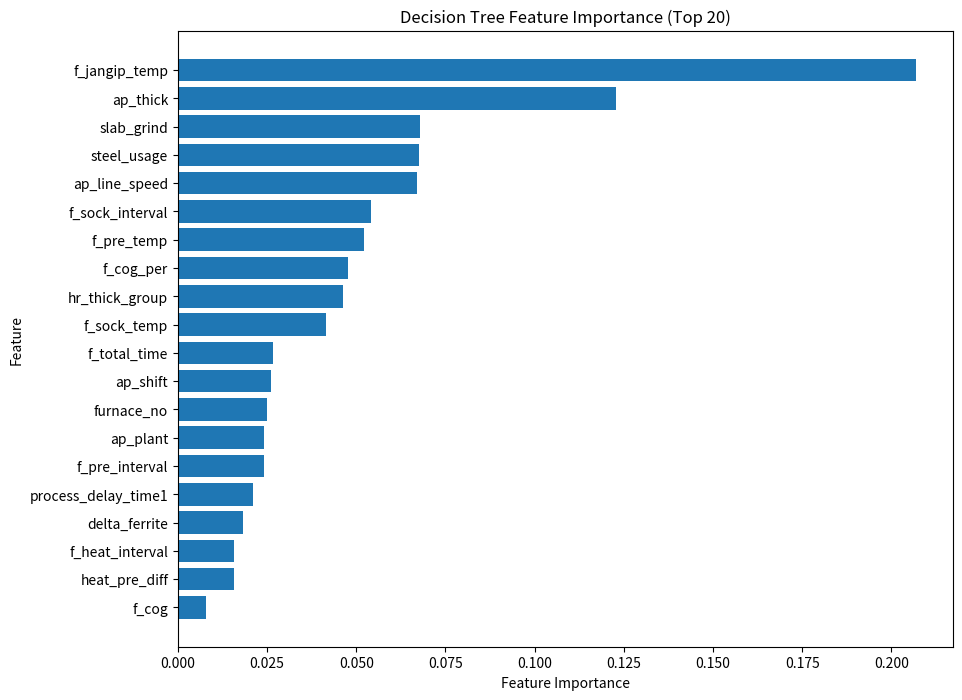

In [ ]:
import matplotlib.pyplot as plt

fi_top20 = fi.head(20).sort_values('importance')

plt.figure(figsize=(10, 8))
plt.barh(fi_top20['feature'], fi_top20['importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Decision Tree Feature Importance (Top 20)')
plt.show()

## RF

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, recall_score, f1_score, precision_score

rf_base = RandomForestClassifier(
    random_state=42,
    n_estimators=100,
    n_jobs=-1
)

rf_base.fit(x_train_smotenc, y_train_smotenc)
rf_pred = rf_base.predict(x_test_smnc)

print("=== RF Base ===")
print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred, digits=4))

print("Recall   :", recall_score(y_test, rf_pred, pos_label=1))
print("Precision:", precision_score(y_test, rf_pred, pos_label=1))
print("F1-score :", f1_score(y_test, rf_pred, pos_label=1))

=== RF Base ===
[[6839   62]
 [ 145   44]]
              precision    recall  f1-score   support

           0     0.9792    0.9910    0.9851      6901
           1     0.4151    0.2328    0.2983       189

    accuracy                         0.9708      7090
   macro avg     0.6972    0.6119    0.6417      7090
weighted avg     0.9642    0.9708    0.9668      7090

Recall   : 0.2328042328042328
Precision: 0.41509433962264153
F1-score : 0.2983050847457627


In [ ]:
#27분 이상 추정

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import recall_score, precision_score, f1_score, confusion_matrix, classification_report
import pandas as pd

search_results = []

# 공통 파라미터 후보
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# 1) f1 기준 그리드서치
grid_rf_f1 = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)
grid_rf_f1.fit(x_train_smotenc, y_train_smotenc)

model_f1 = grid_rf_f1.best_estimator_
pred_f1 = model_f1.predict(x_test_smnc)

search_results.append({
    '모델명': 'RF_grid_f1',
    'best_model': model_f1,
    'best_params': grid_rf_f1.best_params_,
    'cv_score': grid_rf_f1.best_score_,
    'test_recall': recall_score(y_test, pred_f1),
    'test_precision': precision_score(y_test, pred_f1),
    'test_f1': f1_score(y_test, pred_f1)
})

# 2) recall 기준 그리드서치
grid_rf_recall = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    scoring='recall',
    cv=3,
    n_jobs=-1,
    verbose=1
)
grid_rf_recall.fit(x_train_smotenc, y_train_smotenc)

model_recall = grid_rf_recall.best_estimator_
pred_recall = model_recall.predict(x_test_smnc)

search_results.append({
    '모델명': 'RF_grid_recall',
    'best_model': model_recall,
    'best_params': grid_rf_recall.best_params_,
    'cv_score': grid_rf_recall.best_score_,
    'test_recall': recall_score(y_test, pred_recall),
    'test_precision': precision_score(y_test, pred_recall),
    'test_f1': f1_score(y_test, pred_recall)
})

# 3) precision 기준 그리드서치
grid_rf_precision = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    scoring='precision',
    cv=3,
    n_jobs=-1,
    verbose=1
)
grid_rf_precision.fit(x_train_smotenc, y_train_smotenc)

model_precision = grid_rf_precision.best_estimator_
pred_precision = model_precision.predict(x_test_smnc)

search_results.append({
    '모델명': 'RF_grid_precision',
    'best_model': model_precision,
    'best_params': grid_rf_precision.best_params_,
    'cv_score': grid_rf_precision.best_score_,
    'test_recall': recall_score(y_test, pred_precision),
    'test_precision': precision_score(y_test, pred_precision),
    'test_f1': f1_score(y_test, pred_precision)
})

# 결과 표
result_df = pd.DataFrame(search_results)[['모델명', 'best_params', 'cv_score', 'test_recall', 'test_precision', 'test_f1']]
print(result_df)

# recall 가장 높은 모델 자동 선택
best_idx = result_df['test_recall'].idxmax()
final_model = search_results[best_idx]['best_model']
final_model_name = search_results[best_idx]['모델명']
final_model_params = search_results[best_idx]['best_params']

print("\n최종 선택 모델:", final_model_name)
print("최종 선택 파라미터:", final_model_params)

# 최종 모델 예측
final_pred = final_model.predict(x_test_smnc)

print("\n=== 최종 선택 모델 성능 ===")
print(confusion_matrix(y_test, final_pred))
print(classification_report(y_test, final_pred, digits=4))
print("Recall   :", recall_score(y_test, final_pred))
print("Precision:", precision_score(y_test, final_pred))
print("F1-score :", f1_score(y_test, final_pred))

Fitting 3 folds for each of 16 candidates, totalling 48 fits


Fitting 3 folds for each of 16 candidates, totalling 48 fits
Fitting 3 folds for each of 16 candidates, totalling 48 fits
                 모델명  \
0         RF_grid_f1   
1     RF_grid_recall   
2  RF_grid_precision   

                                                                             best_params  \
0  {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}   
1  {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}   
2  {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}   

   cv_score  test_recall  test_precision   test_f1  
0  0.984555     0.259259        0.371212  0.305296  
1  0.987082     0.248677        0.343066  0.288344  
2  0.982510     0.259259        0.371212  0.305296  

최종 선택 모델: RF_grid_f1
최종 선택 파라미터: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

=== 최종 선택 모델 성능 ===
[[6818   83]
 [ 140   49]]
              precision    recal

In [ ]:
feature_importance = pd.DataFrame({
    '변수': x_train_smotenc.columns,
    '중요도': final_model.feature_importances_
}).sort_values(by='중요도', ascending=False)

print(feature_importance.head(20))

                     변수       중요도
8         f_jangip_temp  0.096406
15             ap_thick  0.083769
14        ap_line_speed  0.061972
12           f_pre_temp  0.061057
9   process_delay_time1  0.057529
10      f_sock_interval  0.055804
11         f_total_time  0.048998
20            f_cog_per  0.047344
13        heat_pre_diff  0.044265
16          f_sock_temp  0.038188
2            slab_grind  0.038039
22                f_cog  0.036733
23        delta_ferrite  0.034598
1           steel_usage  0.031867
18      f_heat_interval  0.031466
21             ingre_cr  0.030887
5        hr_thick_group  0.030619
17       f_pre_interval  0.030355
0        f_jangip_gubun  0.027787
4              ap_shift  0.026537


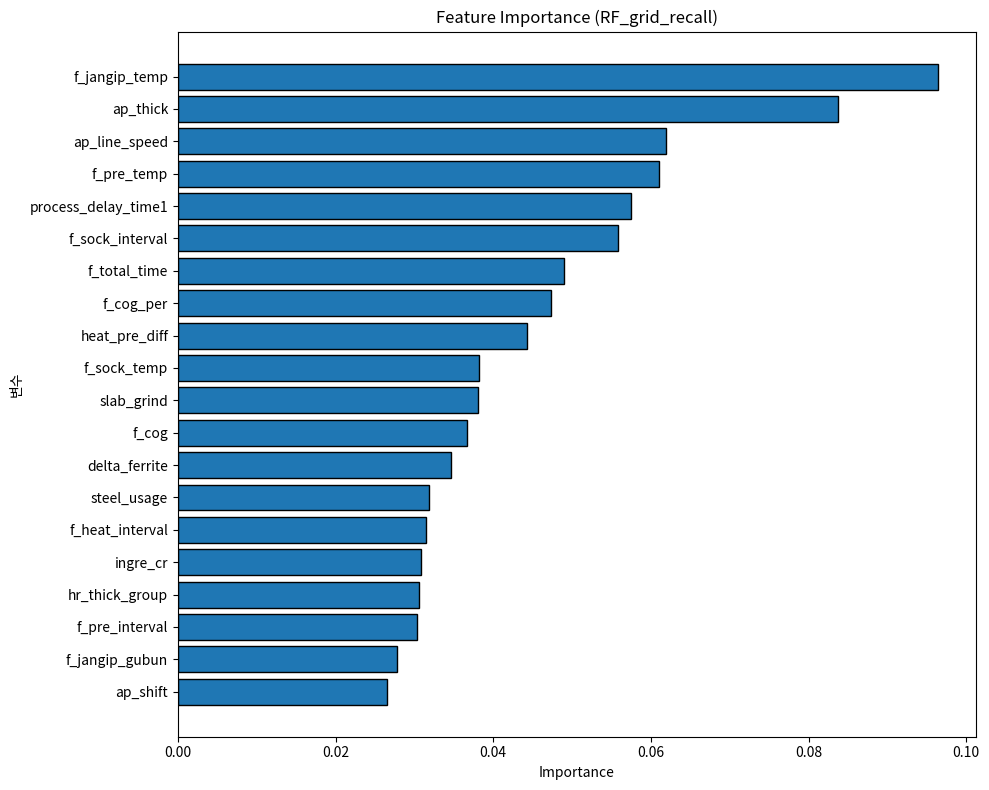

In [ ]:
import matplotlib.pyplot as plt

top_n = 20

top_features = feature_importance.head(top_n).sort_values(by='중요도', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(top_features['변수'], top_features['중요도'], edgecolor='black')
plt.title(f'Feature Importance ({final_model_name})')
plt.xlabel('Importance')
plt.ylabel('변수')
plt.tight_layout()
plt.show()

## GB

In [ ]:
#기본 모델

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, recall_score, precision_score, f1_score

gb_base = GradientBoostingClassifier(
    random_state=42
)

gb_base.fit(x_train_smotenc, y_train_smotenc)
gb_pred = gb_base.predict(x_test_smnc)

print("=== GB Base ===")
print(confusion_matrix(y_test, gb_pred))
print(classification_report(y_test, gb_pred, digits=4))

print("Recall   :", recall_score(y_test, gb_pred, pos_label=1))
print("Precision:", precision_score(y_test, gb_pred, pos_label=1))
print("F1-score :", f1_score(y_test, gb_pred, pos_label=1))

=== GB Base ===
[[6266  635]
 [ 111   78]]
              precision    recall  f1-score   support

           0     0.9826    0.9080    0.9438      6901
           1     0.1094    0.4127    0.1729       189

    accuracy                         0.8948      7090
   macro avg     0.5460    0.6603    0.5584      7090
weighted avg     0.9593    0.8948    0.9233      7090

Recall   : 0.4126984126984127
Precision: 0.1093969144460028
F1-score : 0.1729490022172949


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    confusion_matrix, classification_report,
    recall_score, precision_score, f1_score, accuracy_score
)
import pandas as pd

gb_search_results = []

param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

for scoring in ['recall']:
    grid_gb = GridSearchCV(
        estimator=GradientBoostingClassifier(random_state=42),
        param_grid=param_grid_gb,
        scoring=scoring,
        cv=3,
        n_jobs=-1,
        verbose=1
    )

    grid_gb.fit(x_train_smotenc, y_train_smotenc)

    gb_model = grid_gb.best_estimator_
    gb_pred = gb_model.predict(x_test_smnc)

    gb_search_results.append({
        '모델명': f'GB_grid_{scoring}',
        'best_model': gb_model,
        'best_params': grid_gb.best_params_,
        'cv_score': grid_gb.best_score_,
        'test_recall': recall_score(y_test, gb_pred),
        'test_precision': precision_score(y_test, gb_pred),
        'test_f1': f1_score(y_test, gb_pred)
    })

gb_result_df = pd.DataFrame(gb_search_results)[
    ['모델명', 'best_params', 'cv_score', 'test_recall', 'test_precision', 'test_f1']
]

print(gb_result_df)

gb_best_idx = gb_result_df['test_recall'].idxmax()
gb_final_model = gb_search_results[gb_best_idx]['best_model']
gb_final_model_name = gb_search_results[gb_best_idx]['모델명']
gb_final_model_params = gb_search_results[gb_best_idx]['best_params']

print("\n최종 선택 모델:", gb_final_model_name)
print("최종 선택 파라미터:", gb_final_model_params)

# threshold = 0.5
gb_final_pred = gb_final_model.predict(x_test_smnc)

print("\n=== GB 최종 성능 (threshold = 0.5) ===")
print(confusion_matrix(y_test, gb_final_pred))
print(classification_report(y_test, gb_final_pred, digits=4))
print("Accuracy :", accuracy_score(y_test, gb_final_pred))
print("Recall   :", recall_score(y_test, gb_final_pred))
print("Precision:", precision_score(y_test, gb_final_pred))
print("F1-score :", f1_score(y_test, gb_final_pred))

# threshold = 0.3
gb_proba = gb_final_model.predict_proba(x_test_smnc)[:, 1]
gb_pred_03 = (gb_proba >= 0.3).astype(int)

print("\n=== GB 최종 성능 (threshold = 0.3) ===")
print(confusion_matrix(y_test, gb_pred_03))
print(classification_report(y_test, gb_pred_03, digits=4))
print("Accuracy :", accuracy_score(y_test, gb_pred_03))
print("Recall   :", recall_score(y_test, gb_pred_03))
print("Precision:", precision_score(y_test, gb_pred_03))
print("F1-score :", f1_score(y_test, gb_pred_03))

Fitting 3 folds for each of 8 candidates, totalling 24 fits
              모델명  \
0  GB_grid_recall   

                                                   best_params  cv_score  \
0  {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}  0.978387   

   test_recall  test_precision   test_f1  
0     0.195767         0.41573  0.266187  

최종 선택 모델: GB_grid_recall
최종 선택 파라미터: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}

=== GB 최종 성능 (threshold = 0.5) ===
[[6849   52]
 [ 152   37]]
              precision    recall  f1-score   support

           0     0.9783    0.9925    0.9853      6901
           1     0.4157    0.1958    0.2662       189

    accuracy                         0.9712      7090
   macro avg     0.6970    0.5941    0.6258      7090
weighted avg     0.9633    0.9712    0.9662      7090

Accuracy : 0.9712270803949224
Recall   : 0.19576719576719576
Precision: 0.4157303370786517
F1-score : 0.26618705035971224

=== GB 최종 성능 (threshold = 0.3) ===
[[6700  201]

In [ ]:
from sklearn.metrics import (
    confusion_matrix, classification_report,
    recall_score, precision_score, f1_score, accuracy_score,
    roc_auc_score, average_precision_score
)

# threshold = 0.5
gb_final_pred = gb_final_model.predict(x_test_smnc)

print("\n=== GB 최종 성능 (threshold = 0.5) ===")
print(confusion_matrix(y_test, gb_final_pred))
print(classification_report(y_test, gb_final_pred, digits=4))
print("Accuracy :", accuracy_score(y_test, gb_final_pred))
print("Recall   :", recall_score(y_test, gb_final_pred))
print("Precision:", precision_score(y_test, gb_final_pred))
print("F1-score :", f1_score(y_test, gb_final_pred))

# 확률값
gb_proba = gb_final_model.predict_proba(x_test_smnc)[:, 1]

# threshold = 0.3
gb_pred_03 = (gb_proba >= 0.3).astype(int)

print("\n=== GB 최종 성능 (threshold = 0.3) ===")
print(confusion_matrix(y_test, gb_pred_03))
print(classification_report(y_test, gb_pred_03, digits=4))
print("Accuracy :", accuracy_score(y_test, gb_pred_03))
print("Recall   :", recall_score(y_test, gb_pred_03))
print("Precision:", precision_score(y_test, gb_pred_03))
print("F1-score :", f1_score(y_test, gb_pred_03))

# AUC
print("\n=== AUC ===")
print("ROC-AUC :", roc_auc_score(y_test, gb_proba))
print("PR-AUC  :", average_precision_score(y_test, gb_proba))


=== GB 최종 성능 (threshold = 0.5) ===
[[6849   52]
 [ 152   37]]
              precision    recall  f1-score   support

           0     0.9783    0.9925    0.9853      6901
           1     0.4157    0.1958    0.2662       189

    accuracy                         0.9712      7090
   macro avg     0.6970    0.5941    0.6258      7090
weighted avg     0.9633    0.9712    0.9662      7090

Accuracy : 0.9712270803949224
Recall   : 0.19576719576719576
Precision: 0.4157303370786517
F1-score : 0.26618705035971224

=== GB 최종 성능 (threshold = 0.3) ===
[[6700  201]
 [ 129   60]]
              precision    recall  f1-score   support

           0     0.9811    0.9709    0.9760      6901
           1     0.2299    0.3175    0.2667       189

    accuracy                         0.9535      7090
   macro avg     0.6055    0.6442    0.6213      7090
weighted avg     0.9611    0.9535    0.9571      7090

Accuracy : 0.9534555712270804
Recall   : 0.31746031746031744
Precision: 0.22988505747126436
F1-sco

=== GB 최종 선택 모델 변수중요도 TOP 20 ===
                     변수       중요도
15             ap_thick  0.143592
8         f_jangip_temp  0.140153
23        delta_ferrite  0.097123
10      f_sock_interval  0.087500
9   process_delay_time1  0.064731
2            slab_grind  0.059961
14        ap_line_speed  0.053120
12           f_pre_temp  0.047772
5        hr_thick_group  0.047410
1           steel_usage  0.036384
20            f_cog_per  0.034319
16          f_sock_temp  0.030117
21             ingre_cr  0.029647
11         f_total_time  0.028948
4              ap_shift  0.021634
7            furnace_no  0.019733
6              ap_plant  0.017818
22                f_cog  0.011616
13        heat_pre_diff  0.009421
18      f_heat_interval  0.005983


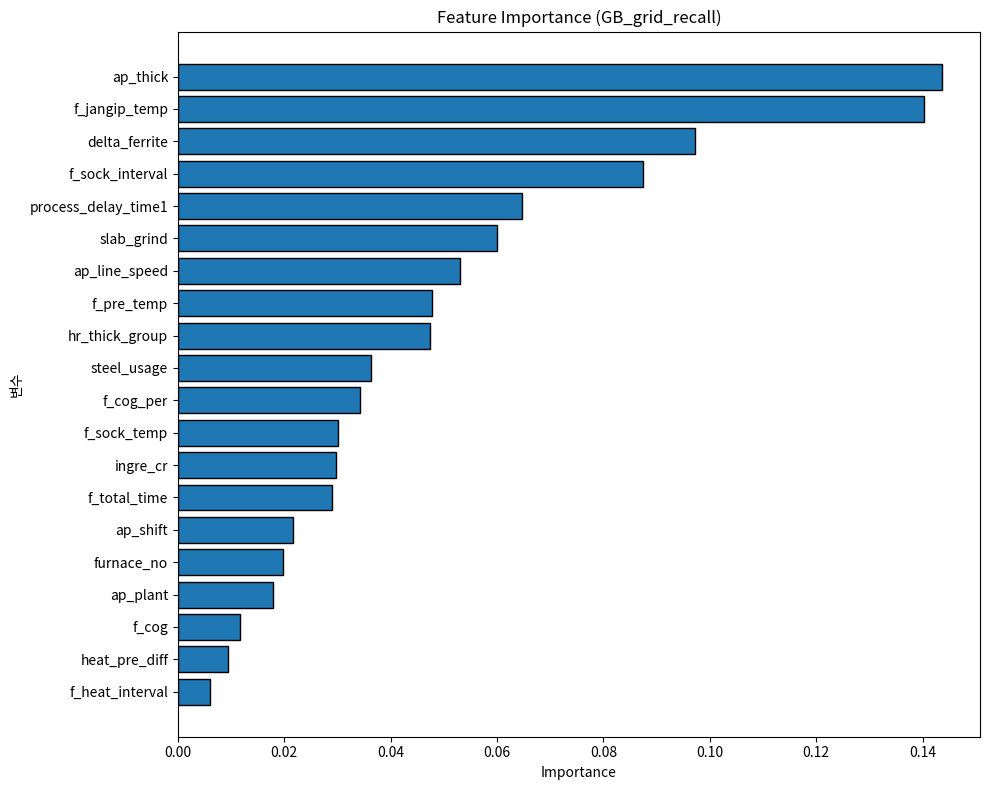

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

gb_feature_importance = pd.DataFrame({
    '변수': x_train_smotenc.columns,
    '중요도': gb_final_model.feature_importances_
}).sort_values(by='중요도', ascending=False)

print("=== GB 최종 선택 모델 변수중요도 TOP 20 ===")
print(gb_feature_importance.head(20))

top_n = 20
gb_top_features = gb_feature_importance.head(top_n).sort_values(by='중요도', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(gb_top_features['변수'], gb_top_features['중요도'], edgecolor='black')
plt.title(f'Feature Importance ({gb_final_model_name})')
plt.xlabel('Importance')
plt.ylabel('변수')
plt.tight_layout()
plt.show()

=== GB 최종 선택 모델 변수중요도 TOP 20 ===
                     변수       중요도
15             ap_thick  0.143592
8         f_jangip_temp  0.140153
23        delta_ferrite  0.097123
10      f_sock_interval  0.087500
9   process_delay_time1  0.064731
2            slab_grind  0.059961
14        ap_line_speed  0.053120
12           f_pre_temp  0.047772
5        hr_thick_group  0.047410
1           steel_usage  0.036384
20            f_cog_per  0.034319
16          f_sock_temp  0.030117
21             ingre_cr  0.029647
11         f_total_time  0.028948
4              ap_shift  0.021634
7            furnace_no  0.019733
6              ap_plant  0.017818
22                f_cog  0.011616
13        heat_pre_diff  0.009421
18      f_heat_interval  0.005983


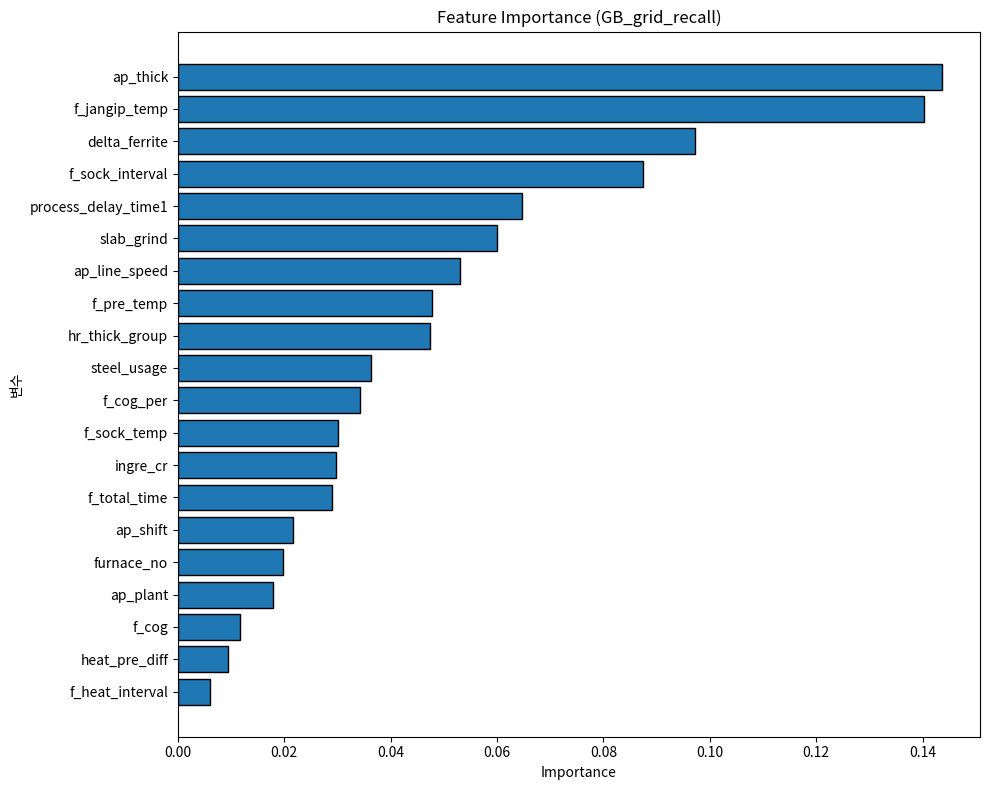

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

gb_feature_importance = pd.DataFrame({
    '변수': x_train_smotenc.columns,
    '중요도': gb_final_model.feature_importances_
}).sort_values(by='중요도', ascending=False)

print("=== GB 최종 선택 모델 변수중요도 TOP 20 ===")
print(gb_feature_importance.head(20))

top_n = 20
gb_top_features = gb_feature_importance.head(top_n).sort_values(by='중요도', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(gb_top_features['변수'], gb_top_features['중요도'], edgecolor='black')
plt.title(f'Feature Importance ({gb_final_model_name})')
plt.xlabel('Importance')
plt.ylabel('변수')
plt.tight_layout()
plt.show()

In [ ]:
#??이건 뭐지

gb_proba = gb_final_model.predict_proba(x_test_smnc)[:, 1]

for th in [0.3, 0.4, 0.5, 0.6]:
    gb_pred_th = (gb_proba >= th).astype(int)
    print(f"\n=== Threshold: {th} ===")
    print("Recall   :", recall_score(y_test, gb_pred_th))
    print("Precision:", precision_score(y_test, gb_pred_th))
    print("F1-score :", f1_score(y_test, gb_pred_th))


=== Threshold: 0.3 ===
Recall   : 0.31746031746031744
Precision: 0.22988505747126436
F1-score : 0.26666666666666666

=== Threshold: 0.4 ===
Recall   : 0.24867724867724866
Precision: 0.32413793103448274
F1-score : 0.281437125748503

=== Threshold: 0.5 ===
Recall   : 0.19576719576719576
Precision: 0.4157303370786517
F1-score : 0.26618705035971224

=== Threshold: 0.6 ===
Recall   : 0.14285714285714285
Precision: 0.5192307692307693
F1-score : 0.22406639004149378


## XGB

In [ ]:
# 기본 모델

from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, recall_score, precision_score, f1_score

xgb_base = XGBClassifier(
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    eval_metric='logloss'
)

xgb_base.fit(x_train_smotenc, y_train_smotenc)
xgb_pred = xgb_base.predict(x_test_smnc)

print("=== XGB Base ===")
print(confusion_matrix(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred, digits=4))

print("Recall   :", recall_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("F1-score :", f1_score(y_test, xgb_pred))

=== XGB Base ===
[[6762  139]
 [ 129   60]]
              precision    recall  f1-score   support

           0     0.9813    0.9799    0.9806      6901
           1     0.3015    0.3175    0.3093       189

    accuracy                         0.9622      7090
   macro avg     0.6414    0.6487    0.6449      7090
weighted avg     0.9632    0.9622    0.9627      7090

Recall   : 0.31746031746031744
Precision: 0.3015075376884422
F1-score : 0.30927835051546393


In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, recall_score, precision_score, f1_score
import pandas as pd

xgb_search_results = []

param_grid_xgb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'min_child_weight': [1, 3],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

for scoring in ['f1', 'recall', 'precision']:
    grid_xgb = GridSearchCV(
        estimator=XGBClassifier(
            random_state=42,
            eval_metric='logloss'
        ),
        param_grid=param_grid_xgb,
        scoring=scoring,
        cv=3,
        n_jobs=-1,
        verbose=1
    )

    grid_xgb.fit(x_train_smotenc, y_train_smotenc)

    model = grid_xgb.best_estimator_
    pred = model.predict(x_test_smnc)

    xgb_search_results.append({
        '모델명': f'XGB_grid_{scoring}',
        'best_model': model,
        'best_params': grid_xgb.best_params_,
        'cv_score': grid_xgb.best_score_,
        'test_recall': recall_score(y_test, pred),
        'test_precision': precision_score(y_test, pred),
        'test_f1': f1_score(y_test, pred)
    })

xgb_result_df = pd.DataFrame(xgb_search_results)[
    ['모델명', 'best_params', 'cv_score', 'test_recall', 'test_precision', 'test_f1']
]

print(xgb_result_df)

xgb_best_idx = xgb_result_df['test_recall'].idxmax()
xgb_final_model = xgb_search_results[xgb_best_idx]['best_model']
xgb_final_model_name = xgb_search_results[xgb_best_idx]['모델명']
xgb_final_model_params = xgb_search_results[xgb_best_idx]['best_params']

print("\n최종 선택 모델:", xgb_final_model_name)
print("최종 선택 파라미터:", xgb_final_model_params)

# 원래 pred
# xgb_final_pred = xgb_final_model.predict(x_test_smnc)
lgbm_final_probs = xgb_final_model.predict_proba(x_test_smnc)[:, 1]

# 2. 임계값을 0.3로 직접 지정하여 '최종 예측값'을 생성합니다
xgb_final_pred = (lgbm_final_probs > 0.3).astype(int)


print("\n=== XGB 최종 선택 모델 성능 ===")
print(confusion_matrix(y_test, xgb_final_pred))
print(classification_report(y_test, xgb_final_pred, digits=4))
print("Recall   :", recall_score(y_test, xgb_final_pred))
print("Precision:", precision_score(y_test, xgb_final_pred))
print("F1-score :", f1_score(y_test, xgb_final_pred))

Fitting 3 folds for each of 64 candidates, totalling 192 fits
Fitting 3 folds for each of 64 candidates, totalling 192 fits
Fitting 3 folds for each of 64 candidates, totalling 192 fits
                  모델명  \
0         XGB_grid_f1   
1     XGB_grid_recall   
2  XGB_grid_precision   

                                                                                                                     best_params  \
0  {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 200, 'subsample': 0.8}   
1  {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 200, 'subsample': 0.8}   
2  {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 200, 'subsample': 0.8}   

   cv_score  test_recall  test_precision   test_f1  
0  0.983672     0.248677        0.345588  0.289231  
1  0.980064     0.248677        0.345588  0.289231  
2  0.988107     0.222222 

=== XGB 최종 선택 모델 변수중요도 TOP 20 ===
                     변수       중요도
2            slab_grind  0.183066
8         f_jangip_temp  0.079031
5        hr_thick_group  0.074615
15             ap_thick  0.054969
9   process_delay_time1  0.054170
7            furnace_no  0.053440
1           steel_usage  0.046760
6              ap_plant  0.046097
23        delta_ferrite  0.045772
14        ap_line_speed  0.042937
10      f_sock_interval  0.042088
4              ap_shift  0.039210
12           f_pre_temp  0.032239
21             ingre_cr  0.029504
20            f_cog_per  0.027340
16          f_sock_temp  0.026085
11         f_total_time  0.023044
3              sm_plant  0.021660
0        f_jangip_gubun  0.016804
22                f_cog  0.015956


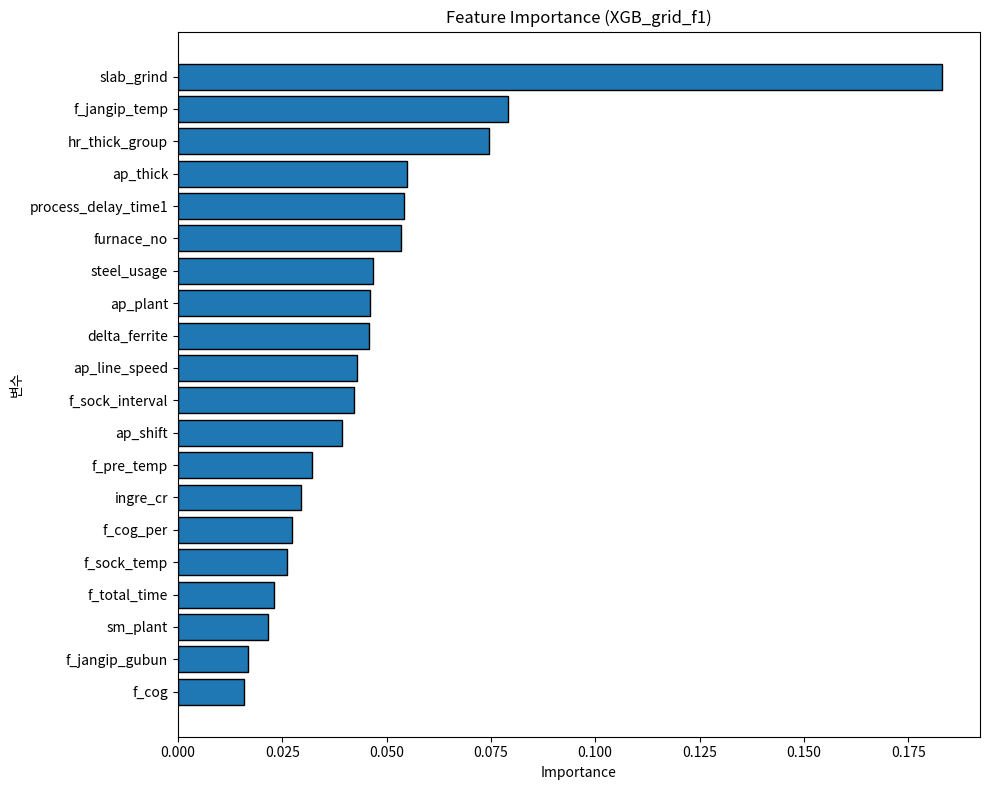

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

xgb_feature_importance = pd.DataFrame({
    '변수': x_train_smotenc.columns,
    '중요도': xgb_final_model.feature_importances_
}).sort_values(by='중요도', ascending=False)

print("=== XGB 최종 선택 모델 변수중요도 TOP 20 ===")
print(xgb_feature_importance.head(20))

top_n = 20
xgb_top_features = xgb_feature_importance.head(top_n).sort_values(by='중요도', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(xgb_top_features['변수'], xgb_top_features['중요도'], edgecolor='black')
plt.title(f'Feature Importance ({xgb_final_model_name})')
plt.xlabel('Importance')
plt.ylabel('변수')
plt.tight_layout()
plt.show()

In [ ]:
xgb_proba = xgb_final_model.predict_proba(x_test_smnc)[:, 1]

for th in [0.3, 0.4, 0.5, 0.6]:
    xgb_pred_th = (xgb_proba >= th).astype(int)
    print(f"\n=== Threshold: {th} ===")
    print("Recall   :", recall_score(y_test, xgb_pred_th))
    print("Precision:", precision_score(y_test, xgb_pred_th))
    print("F1-score :", f1_score(y_test, xgb_pred_th))


=== Threshold: 0.3 ===
Recall   : 0.41798941798941797
Precision: 0.21179624664879357
F1-score : 0.28113879003558717

=== Threshold: 0.4 ===
Recall   : 0.291005291005291
Precision: 0.25821596244131456
F1-score : 0.2736318407960199

=== Threshold: 0.5 ===
Recall   : 0.24867724867724866
Precision: 0.34558823529411764
F1-score : 0.28923076923076924

=== Threshold: 0.6 ===
Recall   : 0.19576719576719576
Precision: 0.4625
F1-score : 0.275092936802974


## Light GBM

In [ ]:
#기본모델

from lightgbm import LGBMClassifier
from sklearn.metrics import confusion_matrix, classification_report, recall_score, precision_score, f1_score

lgbm_base = LGBMClassifier(
    random_state=42,
    n_estimators=100
)

lgbm_base.fit(x_train_smotenc, y_train_smotenc)
lgbm_pred = lgbm_base.predict(x_test_smnc)

print("=== LGBM Base ===")
print(confusion_matrix(y_test, lgbm_pred))
print(classification_report(y_test, lgbm_pred, digits=4))

print("Recall   :", recall_score(y_test, lgbm_pred))
print("Precision:", precision_score(y_test, lgbm_pred))
print("F1-score :", f1_score(y_test, lgbm_pred))

=== LGBM Base ===
[[6863   38]
 [ 153   36]]
              precision    recall  f1-score   support

           0     0.9782    0.9945    0.9863      6901
           1     0.4865    0.1905    0.2738       189

    accuracy                         0.9731      7090
   macro avg     0.7323    0.5925    0.6300      7090
weighted avg     0.9651    0.9731    0.9673      7090

Recall   : 0.19047619047619047
Precision: 0.4864864864864865
F1-score : 0.2737642585551331


In [1643]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, recall_score, precision_score, f1_score
import pandas as pd

lgbm_search_results = []

param_grid_lgbm = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05],
    'max_depth': [-1],
    'num_leaves': [31, 63],
    'min_child_samples': [20],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

for scoring in ['recall']:
    grid_lgbm = GridSearchCV(
        estimator=LGBMClassifier(
            random_state=42,
            verbose=-1
        ),
        param_grid=param_grid_lgbm,
        scoring=scoring,
        cv=3,
        n_jobs=-1,
        verbose=1
    )

    grid_lgbm.fit(x_train_smotenc, y_train_smotenc)

    model = grid_lgbm.best_estimator_
    pred = model.predict(x_test_smnc)

    lgbm_search_results.append({
        '모델명': f'LGBM_grid_{scoring}',
        'best_model': model,
        'best_params': grid_lgbm.best_params_,
        'cv_score': grid_lgbm.best_score_,
        'test_recall': recall_score(y_test, pred),
        'test_precision': precision_score(y_test, pred),
        'test_f1': f1_score(y_test, pred)
    })

lgbm_result_df = pd.DataFrame(lgbm_search_results)[
    ['모델명', 'best_params', 'cv_score', 'test_recall', 'test_precision', 'test_f1']
]

print(lgbm_result_df)

lgbm_best_idx = lgbm_result_df['test_recall'].idxmax()
lgbm_final_model = lgbm_search_results[lgbm_best_idx]['best_model']
lgbm_final_model_name = lgbm_search_results[lgbm_best_idx]['모델명']
lgbm_final_model_params = lgbm_search_results[lgbm_best_idx]['best_params']

print("\n최종 선택 모델:", lgbm_final_model_name)
print("최종 선택 파라미터:", lgbm_final_model_params)

lgbm_final_pred = lgbm_final_model.predict(x_test_smnc)

print("\n=== LGBM 최종 선택 모델 성능 ===")
print(confusion_matrix(y_test, lgbm_final_pred))
print(classification_report(y_test, lgbm_final_pred, digits=4))
print("Recall   :", recall_score(y_test, lgbm_final_pred))
print("Precision:", precision_score(y_test, lgbm_final_pred))
print("F1-score :", f1_score(y_test, lgbm_final_pred))

Fitting 3 folds for each of 4 candidates, totalling 12 fits


                모델명  \
0  LGBM_grid_recall   

                                                                                                                                           best_params  \
0  {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 63, 'subsample': 0.8}   

   cv_score  test_recall  test_precision   test_f1  
0  0.979939     0.195767        0.445783  0.272059  

최종 선택 모델: LGBM_grid_recall
최종 선택 파라미터: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 63, 'subsample': 0.8}

=== LGBM 최종 선택 모델 성능 ===
[[6855   46]
 [ 152   37]]
              precision    recall  f1-score   support

           0     0.9783    0.9933    0.9858      6901
           1     0.4458    0.1958    0.2721       189

    accuracy                         0.9721      7090
   macro avg     0.7120    0.5946    0.6289      7090
weighted avg     0.9641  

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    confusion_matrix, classification_report,
    recall_score, precision_score, f1_score, accuracy_score
)
import numpy as np

param_grid_lgbm = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 63]
}

grid_lgbm = GridSearchCV(
    estimator=LGBMClassifier(random_state=42, verbose=-1),
    param_grid=param_grid_lgbm,
    scoring='recall',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_lgbm.fit(x_train_smotenc, y_train_smotenc)

lgbm_final_model = grid_lgbm.best_estimator_

# 기본 threshold = 0.5 예측
lgbm_final_pred = lgbm_final_model.predict(x_test_smnc)

print("최적 파라미터:", grid_lgbm.best_params_)
print("CV Recall:", grid_lgbm.best_score_)

print("\n=== LGBM 최종 성능 (threshold = 0.5) ===")
print(confusion_matrix(y_test, lgbm_final_pred))
print(classification_report(y_test, lgbm_final_pred, digits=4))
print("Accuracy :", accuracy_score(y_test, lgbm_final_pred))
print("Recall   :", recall_score(y_test, lgbm_final_pred))
print("Precision:", precision_score(y_test, lgbm_final_pred))
print("F1-score :", f1_score(y_test, lgbm_final_pred))


# -------------------------------
# threshold = 0.3 적용
# -------------------------------
lgbm_proba = lgbm_final_model.predict_proba(x_test_smnc)[:, 1]
lgbm_pred_03 = (lgbm_proba >= 0.3).astype(int)

print("\n=== LGBM 최종 성능 (threshold = 0.3) ===")
print(confusion_matrix(y_test, lgbm_pred_03))
print(classification_report(y_test, lgbm_pred_03, digits=4))
print("Accuracy :", accuracy_score(y_test, lgbm_pred_03))
print("Recall   :", recall_score(y_test, lgbm_pred_03))
print("Precision:", precision_score(y_test, lgbm_pred_03))
print("F1-score :", f1_score(y_test, lgbm_pred_03))

Fitting 3 folds for each of 8 candidates, totalling 24 fits
최적 파라미터: {'learning_rate': 0.1, 'n_estimators': 100, 'num_leaves': 63}
CV Recall: 0.9790696345748165

=== LGBM 최종 성능 (threshold = 0.5) ===
[[6861   40]
 [ 144   45]]
              precision    recall  f1-score   support

           0     0.9794    0.9942    0.9868      6901
           1     0.5294    0.2381    0.3285       189

    accuracy                         0.9740      7090
   macro avg     0.7544    0.6161    0.6576      7090
weighted avg     0.9674    0.9740    0.9692      7090

Accuracy : 0.9740479548660085
Recall   : 0.23809523809523808
Precision: 0.5294117647058824
F1-score : 0.3284671532846715

=== LGBM 최종 성능 (threshold = 0.3) ===
[[6820   81]
 [ 130   59]]
              precision    recall  f1-score   support

           0     0.9813    0.9883    0.9848      6901
           1     0.4214    0.3122    0.3587       189

    accuracy                         0.9702      7090
   macro avg     0.7014    0.6502    0.6717

=== LGBM 최종 선택 모델 변수중요도 TOP 20 ===
                     변수  중요도
26      f_sock_interval  342
34             ap_thick  320
6               ingre_s  310
37         f_heat_total  284
35             ap_width  261
3         delta_ferrite  240
14        f_jangip_temp  237
36        ap_line_speed  218
5              ingre_ni  187
4              ingre_cr  182
8          tundish_temp  178
9            mlac_ratio  176
21           f_pre_temp  172
40  process_delay_time1  167
38         f_total_time  163
29             rm_pitch  155
16                f_cog  155
30           slab_width  154
39      f_heat_constant  151
19            f_cog_per  148


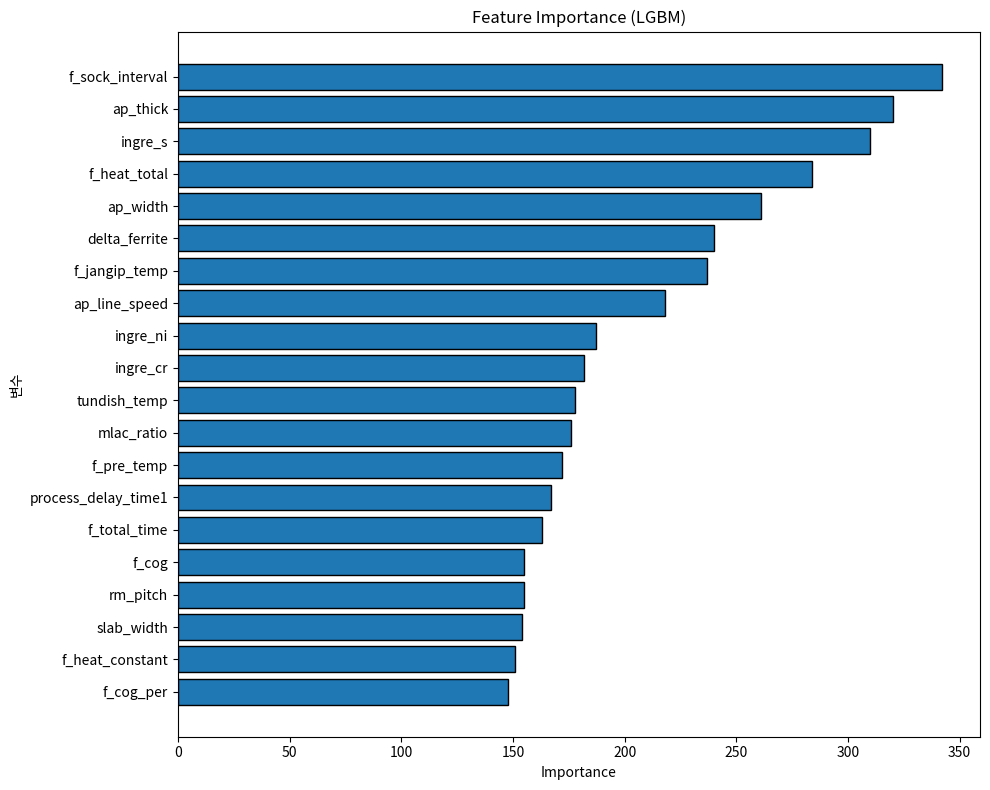

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

lgbm_feature_importance = pd.DataFrame({
    '변수': x_train_smotenc.columns,
    '중요도': lgbm_final_model.feature_importances_
}).sort_values(by='중요도', ascending=False)

print("=== LGBM 최종 선택 모델 변수중요도 TOP 20 ===")
print(lgbm_feature_importance.head(20))

top_n = 20
lgbm_top_features = lgbm_feature_importance.head(top_n).sort_values(by='중요도', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(lgbm_top_features['변수'], lgbm_top_features['중요도'], edgecolor='black')
plt.title('Feature Importance (LGBM)')
plt.xlabel('Importance')
plt.ylabel('변수')
plt.tight_layout()
plt.show()